# Open Ecosystem AI Projects Diffusion Across Global Cities: Roles, Speed, and Network

## Preparation

- [Github link](https://github.com/XINRUIQI/CASA0006-DSSS-Assessment)

- Number of words: ***

- Runtime: ~5 min (*Memory 16 GB, CPU Apple M-series or Intel i7*)

- Coding environment: Python 3.9.6 with Jupyter Notebook

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **xgboost** 2.1.4 — gradient boosting for event-level adoption-speed modelling.
    - **shap** 0.49.1 — SHAP (SHapley Additive exPlanations) for tree-model interpretability.
    - **torch** 2.8.0 & **torch_geometric** 2.6.1 — PyTorch and PyTorch Geometric for GraphSAGE city-network prediction.
    - **geopandas** 1.0.1 — geospatial vector data for map-based figures.

- Models used

    - K-Means 
    - OLS linear regression
    - XGBoost
    - GraphSAGE


## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

Open-source artificial intelligence increasingly shapes global innovation, yet its production and adoption remain geographically uneven rather than uniformly distributed across an ostensibly borderless internet (Feldman & Audretsch, 1999). Empirical work on GitHub confirms that open-source contributions concentrate in a handful of superstar technology metros, suggesting persistent agglomeration advantages even in digital collaboration (Wachs et al., 2022). Innovation-geography theory explains why frontier activities still cling to dense, well-connected places: knowledge spillovers, related variety, and institutional thickness continue to channel creative work into specific locations (Balland et al., 2020; Boschma, 2005). Classical diffusion study further stresses that adoption spreads through network bridging among heterogeneous adopter populations, not through uniform exposure alone (Rogers, 2003), while advances in learning on graph-structured data have demonstrated that explicit relational links among entities can meaningfully improve node-level prediction tasks (Hamilton et al., 2017).

Despite these foundations, most empirical designs isolate individual platforms, narrow model families, or national-level totals. Few studies simultaneously examine multimodal prominence indicators at metropolitan resolution alongside adoption timelines and inter-city collaboration networks derived from shared repository participation. In particular, the interplay between city-level socioeconomic characteristics, structural network position, and technology-type heterogeneity in shaping open-AI project diffusion across the global urban system remains largely under-explored.

This study addresses that gap by analysing **23,481** curated prominent open-AI projects spanning **148** cities across **50** countries from **2022** through **2025**. Drawing on GitHub and Hugging Face metadata, external city covariates covering population, GDP, education, internet penetration, R&D expenditure, and research capacity, and a collaboration network constructed from shared contributor links, the analysis investigates what distinct roles cities play in the open-AI ecosystem, which city characteristics are associated with adoption speed, whether and how adoption speed and its determinants vary across technology types, and whether inter-city network structure can help predict future adoption counts.

## Research questions

[[ go back to the top ]](#Table-of-contents)

### Main research question

How do global cities participate in the creation and adoption of prominent open-AI projects, and what factors shape the diffusion of these projects across the global urban system?

### Sub-questions

- What distinct roles do global cities play in the ecosystem of open-AI projects, such as originators, collaboration hubs, and bridge cities?

- Which city characteristics are associated with innovation-oriented roles?

- Which city characteristics are associated with faster adoption of open-AI projects, and do these effects vary across technology types (e.g., LLM, vision, speech)?

- Can inter-city collaboration networks be used to predict future adoption outcomes across cities?

## Data

[[ go back to the top ]](#Table-of-contents)

### 3.1 Data Sources
| Dataset | Source | Content | Coverage |
|---|---|---|---|
| GitHub Repository & Activity Signals | [GitHub REST API](https://docs.github.com/en/rest) (Search API, Users API) | Repository metadata (stars, forks, topics, description, created_at), contributor lists, and commit/PR participation events for project discovery and adoption chronology. | 2022–2025, Global |
| Hugging Face Model Signals | [Hugging Face Hub API](https://huggingface.co/docs/huggingface_hub) (`huggingface_hub`) | Models, datasets, and spaces metadata (downloads, likes, pipeline_tag, tags, author) for AI-project discovery and relevance classification. | 2022–2025, Global |
| City Population | [UN World Urbanization Prospects](https://population.un.org/wup/) / National Statistics | Metro-area population (millions) for per-capita normalisation of adoption and collaboration metrics. | ~2023, 148 cities |
| GDP per Capita | [World Bank World Development Indicators](https://databank.worldbank.org/source/world-development-indicators) (WDI) | Country-level GDP per capita (current USD), proxying economic development. | ~2023, Country-level |
| Education & Research Capacity | [World Bank](https://databank.worldbank.org/source/world-development-indicators) (tertiary enrolment) / [QS World University Rankings 2024](https://www.topuniversities.com/world-university-rankings) | Country-level tertiary gross enrolment ratio (%) and city-level count of QS top-500 universities as a research capacity proxy. | ~2023, Country & City |
| Digital Infrastructure & R&D Investment | [ITU](https://datahub.itu.int/) / [World Bank](https://databank.worldbank.org/source/world-development-indicators) (internet users) / [UNESCO](https://uis.unesco.org/) (R&D expenditure) | Country-level internet users as share of population (%) and R&D expenditure as share of GDP (%). | ~2023, Country-level |

The datasets for the open-AI projects studied in this work were collected and assembled using the GitHub [REST API](https://docs.github.com/en/rest) (Search API, Users API) and the Hugging Face [Hub API](https://huggingface.co/docs/huggingface_hub) (`huggingface_hub`). The full acquisition and preprocessing pipeline is documented in a separate notebook, `Data_Preparation_Pipeline.ipynb`.


### 3.2 Selected Variables

Using the open-AI dataset constructed above, combined with other city-level characteristics, five aggregated and organised data tables are obtained as follows:

**Prominent projects list**

| Variable | Type | Definition |
|---|---|---|
| project_id | Categorical | Unified project identifier (e.g. gh_*, hf_*). |
| platform | Categorical | GitHub or HuggingFace. |
| full_id | Categorical | Native platform string (full repo name or HF model id). |
| project_name | Categorical | Short display name. |
| hf_type | Categorical | Hugging Face resource type (empty for GitHub). |
| tags | Categorical | Tag string (often semicolon-separated). |
| metric_stars | Integer | Star count (GitHub; often missing for HF). |
| metric_forks | Integer | Fork count (GitHub; often missing for HF). |
| metric_downloads | Integer | Download count (HF; often missing for GitHub). |
| metric_likes | Integer | Like count (HF; often missing for GitHub). |
| created_at | Categorical | Repository/model creation time (ISO 8601 string). |
| open_ai_related | Binary | Flag: project passes open-AI relevance screen. |
| ai_evidence | Categorical | Keywords or labels supporting AI relevance. |
| ai_confidence | Ordinal | Confidence tier of relevance rule (e.g. high, medium, low). |
| prominent_flag | Binary | Retained rows have prominent_flag = 1 only. |

**City–project adoption events**

| Variable | Type | Definition |
|---|---|---|
| city | Categorical | City name. |
| project_id | Categorical | Project key (GitHub owner/repo or Hugging Face hf_* id). |
| global_origin_month | Integer | Global project origin month as YYYYMM. |
| city_first_adoption_month | Integer | First month the city links to the project (YYYYMM). |
| lag | Integer | Months from global_origin_month to city_first_adoption_month (non-negative). |
| is_originator | Binary | 1 if the city originated the project; 0 otherwise. |

**City-level attributes**

| Variable | Type | Definition |
|---|---|---|
| city | Categorical | Standardised city name; joins to city_list.matched_city. |
| country | Categorical | Country name. |
| lat | Continuous | Latitude of city centroid (degrees). |
| lon | Continuous | Longitude of city centroid (degrees). |
| entity_count | Integer | Count of GitHub/HF entities linked to the city in the study frame (activity denominator from city_list). |
| origination_count | Integer | Number of adoption events where the city is project originator (is_originator = 1). |
| origination_rate | Continuous | origination_count divided by entity_count. |
| adoption_count | Integer | Distinct project_id with at least one adoption event. |
| adoption_rate | Continuous | adoption_count divided by entity_count. |
| avg_lag | Continuous | Mean adoption lag in months across all city–project events. |
| median_lag | Continuous | Median adoption lag in months. |
| collaboration_count | Integer | Sum of edge_weight on all incident collaboration edges (undirected). |
| weighted_degree | Continuous | Weighted degree on the collaboration graph (equivalent to collaboration_count here). |
| betweenness | Continuous | Weighted betweenness centrality. |
| eigenvector_centrality | Continuous | Weighted eigenvector centrality (zero-filled if estimation fails). |
| population_million | Continuous | Metro population in millions (external lookup). |
| gdp_per_capita | Continuous | Country GDP per capita in current USD (~2023). |
| education_tertiary_pct | Continuous | Country tertiary gross enrolment ratio (%). |
| internet_users_pct | Continuous | Country internet users as share of population (%). |
| rd_expenditure_pct | Continuous | Country R&D expenditure as % of GDP. |
| research_capacity | Integer | Count proxy for local research capacity (e.g. QS top-500 universities in city). |
| timezone_utc | Continuous | Approximate UTC offset in hours (0.5 h grid from longitude). |
| region | Categorical | Macro-region (e.g. East Asia, Europe, North America). |
| origination_rate_pop | Continuous | Origination events per million population. |
| adoption_rate_pop | Continuous | Adopted distinct projects per million population. |
| collaboration_rate_pop | Continuous | Collaboration weight sum per million population. |
| lag_std | Continuous | Std. dev. of adoption lag across all events for the city . |
| avg_lag_nonorig | Continuous | Mean lag restricted to non-originator events (is_originator = 0). |
| cross_region_ratio_calc | Continuous | Share of the city's collaboration edge weight that crosses macro-regions . |
| pop_top25_share | Continuous | Mean share of adopted projects falling in the global top-25% popularity tier . |
| orig_top25_share | Continuous | Bayesian-smoothed share of originated projects in the top-25% popularity tier . |
| lag_quality_corr | Continuous | Within-city correlation between adoption lag and project popularity percentile . |
| avg_fork_star_ratio | Continuous | Mean fork/star ratio over GitHub projects the city engages with . |
| iei_std | Continuous | City-level dispersion of inter-event intervals (IEI) derived from adoption chronology (same IEI construction as downstream notebooks when exported into this table). |
| iei_quality_corr | Continuous | City-level correlation summarising IEI vs project popularity / quality among events (exported with IEI block). |
| avg_iei | Continuous | City-level mean IEI in months (non-originator diffusion pacing; exported with IEI block). |
| cluster | Ordinal | K-means cluster id when clustering outputs are merged back into city_attributes.csv. |
| role | Categorical | Interpretable role label paired with cluster when merged back into the CSV. |

**City-pair collaboration edges, aggregated**

| Variable | Type | Definition |
|---|---|---|
| source_city | Categorical | Lexicographically smaller endpoint of the undirected pair. |
| target_city | Categorical | Other endpoint of the undirected pair. |
| edge_weight | Integer | Count of shared project units linking the pair (GitHub co-repo; HF one unit per derivation edge). |
| shared_projects | Integer | In this build, incremented with edge_weight (numerically identical). |

**City-pair collaboration edges, monthly snapshots**

| Variable | Type | Definition |
|---|---|---|
| source_city | Categorical | Same semantics as aggregated edge table. |
| target_city | Categorical | Same semantics as aggregated edge table. |
| month | Integer | Attribution month YYYYMM. |
| edge_weight | Integer | Indicator coded as **1** when at least one collaboration is attributed in that month for the pair (current export uses 0/1). |

### 3.3 Data Overview

| Name | Records | Notes |
|---|---|---|
| City list | 148 cities | 50 countries, 9 regions. |
| Project list | 23,481 projects | Prominent GitHub and HuggingFace projects. |
| Adoption event list | 39,158 events | City–project adoption and origin rows. |
| City attributes | 148 rows × 38 columns | One row per city, including GDP, education, internet coverage, etc. |
| City collaboration edges | 9,636 edges | Aggregated undirected city pairs. |


In [1]:
# Environment setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy import stats
from scipy.stats import spearmanr
import geopandas as gpd

import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, r2_score,
                             mean_squared_error, mean_absolute_error,
                             accuracy_score, f1_score)
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold

import statsmodels.api as sm
import statsmodels.formula.api as smf

from xgboost import XGBRegressor
import shap

import os
import torch
torch.set_num_threads(1)
os.environ["OMP_NUM_THREADS"] = "1"
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv


warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 6), 'figure.dpi': 100})

GITHUB_RAW     = 'https://raw.githubusercontent.com/XINRUIQI/CASA0006-DSSS-Assessment/main/'
DATA_RAW       = GITHUB_RAW + 'data/raw/'
DATA_PROCESSED = GITHUB_RAW + 'data/processed/'
DATA_OUTPUT    = GITHUB_RAW + 'data/output/'

DATA = DATA_OUTPUT
PROC = DATA_PROCESSED

def add_iei_columns(df,
                    adopt_col='city_first_adoption_month',
                    origin_col='global_origin_month',
                    group_key='project_id',
                    sort_tiebreak='city',
                    origin_idx_col=None):
    """Add 'interval' (IEI, months) to event-level df; gap since previous adoption per project."""
    df = df.copy()
    df['_adopt_idx'] = df[adopt_col].apply(_ym_to_months)
    if origin_idx_col is not None:
        origin_ref = df[origin_idx_col]
    else:
        df['_origin_idx'] = df[origin_col].apply(_ym_to_months)
        origin_ref = df['_origin_idx']
    df = df.sort_values([group_key, '_adopt_idx', sort_tiebreak]).reset_index(drop=True)
    df['_prev_adopt'] = df.groupby(group_key)['_adopt_idx'].shift(1)
    df['interval'] = df['_adopt_idx'] - df['_prev_adopt'].fillna(origin_ref)
    drop_cols = [c for c in ['_adopt_idx', '_origin_idx', '_prev_adopt'] if c in df.columns]
    df = df.drop(columns=drop_cols)
    return df

CITY_IV_RAW_11 = [
    'log_degree', 'log_population', 'log_gdp', 'log_entity',
    'education_tertiary_pct', 'internet_users_pct',
    'rd_expenditure_pct', 'research_capacity', 'betweenness',
    'entity_count', 'population_million',
    'cross_region_ratio_calc',
]
CITY_IV_MAIN_11 = [
    'log_degree', 'log_population', 'gdp_raw', 'log_entity',
    'education_tertiary_pct', 'internet_reflect',
    'rd_expenditure_pct', 'research_log', 'betweenness_log',
    'log_entity_per_cap', 'log_cross_region',
]
EXTRA_CITY = ['eigenvector_centrality', 'origination_rate']
PROJ_AGG_COLS  = ['log_proj_pop', 'proj_origin_idx']
PROJ_ATTR_COLS = ['log_stars', 'log_forks', 'popularity_pctile', 'fork_star_ratio']


def build_city_covariates(city_attr):
    """Filter active cities and add log-transformed covariates."""
    df = city_attr[city_attr['adoption_count'] > 0].copy()
    df['log_degree']       = np.log1p(df['weighted_degree'])
    df['log_population']   = np.log1p(df['population_million'])
    df['log_gdp']          = np.log(df['gdp_per_capita'])
    df['log_entity']       = np.log1p(df['entity_count'])
    df['originator_share'] = df['origination_count'] / df['adoption_count']
    df['log_adoption']     = np.log1p(df['adoption_count'])
    return df

def _ym_to_months(ym):
    """Convert YYYYMM int to 0-based month index (origin 2022-01)."""
    y, m = divmod(int(ym), 100)
    return (y - 2022) * 12 + (m - 1)

In [2]:
# Dataset loading
city_attr   = pd.read_csv(DATA_OUTPUT + 'city_attributes.csv')
adoption    = pd.read_csv(DATA_OUTPUT + 'city_project_adoption_events.csv')
edges_agg   = pd.read_csv(DATA_OUTPUT + 'city_collaboration_edges.csv')
edges_month = pd.read_csv(DATA_OUTPUT + 'city_collaboration_edges_monthly.csv')
prom        = pd.read_csv(DATA_PROCESSED + 'prominent_projects_master.csv', dtype=str)
world       = gpd.read_file(GITHUB_RAW + 'data/raw/naturalearth/ne_110m_countries.geojson')

prom_projects  = prom
adopt_events   = adoption
collab_edges   = edges_agg
city_attr_dedup = city_attr.drop_duplicates(subset='city', keep='first')

print(f"city_attr: {city_attr.shape},  adoption: {adoption.shape},  "
      f"edges: {edges_agg.shape},  prom: {prom.shape},  world: {world.shape}")

_adp_eda = add_iei_columns(
    adoption[['city', 'project_id', 'city_first_adoption_month',
              'global_origin_month', 'lag']])
_iei_eda = (
    _adp_eda[(_adp_eda['lag'] > 0) & (_adp_eda['interval'] >= 0)]
    .groupby('city')['interval'].mean()
    .rename('avg_iei'))
city_attr = city_attr.drop(columns=['avg_iei'], errors='ignore')
city_attr = city_attr.merge(_iei_eda.reset_index(), on='city', how='left')
city_attr_dedup = city_attr.drop_duplicates(subset='city', keep='first')
print(f"avg_iei merged: n_valid={_iei_eda.notna().sum()} cities, "
      f"mean={_iei_eda.mean():.1f}, median={_iei_eda.median():.1f} months")

city_attr: (148, 38),  adoption: (39158, 6),  edges: (9636, 4),  prom: (23481, 15),  world: (177, 169)
avg_iei merged: n_valid=148 cities, mean=3.0, median=2.8 months


## Methodology

[[ go back to the top ]](#Table-of-contents)

Five stages: EDA on distributions, space, and networks; K-means city roles; OLS innovation correlates; XGBoost, SHAP, and interaction OLS for adoption and technology effects; GraphSAGE predicts adoption from collaboration ties.
![image.png](methodology.png)

### 4.1  Exploratory Data Analysis (EDA)

#### 4.1.1 Variable Distribution and Patterns


,count,mean,std,min,25%,50%,75%,max,skewness,IQR,CV
entity_count,148.0,188.804,338.967,3.000,39.750,71.000,183.000,2239.000,4.041,143.250,1.795
origination_count,148.0,57.466,184.833,0.000,2.000,8.000,23.000,1802.000,6.633,21.000,3.216
adoption_count,148.0,264.581,468.588,3.000,53.750,113.500,257.250,3757.000,4.290,203.500,1.771
avg_iei,148.0,2.969,0.998,1.000,2.379,2.846,3.377,7.125,1.393,0.998,0.336
collaboration_count,148.0,2289.135,2527.837,64.000,699.750,1274.500,2828.250,13337.000,2.150,2128.500,1.104
weighted_degree,148.0,2289.135,2527.837,64.000,699.750,1274.500,2828.250,13337.000,2.150,2128.500,1.104
betweenness,148.0,0.007,0.014,0.000,0.000,0.002,0.006,0.124,4.770,0.006,2.080
eigenvector_centrality,148.0,0.055,0.062,0.001,0.016,0.030,0.068,0.319,2.159,0.051,1.127
population_million,148.0,6.317,6.604,0.060,1.375,4.050,9.600,37.400,1.551,8.225,1.045
gdp_per_capita,148.0,42019.966,27440.212,1560.000,12720.000,46125.000,64057.500,103685.000,0.065,51337.500,0.653


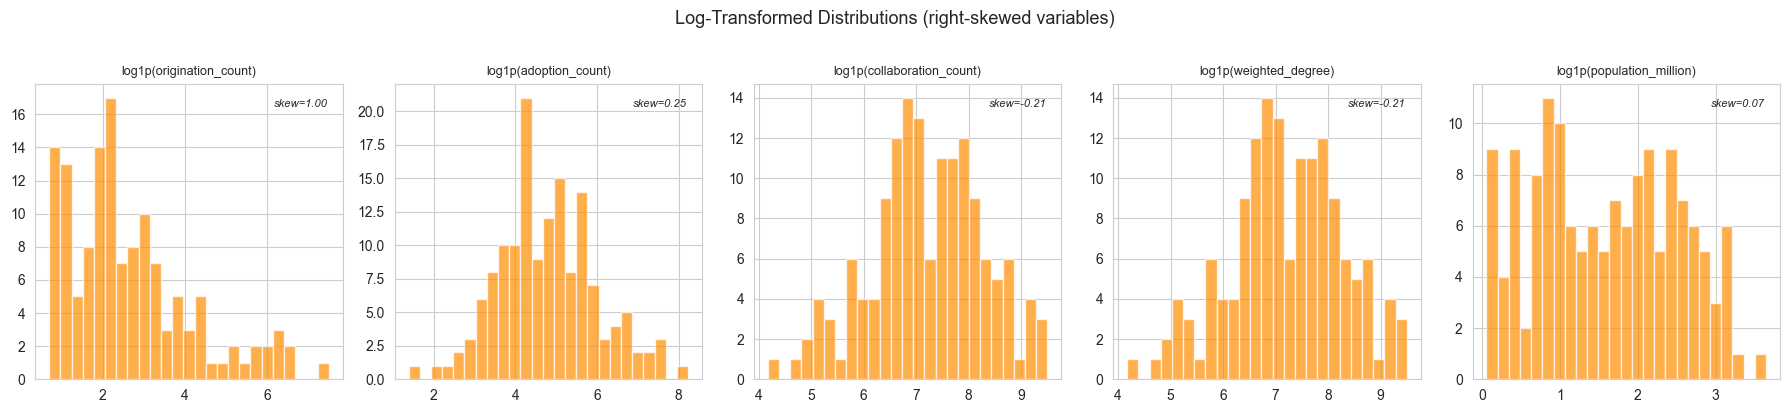

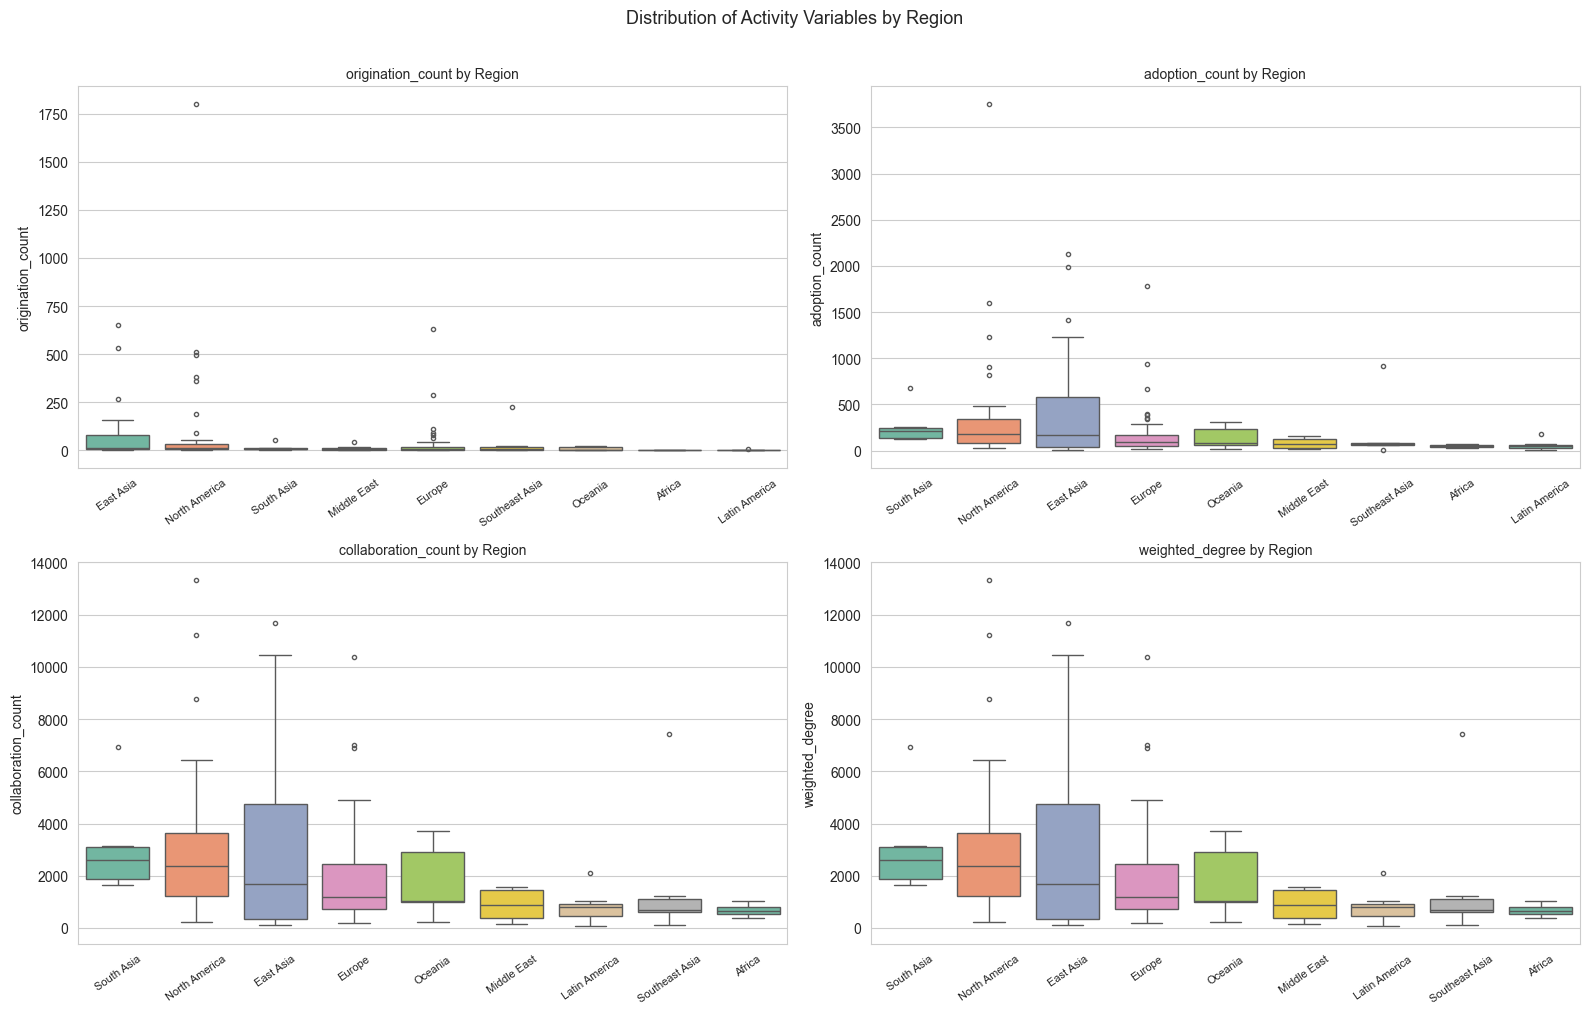

In [3]:
# Descriptive statistics
desc_cols = ['entity_count', 'origination_count', 'adoption_count',
             'avg_iei', 'collaboration_count', 'weighted_degree',
             'betweenness', 'eigenvector_centrality',
             'population_million', 'gdp_per_capita',
             'education_tertiary_pct', 'internet_users_pct', 'rd_expenditure_pct',
             'research_capacity']

summary = city_attr[desc_cols].describe().T
summary['skewness'] = city_attr[desc_cols].skew()
summary['IQR'] = summary['75%'] - summary['25%']
summary['CV'] = summary['std'] / summary['mean']
display(summary.round(3))

# Log-transformed distributions for right-skewed variables
log_vars = ['origination_count', 'adoption_count', 'collaboration_count',
            'weighted_degree', 'population_million']

fig, axes = plt.subplots(1, len(log_vars), figsize=(18, 4))

for ax, col in zip(axes, log_vars):
    data = city_attr[col].dropna()
    data_pos = data[data > 0]
    log_data = np.log1p(data_pos)
    ax.hist(log_data, bins=25, edgecolor='white', alpha=0.7, color='darkorange')
    ax.set_title(f'log1p({col})', fontsize=9)
    skew = log_data.skew()
    ax.text(0.95, 0.92, f'skew={skew:.2f}', transform=ax.transAxes,
            ha='right', fontsize=8, style='italic')

fig.suptitle('Log-Transformed Distributions (right-skewed variables)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Box plots: key activity variables by region
box_vars = ['origination_count', 'adoption_count', 'collaboration_count', 'weighted_degree']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, col in zip(axes.flatten(), box_vars):
    order = city_attr.groupby('region')[col].median().sort_values(ascending=False).index
    sns.boxplot(data=city_attr, x='region', y=col, order=order, ax=ax,
                palette='Set2', fliersize=3)
    ax.set_title(f'{col} by Region', fontsize=10)
    ax.tick_params(axis='x', rotation=35, labelsize=8)
    ax.set_xlabel('')

plt.suptitle('Distribution of Activity Variables by Region', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Based on the feature distribution table, many variables are clearly right-skewed, so a log transformation was applied to these variables. The figure above, Log-Transformed Distributions, shows some of the variables after transformation.

#### 4.1.2 Spatiotemporal Patterns


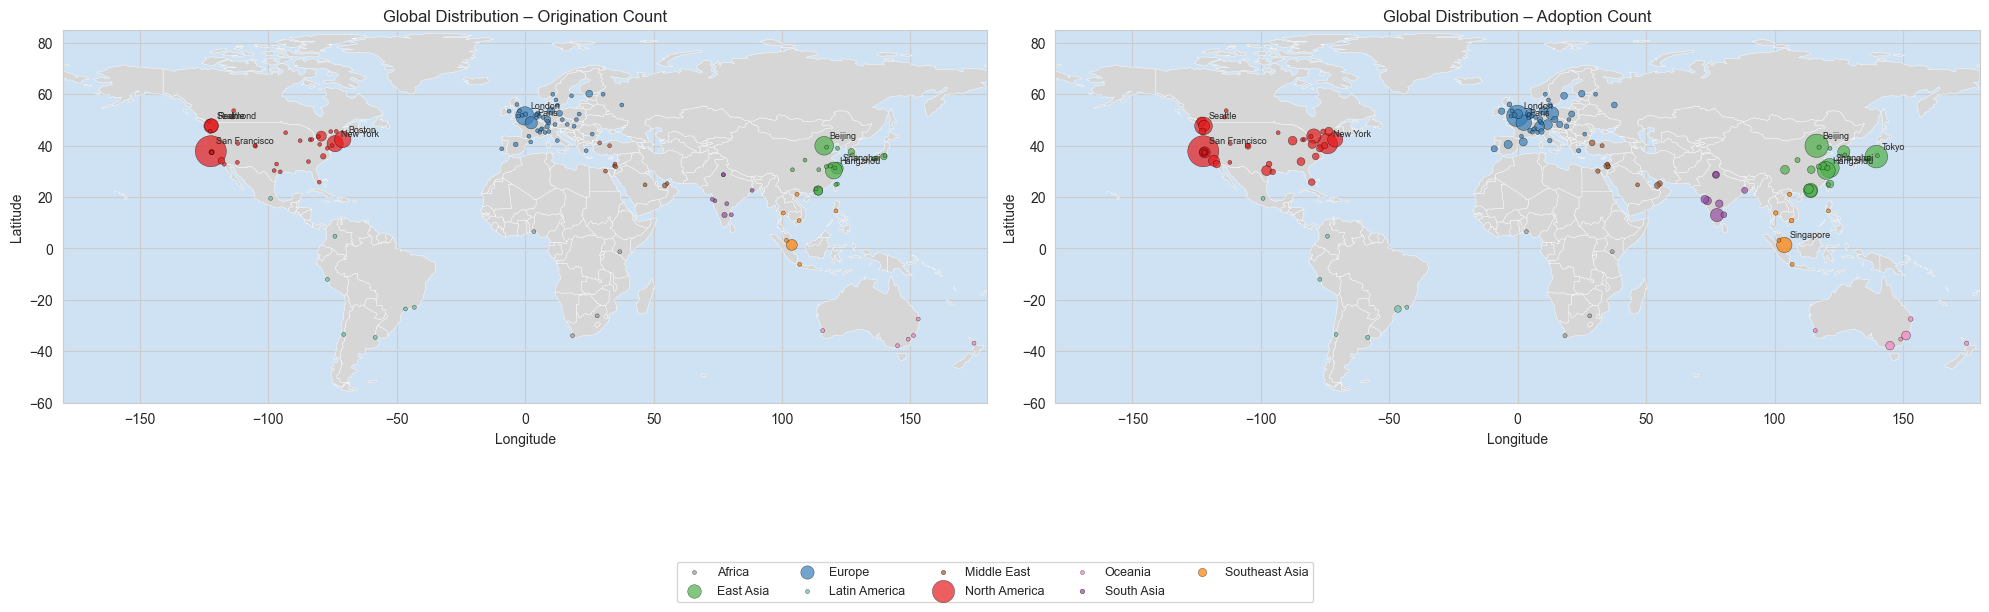

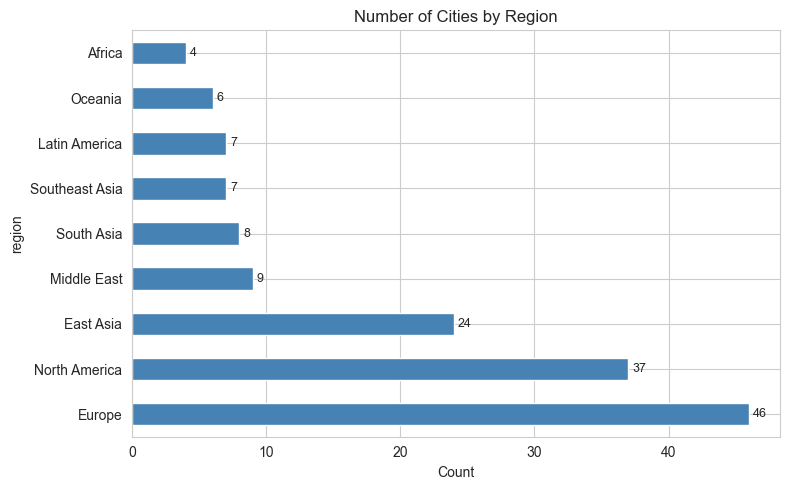

Origination: Top-10 cities account for 69.7%, Top-20 for 84.3%
Adoption: Top-10 cities account for 43.4%, Top-20 for 59.9%


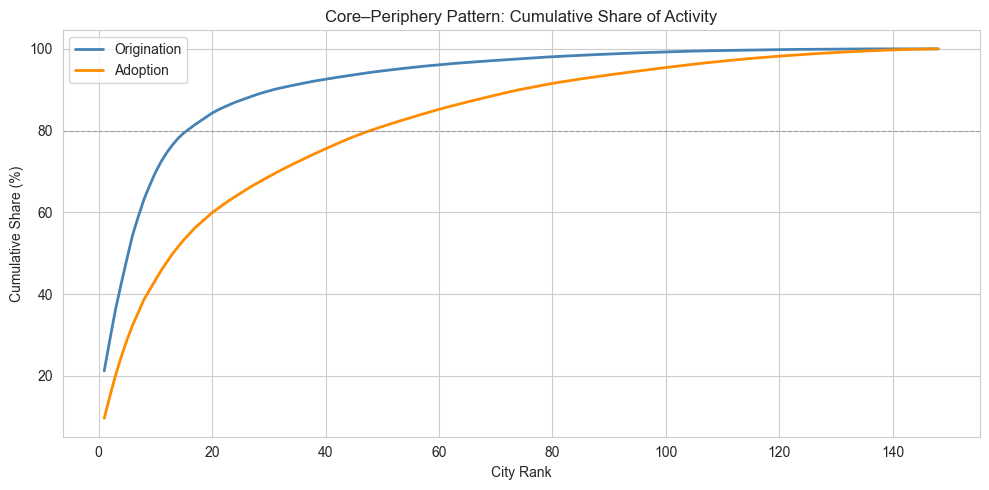

In [4]:
# Global scatter-map: bubble size = origination/adoption, colour = region
region_colors = {
    'North America': '#e41a1c', 'Europe': '#377eb8', 'East Asia': '#4daf4a',
    'South Asia': '#984ea3', 'Southeast Asia': '#ff7f00', 'Middle East': '#a65628',
    'Oceania': '#f781bf', 'Africa': '#999999', 'Latin America': '#66c2a5',
}

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for ax, (size_col, title) in zip(axes, [
    ('origination_count', 'Origination Count'),
    ('adoption_count',    'Adoption Count'),
]):
    # ── World map base layer ──
    world.plot(ax=ax, color='#d6d6d6', edgecolor='white', linewidth=0.3)
    ax.set_facecolor('#cfe2f3')
    ax.set_xlim(-180, 180)
    ax.set_ylim(-60, 85)

    # ── City bubbles ──
    sizes = city_attr[size_col].fillna(0)
    sizes_scaled = (sizes / sizes.max() * 500).clip(lower=8)

    for region, grp in city_attr.groupby('region'):
        ax.scatter(grp['lon'], grp['lat'],
                   s=sizes_scaled.loc[grp.index],
                   c=region_colors.get(region, 'grey'),
                   alpha=0.7, edgecolors='black', linewidth=0.3,
                   label=region, zorder=3)

    # ── Label top 10 cities ──
    top10 = city_attr.nlargest(10, size_col)
    for _, row in top10.iterrows():
        ax.annotate(row['city'], (row['lon'], row['lat']),
                    fontsize=6.5, ha='left', va='bottom',
                    xytext=(4, 4), textcoords='offset points', zorder=4)

    ax.set_title(f'Global Distribution – {title}', fontsize=12)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.show()

#  Visualisation of number of cities by region
fig, ax = plt.subplots(figsize=(8, 5))

region_counts = city_attr['region'].value_counts()
region_counts.plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Number of Cities by Region')
ax.set_xlabel('Count')
for i, v in enumerate(region_counts.values):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Core-periphery pattern: cumulative share of origination/adoption
for col, label in [('origination_count', 'Origination'), ('adoption_count', 'Adoption')]:
    sorted_vals = city_attr[col].sort_values(ascending=False).values
    cumulative = np.cumsum(sorted_vals) / sorted_vals.sum() * 100
    top10_share = cumulative[9] if len(cumulative) >= 10 else cumulative[-1]
    top20_share = cumulative[19] if len(cumulative) >= 20 else cumulative[-1]
    print(f'{label}: Top-10 cities account for {top10_share:.1f}%, '
          f'Top-20 for {top20_share:.1f}%')

fig, ax = plt.subplots(figsize=(10, 5))
for col, label, color in [
    ('origination_count', 'Origination', 'steelblue'),
    ('adoption_count', 'Adoption', 'darkorange'),
]:
    sorted_vals = city_attr[col].sort_values(ascending=False).values
    cumulative = np.cumsum(sorted_vals) / sorted_vals.sum() * 100
    ax.plot(range(1, len(cumulative)+1), cumulative, label=label, color=color, lw=2)

ax.axhline(80, color='grey', ls='--', lw=0.8, alpha=0.6)
ax.set_xlabel('City Rank')
ax.set_ylabel('Cumulative Share (%)')
ax.set_title('Core–Periphery Pattern: Cumulative Share of Activity', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()


Origination is spatially concentrated around a few North American and European hubs, while adoption shows a broader global footprint. 

Core–periphery structure: origination is far more concentrated than adoption; adoption spreads more broadly across the urban hierarchy.

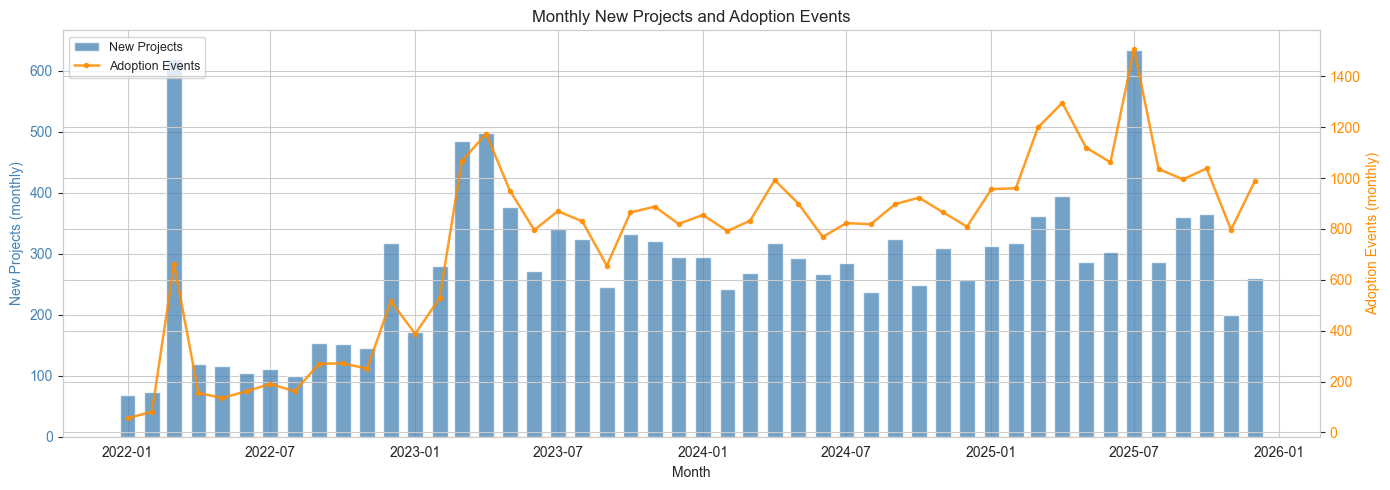

In [5]:
# Monthly time series: new projects and adoption events (combined)
def month_int_to_date(m):
    y, mo = divmod(int(m), 100)
    return pd.Timestamp(y, mo, 1)

# Align to the same cut-off month: latest project creation month vs latest adoption month may differ; take the earlier one to avoid one-sided tail
max_origin_ym = adoption.drop_duplicates('project_id')['global_origin_month'].max()
max_adopt_ym = adoption['city_first_adoption_month'].max()
cutoff_ym = min(max_origin_ym, max_adopt_ym)

proj_monthly = (adoption.drop_duplicates('project_id')
                .loc[lambda d: d['global_origin_month'] <= cutoff_ym]
                .groupby('global_origin_month').size()
                .rename('new_projects'))
proj_monthly.index = proj_monthly.index.map(month_int_to_date)

adopt_monthly = (adoption.loc[adoption['city_first_adoption_month'] <= cutoff_ym]
                 .groupby('city_first_adoption_month').size()
                 .rename('adoption_events'))
adopt_monthly.index = adopt_monthly.index.map(month_int_to_date)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(proj_monthly.index, proj_monthly.values, width=20,
        color='steelblue', edgecolor='white', alpha=0.75, label='New Projects')
ax1.set_ylabel('New Projects (monthly)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(adopt_monthly.index, adopt_monthly.values,
         color='darkorange', linewidth=1.8, marker='o', markersize=3,
         alpha=0.85, label='Adoption Events')
ax2.set_ylabel('Adoption Events (monthly)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax1.set_xlabel('Month')
ax1.set_title('Monthly New Projects and Adoption Events', fontsize=12)
plt.tight_layout()
plt.show()

#### 4.1.3 Diffusion Speed


Diffusion speed is measured by the **Inter-Event Interval (IEI)** — for each adoption event, the number of months since the previous city adopted the same project. A smaller IEI implies faster diffusion. The log-transform $\log(1+\text{IEI})$ reduces right-skew and stabilises variance for downstream modelling.

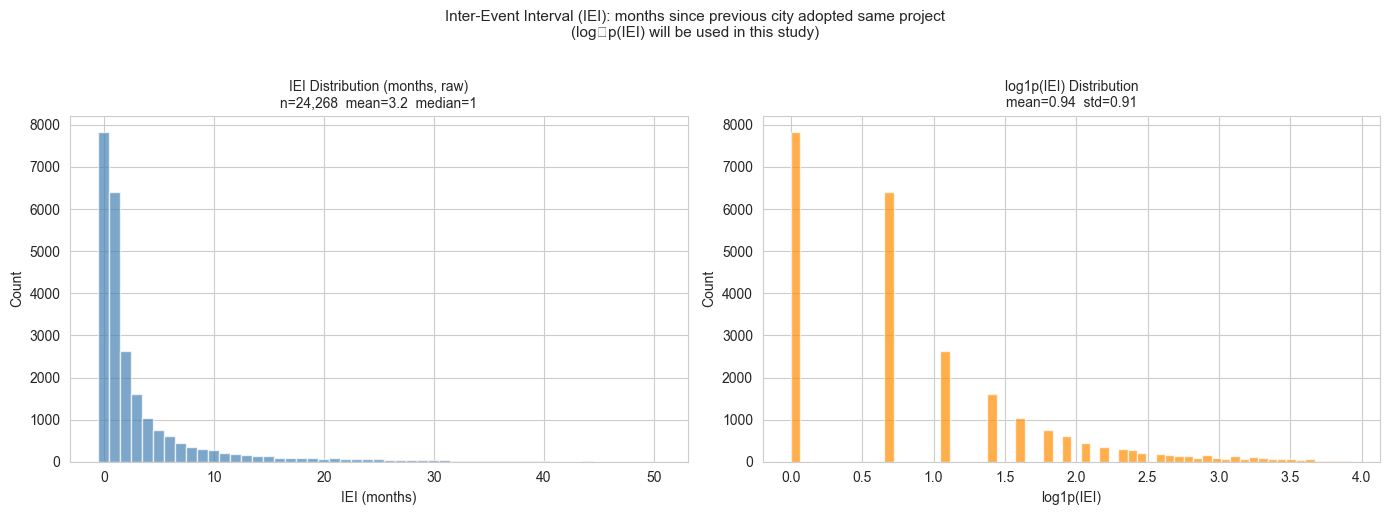

In [6]:
# IEI Distribution – raw and log1p
# interval = time gap since previous city adoption of same project
# Filtered: non-originator (lag > 0), non-negative interval
iei_events = _adp_eda[(_adp_eda['lag'] > 0) & (_adp_eda['interval'] >= 0)].copy()
log_iei = np.log1p(iei_events['interval'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

max_iei = int(iei_events['interval'].max())
axes[0].hist(iei_events['interval'], bins=np.arange(-0.5, max_iei + 1.5, 1),
             edgecolor='white', alpha=0.7, color='steelblue')
axes[0].set_title(f'IEI Distribution (months, raw)\n'
                  f'n={len(iei_events):,}  mean={iei_events["interval"].mean():.1f}'
                  f'  median={iei_events["interval"].median():.0f}', fontsize=10)
axes[0].set_xlabel('IEI (months)')
axes[0].set_ylabel('Count')

axes[1].hist(log_iei, bins=60, edgecolor='white', alpha=0.7, color='darkorange')
axes[1].set_title(f'log1p(IEI) Distribution\nmean={log_iei.mean():.2f}  std={log_iei.std():.2f}',
                  fontsize=10)
axes[1].set_xlabel('log1p(IEI)')
axes[1].set_ylabel('Count')

fig.suptitle('Inter-Event Interval (IEI): months since previous city adopted same project\n'
             '(log₁p(IEI) will be used in this study)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

Cities with IEI data: 148
City-level mean IEI: mean=3.0, median=1.0 months


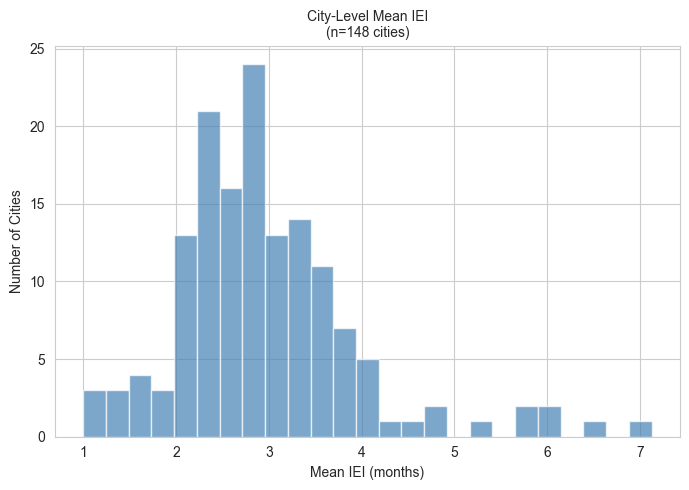

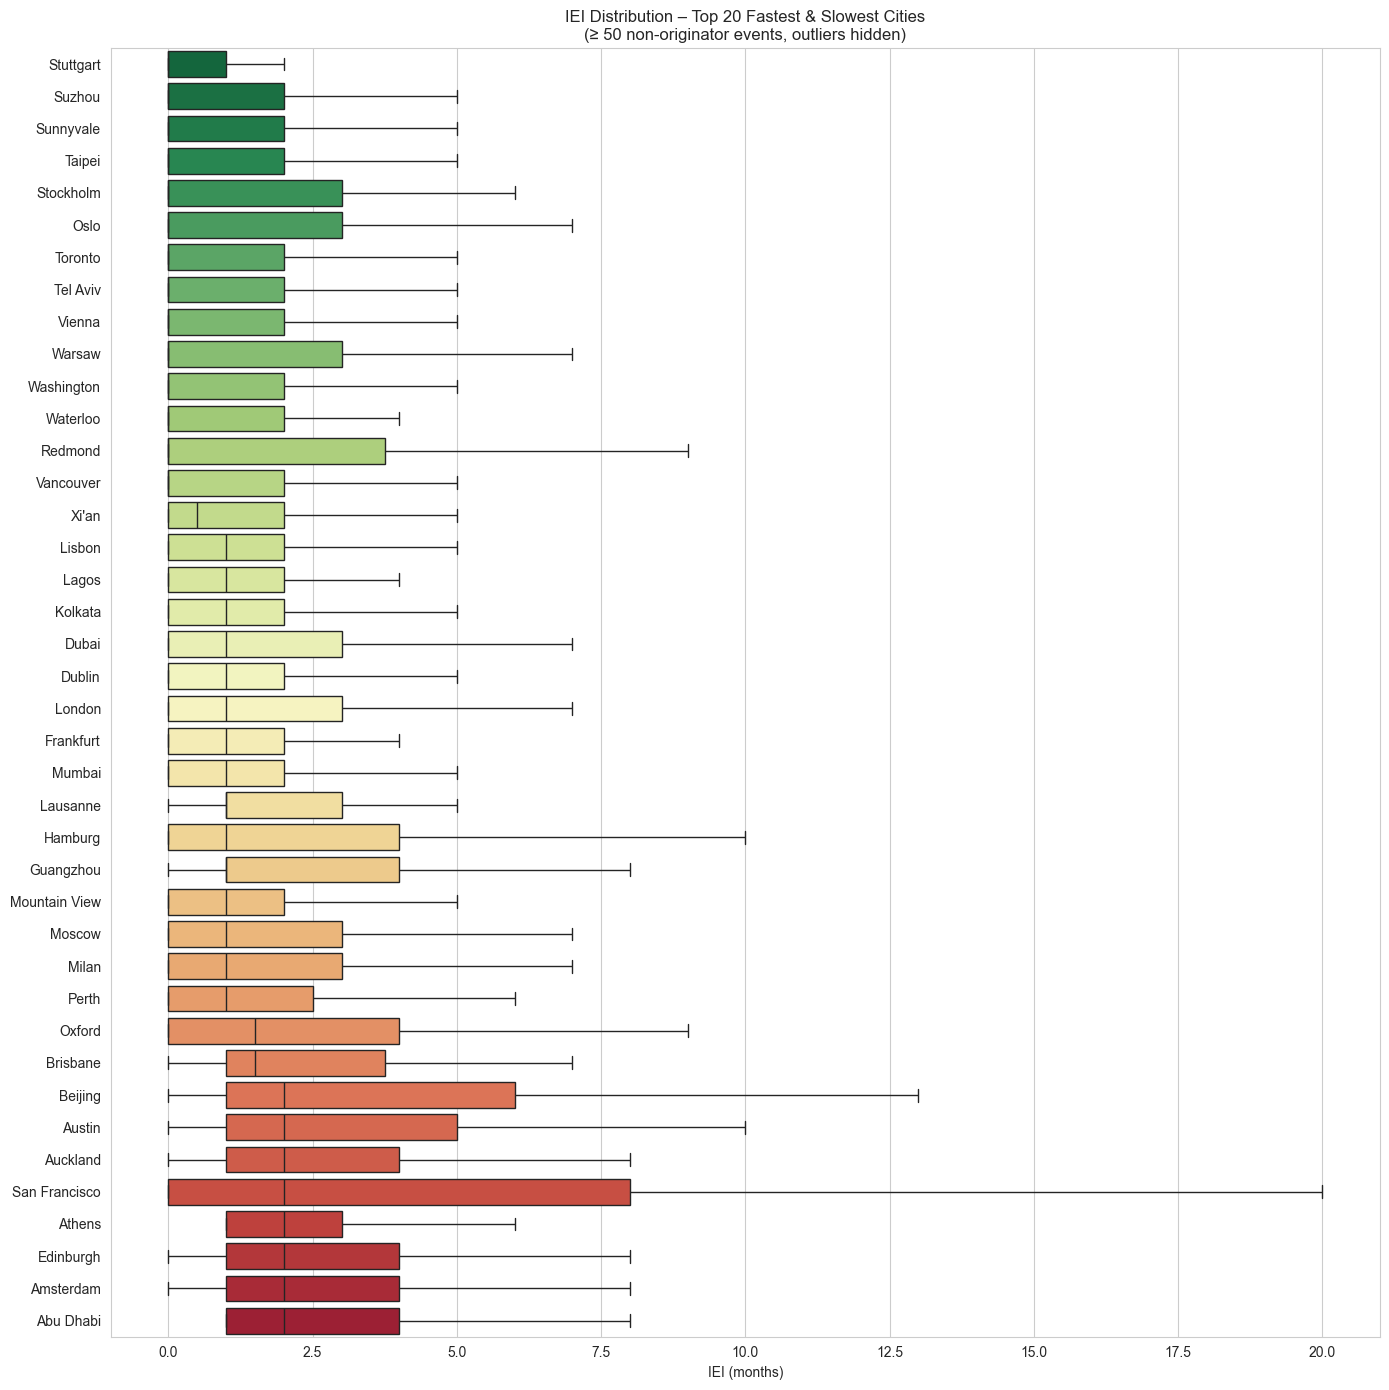

In [7]:
# City-level IEI statistics
city_iei = (
    iei_events.groupby('city')
    .agg(n_events=('interval', 'count'),
         mean_iei=('interval', 'mean'),
         median_iei=('interval', 'median'),
         std_iei=('interval', 'std'))
    .reset_index()
)
city_iei = city_iei.merge(
    city_attr[['city', 'region', 'origination_count', 'betweenness']],
    on='city', how='left')

print(f"Cities with IEI data: {len(city_iei)}")
print(f"City-level mean IEI: mean={city_iei['mean_iei'].mean():.1f}, "
      f"median={city_iei['median_iei'].median():.1f} months")

fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(city_iei['mean_iei'].dropna(), bins=25, edgecolor='white',
        alpha=0.7, color='steelblue')
ax.set_title(f'City-Level Mean IEI\n(n={len(city_iei)} cities)', fontsize=10)
ax.set_xlabel('Mean IEI (months)')
ax.set_ylabel('Number of Cities')

plt.tight_layout()
plt.show()

# Prepare event-level IEI dataframe
df_iei = iei_events.copy()
df_iei = df_iei.merge(city_attr[['city', 'region']], on='city', how='left')
MIN_EVENTS = 50

city_iei_spd = df_iei.groupby('city')['interval'].agg(
    count='count', mean='mean', median='median', std='std'
).reset_index()
city_iei_spd = city_iei_spd[city_iei_spd['count'] >= MIN_EVENTS].sort_values('median')
top_n = 20
top_cities = city_iei_spd.head(top_n)['city'].tolist() + city_iei_spd.tail(top_n)['city'].tolist()
top_cities = list(dict.fromkeys(top_cities))

plot_df = df_iei[df_iei['city'].isin(top_cities)].copy()
city_order = city_iei_spd[city_iei_spd['city'].isin(top_cities)].sort_values('median')['city'].tolist()

fig, ax = plt.subplots(figsize=(14, max(8, len(city_order) * 0.35)))
sns.boxplot(data=plot_df, y='city', x='interval', order=city_order,
            showfliers=False, palette='RdYlGn_r', ax=ax)
ax.set_title(f'IEI Distribution – Top {top_n} Fastest & Slowest Cities\n'
             f'(≥ {MIN_EVENTS} non-originator events, outliers hidden)', fontsize=12)
ax.set_xlabel('IEI (months)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

#### 4.1.4 Feature Correlation

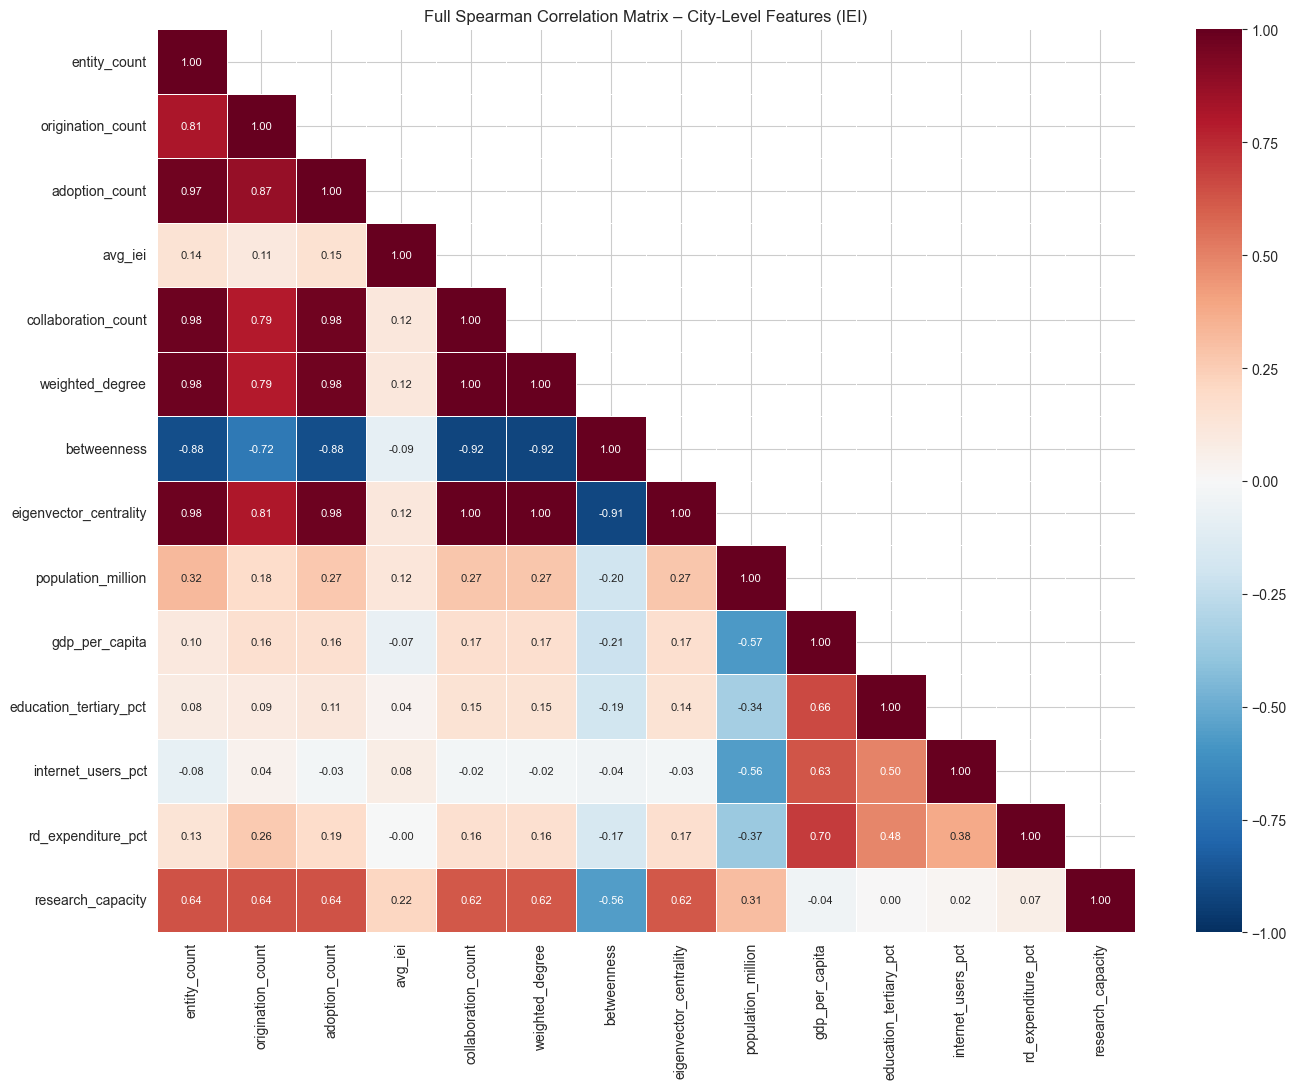

In [8]:
# Full Spearman correlation heatmap
all_corr_cols = [
    'entity_count', 'origination_count', 'adoption_count',
    'avg_iei', 'collaboration_count', 'weighted_degree',
    'betweenness', 'eigenvector_centrality',
    'population_million', 'gdp_per_capita',
    'education_tertiary_pct', 'internet_users_pct', 'rd_expenditure_pct',
    'research_capacity'
]

corr_matrix = city_attr[all_corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Full Spearman Correlation Matrix – City-Level Features (IEI)', fontsize=12)
plt.tight_layout()
plt.show()

Spearman correlation shows activity variables are tightly clustered (ρ > 0.7), socioeconomic indicators associate positively with activity, and `avg_iei` correlates negatively with activity — core cities diffuse faster.

#### 4.1.5 Collaboration Graph


The collaboration network is an undirected weighted graph: **nodes** are cities, **edges** link city pairs whose contributors co-occur in the same project, and **weights** count the number of shared projects. We aggregate contributor–city pairs per project, then count co-occurrences across all city dyads.

=== Network Summary ===
Nodes (cities): 148
Edges (city pairs): 9636
Density: 0.8858
Connected components: 1
Diameter: 2
Average shortest path: 1.11
Average clustering coefficient: 0.0198
Transitivity: 0.9184

Degree (weighted):
  Mean: 2289.1
  Max:  13337 (San Francisco)
  Min:  64


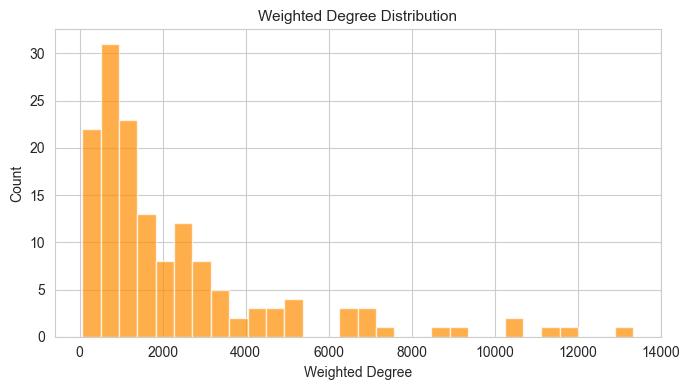

In [9]:
# Build the aggregate collaboration network
G = nx.Graph()
for _, row in edges_agg.iterrows():
    G.add_edge(row['source_city'], row['target_city'], weight=row['edge_weight'])

print('=== Network Summary ===')
print(f'Nodes (cities): {G.number_of_nodes()}')
print(f'Edges (city pairs): {G.number_of_edges()}')
print(f'Density: {nx.density(G):.4f}')
print(f'Connected components: {nx.number_connected_components(G)}')
if nx.is_connected(G):
    print(f'Diameter: {nx.diameter(G)}')
    print(f'Average shortest path: {nx.average_shortest_path_length(G):.2f}')
print(f'Average clustering coefficient: {nx.average_clustering(G, weight="weight"):.4f}')
print(f'Transitivity: {nx.transitivity(G):.4f}')

degrees = dict(G.degree(weight='weight'))
deg_vals = list(degrees.values())
print(f'\nDegree (weighted):')
print(f'  Mean: {np.mean(deg_vals):.1f}')
print(f'  Max:  {max(deg_vals):.0f} ({max(degrees, key=degrees.get)})')
print(f'  Min:  {min(deg_vals):.0f}')

# Degree distribution – Weighted
deg_vals = [d for _, d in G.degree(weight='weight')]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(deg_vals, bins=30, edgecolor='white', color='darkorange', alpha=0.7)
ax.set_title('Weighted Degree Distribution', fontsize=11)
ax.set_xlabel('Weighted Degree')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

The aggregate collaboration graph is near-complete in binary terms but **weighted** degree is strongly right-skewed — a few mega-hubs dominate tie strength.

### 4.2 K-Means Clustering for City Roles

This section addresses **RQ1** — *What distinct roles do global cities play in the ecosystem of prominent open-AI projects.*

We apply K-Means clustering to classify global cities into four roles: **Innovator** (high origination), **Adopter** (high adoption), **Connector** (bridging cross-region links), and **Dormant** (low overall activity). The workflow proceeds as follows:

#### 4.2.1 Feature Construction
Eleven z-standardised features span innovation output, adoption breadth, network centrality, diffusion speed (IEI), geographic reach, and project quality engagement.

In [10]:
df = city_attr.copy()

# log1p transforms of source columns.
df['log_origination'] = np.log1p(df['origination_count'])
df['log_adoption']    = np.log1p(df['adoption_count'])
df['log_betweenness'] = np.log1p(df['betweenness'] * 1000)
df['log_orig_rate']   = np.log1p(df['origination_rate_pop'])
df['log_iei_std']     = np.log1p(df['iei_std'])   # iei_std: std of interval per city

_adp_iei = add_iei_columns(
    adoption[['city', 'project_id', 'city_first_adoption_month',
              'global_origin_month', 'lag']])
_iei_city = (
    _adp_iei[(_adp_iei['lag'] > 0) & (_adp_iei['interval'] >= 0)]
    .groupby('city')['interval'].mean()
    .rename('avg_iei')
)
df = df.drop(columns=['avg_iei'], errors='ignore')
df = df.merge(_iei_city.reset_index(), on='city', how='left')
df['log_avg_iei'] = np.log1p(df['avg_iei'].fillna(df['avg_iei'].median()))

cluster_features = [
    'log_origination',
    'log_adoption',  
    'log_betweenness',
    'log_orig_rate', 
    'log_avg_iei',
    'log_iei_std', 
    'cross_region_ratio_calc',
    'pop_top25_share',
    'orig_top25_share',
    'iei_quality_corr',  
    'avg_fork_star_ratio',  
]

FEAT_LABELS = [
    'Origination', 'Adoption', 'Betweenness', 'Orig rate (pop)',
    'Avg IEI', 'IEI std', 'Cross-region', 'Top-25% share',
    'Orig quality', 'IEI–quality corr', 'Fork/star ratio'
]

X_raw = df[cluster_features].copy()

,Feature,Label,z-mean,z-std,z-min,z-max
0,log_origination,Origination,0.0,1.003,-1.447,3.139
1,log_adoption,Adoption,0.0,1.003,-2.796,2.833
2,log_betweenness,Betweenness,0.0,1.003,-1.176,3.190
3,log_orig_rate,Orig rate (pop),-0.0,1.003,-1.070,4.437
4,log_avg_iei,Avg IEI,-0.0,1.003,-2.792,3.165
5,log_iei_std,IEI std,0.0,1.003,-2.758,2.755
6,cross_region_ratio_calc,Cross-region,0.0,1.003,-2.001,1.818
7,pop_top25_share,Top-25% share,0.0,1.003,-3.787,2.451
8,orig_top25_share,Orig quality,-0.0,1.003,-1.906,3.146
9,iei_quality_corr,IEI–quality corr,0.0,1.003,-4.150,3.512


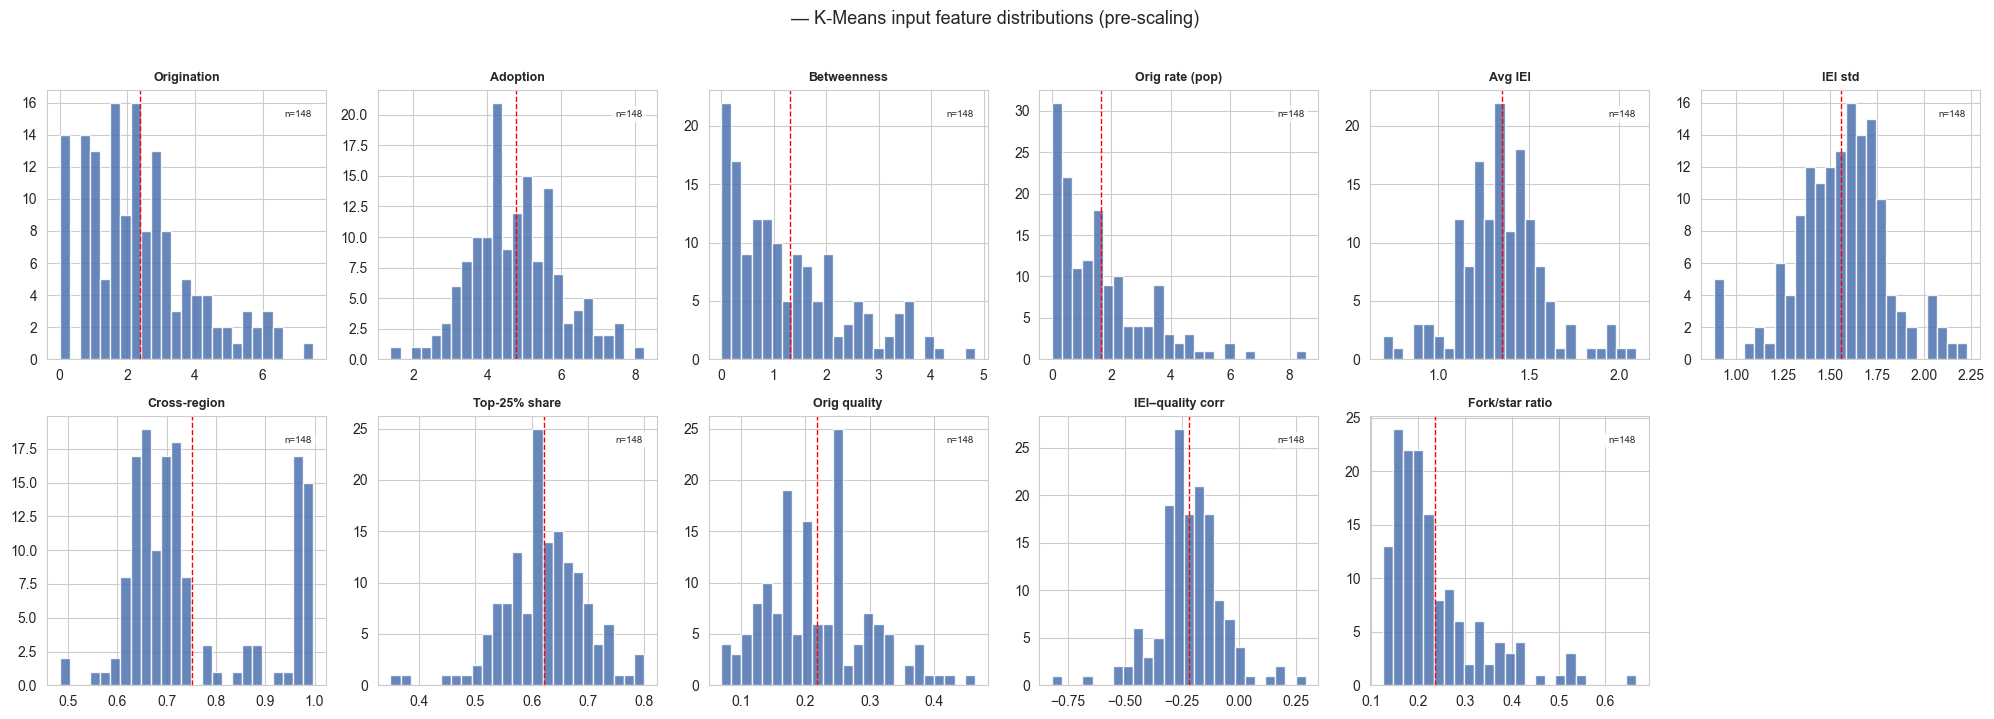

In [11]:
X_raw = X_raw.dropna()
df = df.loc[X_raw.index]

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
X_df = pd.DataFrame(X, columns=cluster_features, index=X_raw.index)

feature_table_6 = pd.DataFrame({
    'Feature': cluster_features,
    'Label': FEAT_LABELS,
    'z-mean': X_df.mean().round(3).values,
    'z-std': X_df.std().round(3).values,
    'z-min': X_df.min().round(3).values,
    'z-max': X_df.max().round(3).values,
})
display(feature_table_6)

fig_inp, axes_inp = plt.subplots(2, 6, figsize=(20, 7))
axes_inp = axes_inp.flatten()
for idx, (col, label) in enumerate(zip(cluster_features, FEAT_LABELS)):
    ax = axes_inp[idx]
    d = X_raw[col].dropna()
    ax.hist(d, bins=25, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax.axvline(d.mean(), color='red', ls='--', lw=1)
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.annotate(f'n={len(d)}', xy=(0.95, 0.90),
                xycoords='axes fraction', ha='right', fontsize=7,
                bbox=dict(boxstyle='round', fc='white', alpha=0.8))
axes_inp[-1].set_visible(False)
fig_inp.suptitle('— K-Means input feature distributions (pre-scaling)',
                 fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

#### 4.2.2 Model Selection


In [12]:
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

test_k_values = [3, 4, 5]
N_INIT_HIGH = 50

# K-Means (k = 3, 4, 5)
kmeans_results = {}
for k in test_k_values:
    km = KMeans(n_clusters=k, n_init=N_INIT_HIGH, random_state=42, max_iter=500)
    labs = km.fit_predict(X)
    kmeans_results[k] = {
        'silhouette': silhouette_score(X, labs),
        'calinski_harabasz': calinski_harabasz_score(X, labs),
        'davies_bouldin': davies_bouldin_score(X, labs),
    }

# DBSCAN grid search
dbscan_grid = []
for eps in np.arange(0.8, 2.6, 0.2).round(2):
    for ms in [3, 5, 7, 10]:
        labs = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
        nc = len(set(labs)) - (1 if -1 in labs else 0)
        n_noise = (labs == -1).sum()
        sil = silhouette_score(X, labs) if nc >= 2 else np.nan
        dbscan_grid.append({'eps': eps, 'min_samples': ms, 'n_clusters': nc,
                            'n_noise': n_noise, 'noise_pct': n_noise / len(labs) * 100, 'silhouette': sil})
dbscan_grid_df = pd.DataFrame(dbscan_grid)
viable = dbscan_grid_df.dropna(subset=['silhouette']).query('n_clusters >= 2 and noise_pct < 40')
if len(viable) == 0:
    viable = dbscan_grid_df.dropna(subset=['silhouette']).query('n_clusters >= 2 and noise_pct < 60')
best_db_row = viable.sort_values('silhouette', ascending=False).iloc[0]
BEST_EPS, BEST_MS = best_db_row['eps'], int(best_db_row['min_samples'])
db_labels = DBSCAN(eps=BEST_EPS, min_samples=BEST_MS).fit_predict(X)

# GMM (k = 3, 4, 5)
gmm_results = {}
for k in test_k_values:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          n_init=10, random_state=42, max_iter=500)
    gmm.fit(X)
    labs = gmm.predict(X)
    gmm_results[k] = {
        'silhouette': silhouette_score(X, labs),
        'calinski_harabasz': calinski_harabasz_score(X, labs),
        'davies_bouldin': davies_bouldin_score(X, labs),
        'bic': gmm.bic(X),
    }

# Master Comparison Table
rows = []
for k in test_k_values:
    rows.append({'Method': f'K-Means (k={k})', 'k': k,
                 'Silhouette': kmeans_results[k]['silhouette'],
                 'CH': kmeans_results[k]['calinski_harabasz'],
                 'DB': kmeans_results[k]['davies_bouldin'], 'Noise %': 0.0})
for k in test_k_values:
    rows.append({'Method': f'GMM (k={k})', 'k': k,
                 'Silhouette': gmm_results[k]['silhouette'],
                 'CH': gmm_results[k]['calinski_harabasz'],
                 'DB': gmm_results[k]['davies_bouldin'], 'Noise %': 0.0})

db_n = int(best_db_row['n_clusters'])
db_ch = calinski_harabasz_score(X, db_labels) if db_n >= 2 else np.nan
db_db = davies_bouldin_score(X, db_labels) if db_n >= 2 else np.nan
rows.append({'Method': f'DBSCAN (eps={BEST_EPS}, ms={BEST_MS})', 'k': db_n,
             'Silhouette': best_db_row['silhouette'],
             'CH': db_ch, 'DB': db_db, 'Noise %': best_db_row['noise_pct']})

master = pd.DataFrame(rows).sort_values('Silhouette', ascending=False).reset_index(drop=True)
print('\u2550' * 80)
print('MASTER COMPARISON TABLE \u2013 ALL CLUSTERING APPROACHES')
print('\u2550' * 80)
display(master.round(4))


════════════════════════════════════════════════════════════════════════════════
MASTER COMPARISON TABLE – ALL CLUSTERING APPROACHES
════════════════════════════════════════════════════════════════════════════════


,Method,k,Silhouette,CH,DB,Noise %
0,K-Means (k=4),4,0.1582,26.1748,1.8207,0.000
1,GMM (k=3),3,0.1517,23.4225,2.1537,0.000
2,K-Means (k=3),3,0.1516,28.1931,2.0794,0.000
3,K-Means (k=5),5,0.1511,24.5428,1.7098,0.000
4,GMM (k=5),5,0.1442,21.3185,1.8392,0.000
5,GMM (k=4),4,0.1120,19.4283,1.9621,0.000
6,"DBSCAN (eps=2.4, ms=5)",2,0.0768,5.2928,3.3670,27.027


K-Means (k = 4) is selected over DBSCAN and GMM based on the highest silhouette score (0.158) and best Davies–Bouldin index, while also mapping to the theoretically motivated four-role typology. At the same time, k = 4 is also an appropriate number for the research objective of classifying city roles, as it produces clearly distinguishable city clusters and each cluster has strong interpretability.

#### 4.2.3 Clustering and Visualisation

K-Means (k = 4, n_init = 30) partitions cities into four roles — **Innovator, Connector, Adopter, Dormant**.

Cluster Profiles (mean values):


cluster,0.0,1.0,2.0,3.0
origination_count,1.880,8.290,229.090,10.860
adoption_count,33.480,117.770,826.940,125.100
weighted_degree,393.960,1452.770,5784.180,1576.760
betweenness,0.030,0.000,0.000,0.000
origination_rate_pop,1.700,1.900,234.670,8.920
adoption_rate_pop,31.700,18.420,650.170,104.500
Origination,0.802,1.806,4.649,2.046
Adoption,3.330,4.565,6.402,4.616
Betweenness,3.100,1.300,0.239,1.135
Orig rate (pop),0.667,0.649,3.563,1.545


Role assignments:
  Cluster 0.0 → Dormant                         (n= 25, orig=2, adopt=33, degree=394)
  Cluster 1.0 → Connector                       (n= 31, orig=8, adopt=118, degree=1453)
  Cluster 2.0 → Innovator                       (n= 33, orig=229, adopt=827, degree=5784)
  Cluster 3.0 → Adopter                         (n= 59, orig=11, adopt=125, degree=1577)


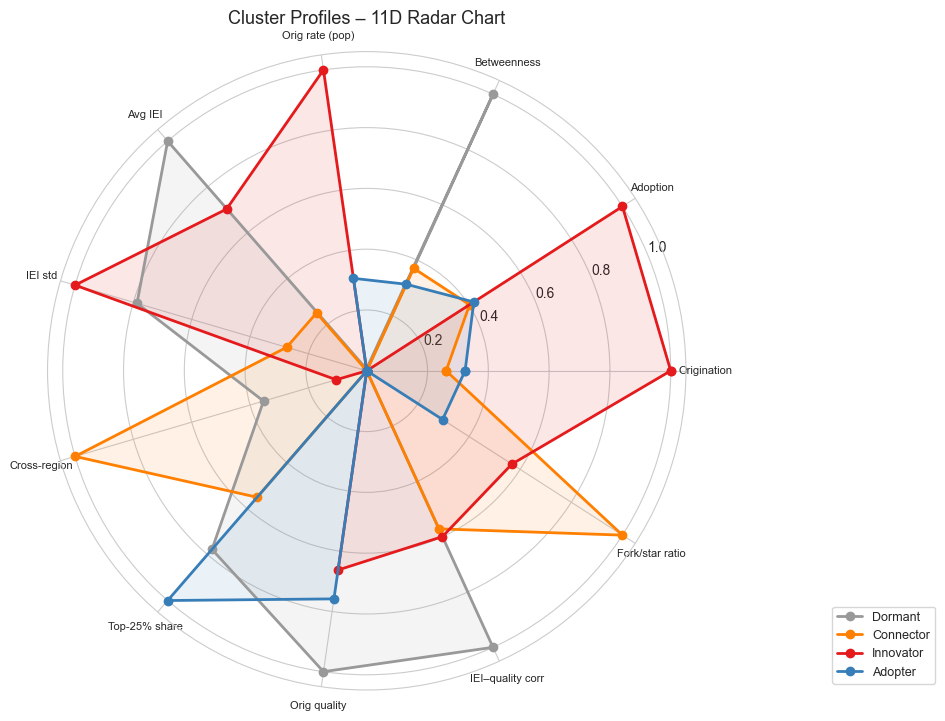

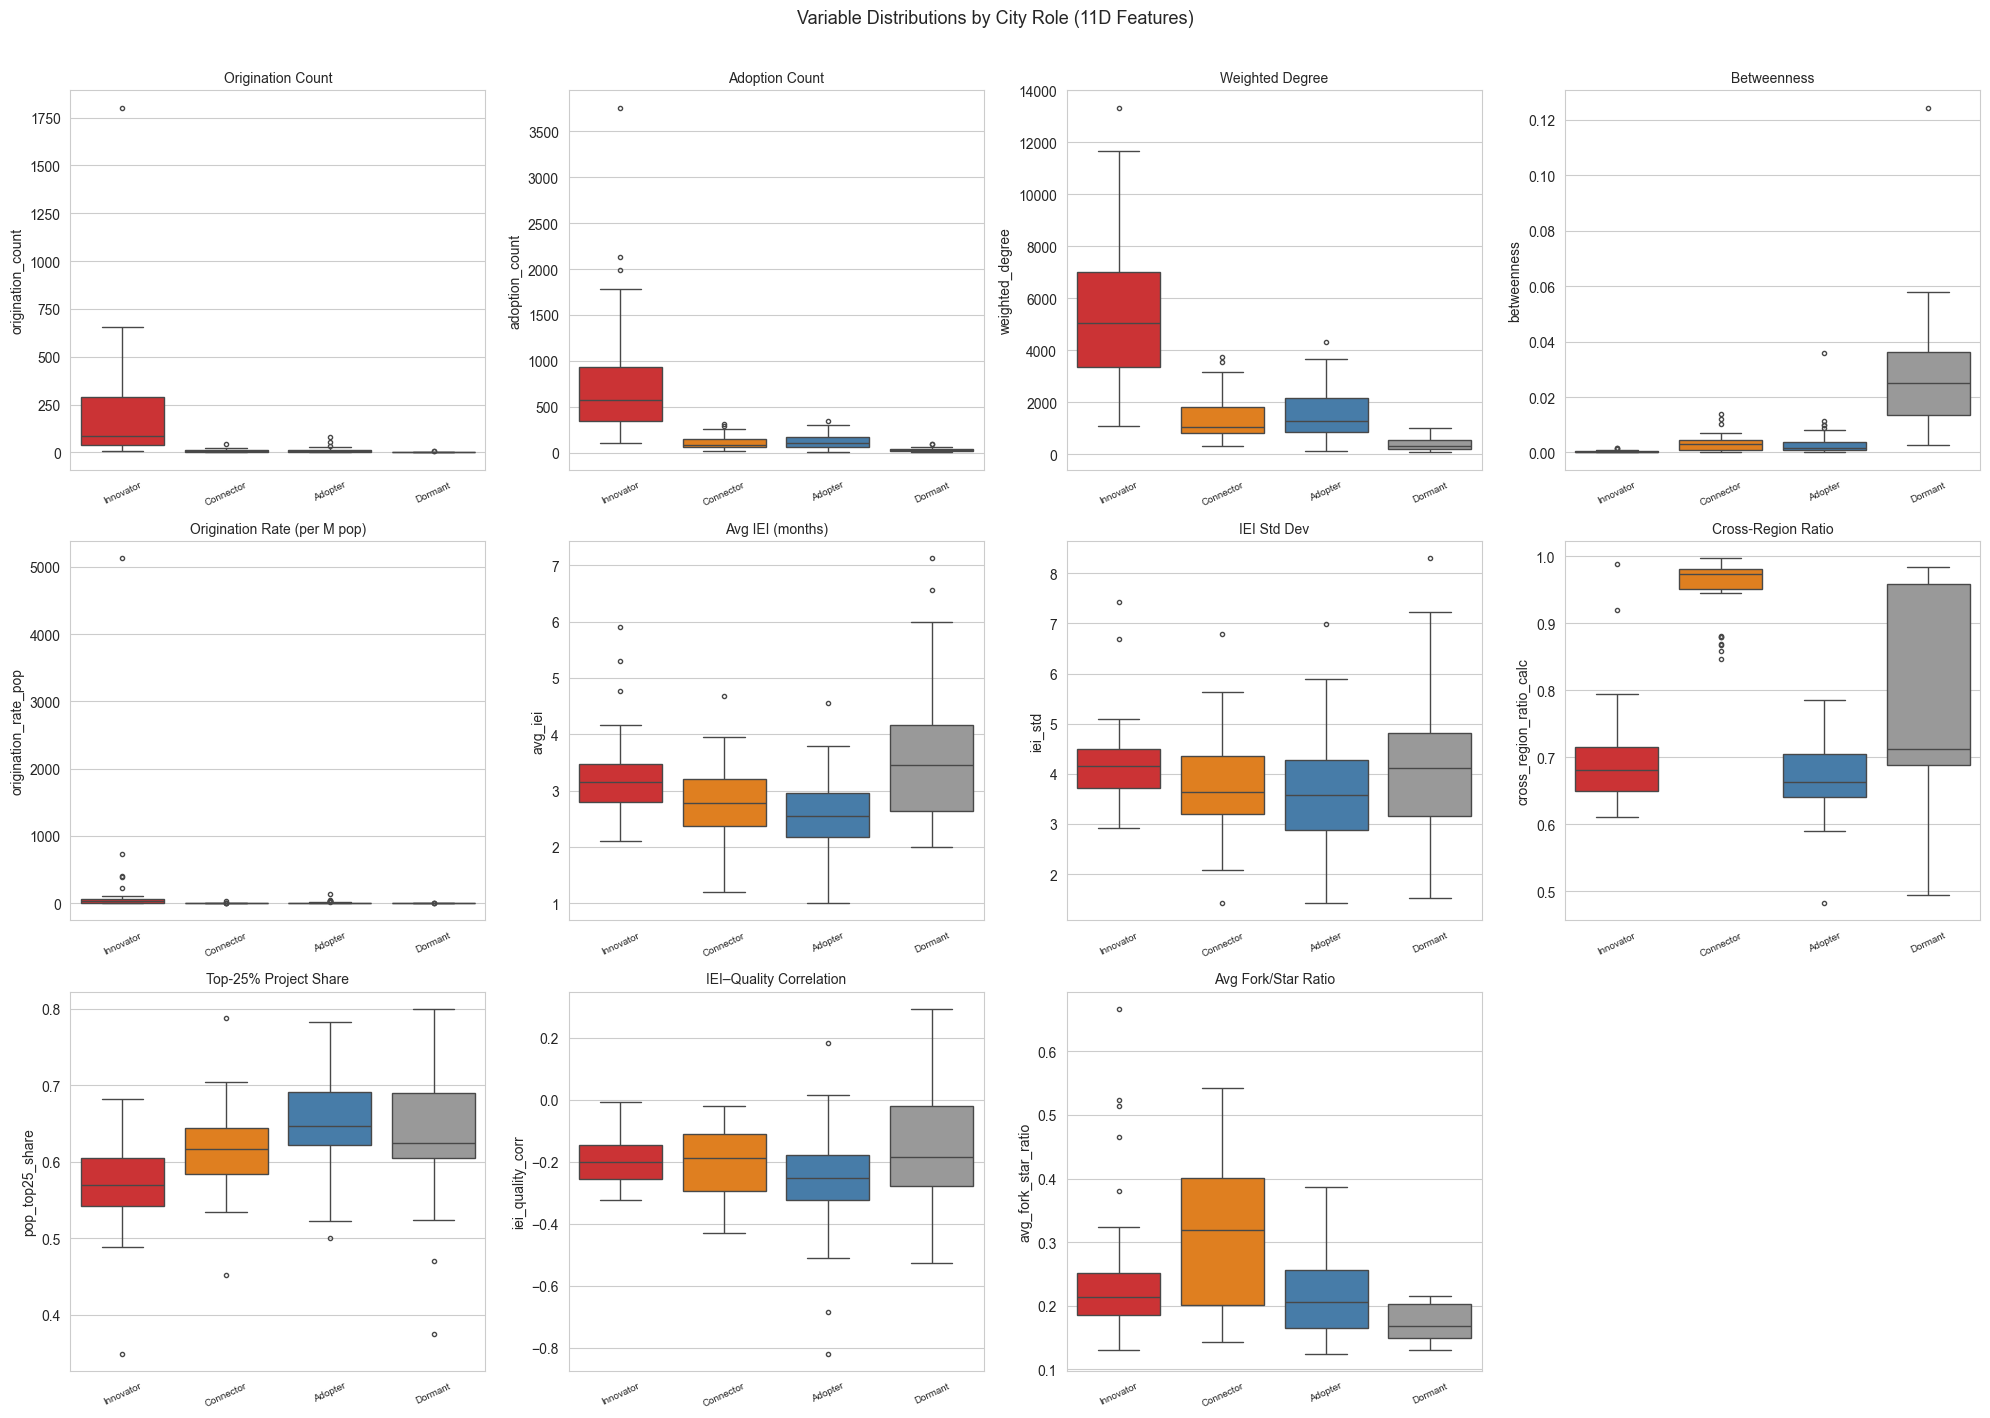

In [13]:
CHOSEN_K = 4

km_final = KMeans(n_clusters=CHOSEN_K, n_init=30, random_state=42, max_iter=500)
labels = km_final.fit_predict(X)

df['cluster'] = np.nan
df.loc[X_raw.index, 'cluster'] = labels

raw_cols = [
    'origination_count', 'adoption_count', 'weighted_degree',
    'betweenness', 'origination_rate_pop', 'adoption_rate_pop',
]
profiles = df.groupby('cluster')[raw_cols].mean().round(2)

for feat, label in zip(cluster_features, FEAT_LABELS):
    profiles[label] = df.groupby('cluster')[feat].mean().round(3)

profiles['n_cities'] = df.groupby('cluster').size()

print('Cluster Profiles (mean values):')
display(profiles.T)

cluster_order = profiles.sort_values('origination_count', ascending=False).index.tolist()

ROLE_LABELS = {}
remaining = list(cluster_order)

ROLE_LABELS[remaining.pop(0)] = 'Innovator'

bridge_candidates = remaining.copy()
bridge_id = max(bridge_candidates, key=lambda c: profiles.loc[c, 'Cross-region']
                if 'Cross-region' in profiles.columns
                else df.loc[df['cluster']==c, 'cross_region_ratio_calc'].mean())
ROLE_LABELS[bridge_id] = 'Connector'
remaining.remove(bridge_id)

if len(remaining) >= 2:
    active_id = max(remaining, key=lambda c: profiles.loc[c, 'adoption_count'])
    ROLE_LABELS[active_id] = 'Adopter'
    remaining.remove(active_id)

for c in remaining:
    ROLE_LABELS[c] = 'Dormant'

df['role'] = df['cluster'].map(ROLE_LABELS)

role_map = ROLE_LABELS
role_names_ordered = ['Innovator', 'Connector', 'Adopter', 'Dormant']

print('Role assignments:')
for cid, role in sorted(ROLE_LABELS.items()):
    n = (df['cluster'] == cid).sum()
    mean_orig = df.loc[df['cluster'] == cid, 'origination_count'].mean()
    mean_adopt = df.loc[df['cluster'] == cid, 'adoption_count'].mean()
    mean_deg = df.loc[df['cluster'] == cid, 'weighted_degree'].mean()
    print(f'  Cluster {cid} → {role:30s}  (n={n:3d}, '
          f'orig={mean_orig:.0f}, adopt={mean_adopt:.0f}, degree={mean_deg:.0f})')


radar_cols = cluster_features
radar_labels = FEAT_LABELS

centroids_std = pd.DataFrame(km_final.cluster_centers_, columns=cluster_features)
centroids_norm = (centroids_std - centroids_std.min()) / (centroids_std.max() - centroids_std.min() + 1e-9)

n_vars = len(radar_cols)
angles = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles += angles[:1]

role_colors = {
    'Innovator': '#e41a1c',
    'Connector': '#ff7f00',
    'Adopter': '#377eb8',
    'Dormant': '#999999',
}

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for cid in range(CHOSEN_K):
    role = role_map[cid]
    vals = centroids_norm.iloc[cid][radar_cols].tolist()
    vals += vals[:1]
    color = role_colors.get(role, 'grey')
    ax.plot(angles, vals, 'o-', lw=2, label=role, color=color)
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=8)
ax.set_title('Cluster Profiles – 11D Radar Chart', fontsize=13, pad=20)
ax.legend(loc='lower right', bbox_to_anchor=(1.4, 0), fontsize=9)
plt.tight_layout()
plt.show()

box_vars = [
    ('origination_count', 'Origination Count'),
    ('adoption_count', 'Adoption Count'),
    ('weighted_degree', 'Weighted Degree'),
    ('betweenness', 'Betweenness'),
    ('origination_rate_pop', 'Origination Rate (per M pop)'),
    ('avg_iei', 'Avg IEI (months)'),
    ('iei_std', 'IEI Std Dev'),
    ('cross_region_ratio_calc', 'Cross-Region Ratio'),
    ('pop_top25_share', 'Top-25% Project Share'),
    ('iei_quality_corr', 'IEI–Quality Correlation'),
    ('avg_fork_star_ratio', 'Avg Fork/Star Ratio'),
]

n_rows = 3
n_cols = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 14))
for i, (col, title) in enumerate(box_vars):
    ax = axes.flatten()[i]
    order = role_names_ordered
    palette = [role_colors[r] for r in order]
    sns.boxplot(data=df, x='role', y=col, order=order, palette=palette,
                ax=ax, fliersize=3)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='x', rotation=25, labelsize=7)
    ax.set_xlabel('')

for j in range(len(box_vars), n_rows * n_cols):
    axes.flatten()[j].set_visible(False)

plt.suptitle('Variable Distributions by City Role (11D Features)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Innovator** (n = 33, 22%): highest origination (mean 229) and adoption (827), with the densest collaboration (degree 5 784). **Adopter** (n = 59, 40%): moderate adoption (125) but low origination (11); the largest fast-follower group. **Connector** (n = 31, 21%): moderate activity yet the highest cross-region ratio, bridging geographically distant clusters. **Dormant** (n = 25, 17%): minimal origination (2), adoption (33), and connectivity (degree 394).

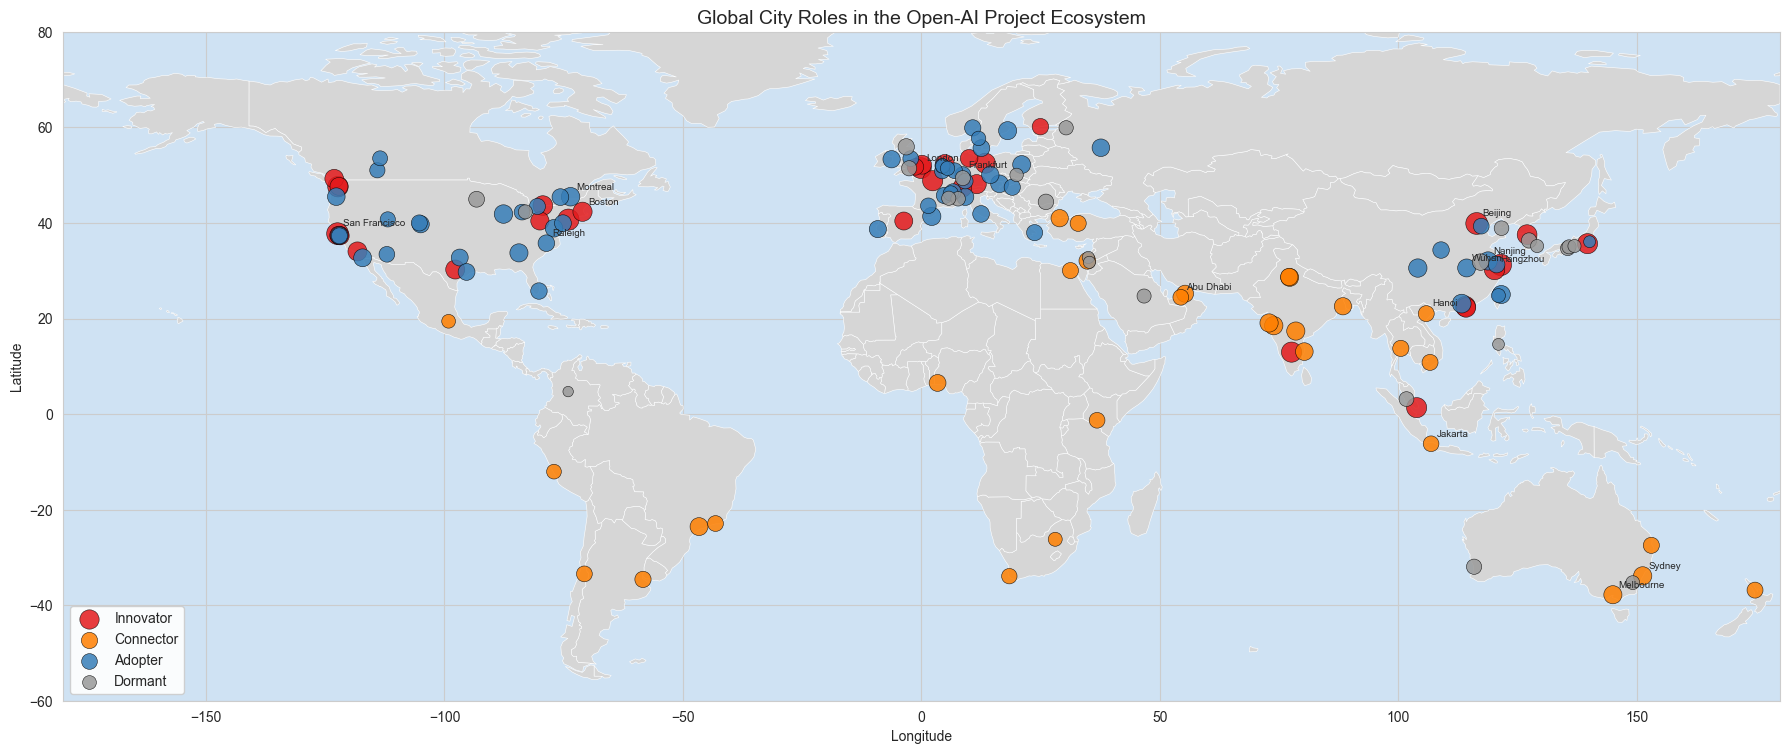

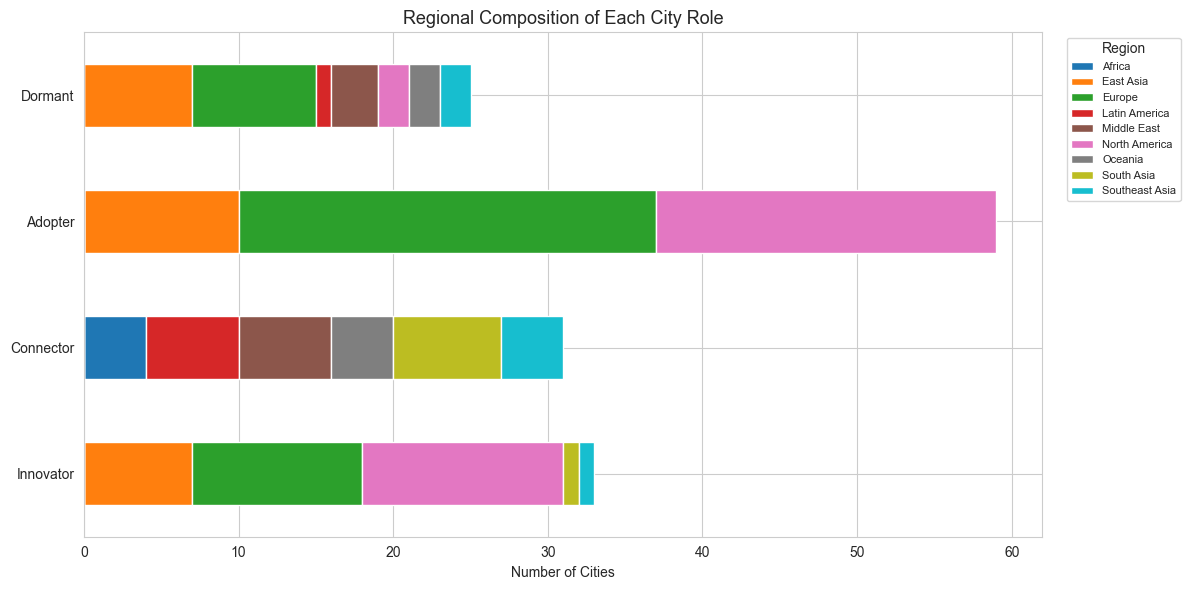

Regional composition:


region,Africa,East Asia,Europe,Latin America,Middle East,North America,Oceania,South Asia,Southeast Asia
role,,,,,,,,,
Innovator,0,7,11,0,0,13,0,1,1
Connector,4,0,0,6,6,0,4,7,4
Adopter,0,10,27,0,0,22,0,0,0
Dormant,0,7,8,1,3,2,2,0,2


REPRESENTATIVE CITIES BY ROLE

▸ Innovator (33 cities): San Francisco (United States), Beijing (China), London (United Kingdom), Hangzhou (China), Boston (United States)

▸ Connector (31 cities): Abu Dhabi (United Arab Emirates), Sydney (Australia), Hanoi (Vietnam), Melbourne (Australia), Jakarta (Indonesia)

▸ Adopter (59 cities): Frankfurt (Germany), Raleigh (United States), Nanjing (China), Wuhan (China), Montreal (Canada)

▸ Dormant (25 cities): Daejeon (South Korea), Hefei (China), Edinburgh (United Kingdom), Jerusalem (Israel), Kyoto (Japan)


In [14]:
# Global map: cities coloured by cluster role
import geopandas as gpd

_world = gpd.read_file(DATA_RAW + 'naturalearth/ne_110m_countries.geojson')

fig, ax = plt.subplots(figsize=(18, 9))
ax.set_facecolor('#cfe2f3')
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 80)

# World map base layer
_world.plot(ax=ax, color='#d6d6d6', edgecolor='white', linewidth=0.4, zorder=1)

# Bubble size ~ log(entity_count)
sizes = np.log1p(df['entity_count']) * 30 + 15

for role in role_names_ordered:
    mask = df['role'] == role
    color = role_colors.get(role, 'grey')
    ax.scatter(df.loc[mask, 'lon'], df.loc[mask, 'lat'],
               s=sizes[mask], c=color, alpha=0.85,
               edgecolors='black', linewidths=0.4, label=role, zorder=3)

# Label top cities per cluster
for role in role_names_ordered[:3]:  # label top roles
    subset = df[df['role'] == role].nlargest(5, 'origination_count')
    for _, row in subset.iterrows():
        ax.annotate(row['city'], (row['lon'], row['lat']),
                    fontsize=7, ha='left', va='bottom',
                    xytext=(4, 4), textcoords='offset points', zorder=4)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Global City Roles in the Open-AI Project Ecosystem', fontsize=14)
ax.legend(loc='lower left', fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()

# Regional composition of each cluster
role_region = pd.crosstab(df['role'], df['region'])
role_region = role_region.loc[role_names_ordered]

fig, ax = plt.subplots(figsize=(12, 6))
role_region.plot.barh(stacked=True, ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Regional Composition of Each City Role', fontsize=13)
ax.set_xlabel('Number of Cities')
ax.set_ylabel('')
ax.legend(title='Region', bbox_to_anchor=(1.02, 1), fontsize=8)
plt.tight_layout()
plt.show()

print('Regional composition:')
display(role_region)

# Representative cities per role (top 5 by origination)
print('=' * 70)
print('REPRESENTATIVE CITIES BY ROLE')
print('=' * 70)

for role in role_names_ordered:
    subset = df[df['role'] == role].sort_values('origination_count', ascending=False)
    n = len(subset)
    top = subset.head(5)
    cities_str = ', '.join(f'{r["city"]} ({r["country"]})' for _, r in top.iterrows())
    print(f'\n▸ {role} ({n} cities): {cities_str}')

Roles are geographically non-random: Innovators concentrate in North America, East Asia, and Europe; Connectors span the most diverse regions (Africa, South Asia, Oceania); Adopters cluster in Europe and North America; Dormant cities are scattered with no strong regional pattern.

### 4.3 Linear Regression Analysis: City-Level Innovation Intensity

This section addresses **RQ2** — *which city characteristics are associated with innovation-oriented roles.* Linear regresses `originator_share` on 11 z-standardised city-level predictors (structural, economic, network).

#### 4.3.1 Feature Construction


City-level observations: 148

originator_share:   mean=0.1111, std=0.1264
log_adoption:       mean=4.79, std=1.22
avg_iei (non-orig):  mean=2.97, std=1.00, n=148
REGRESSION VARIABLE DICTIONARY

▸ Independent Variables (IVs) — 11 city-level predictors (CITY_IV_MAIN_11):


,Variable,Description,Type
0,log_degree,log1p(weighted degree centrality),Network
1,log_population,log1p(population in millions),Socio-economic
2,gdp_raw,"GDP per capita (raw USD, symmetric skew=0.07)",Socio-economic
3,log_entity,log1p(active developer/entity count),Network
4,education_tertiary_pct,Tertiary education attainment (%),Human capital
5,internet_reflect,Reflect-log: log1p(100 − internet_users_pct),Infrastructure
6,rd_expenditure_pct,R&D expenditure (% of GDP),Innovation input
7,research_log,log1p(research_capacity),Innovation input
8,betweenness_log,log1p(betweenness × 10 000),Network
9,log_entity_per_cap,log1p(entity_count / population_million),Network



▸ Dependent Variables (DVs):


,Variable,Description,Model
0,originator_share,Origination / Adoption — arcsin-sqrt transformed,City Innovation Regression



City-level sample: n = 148 cities with adoption_count > 0


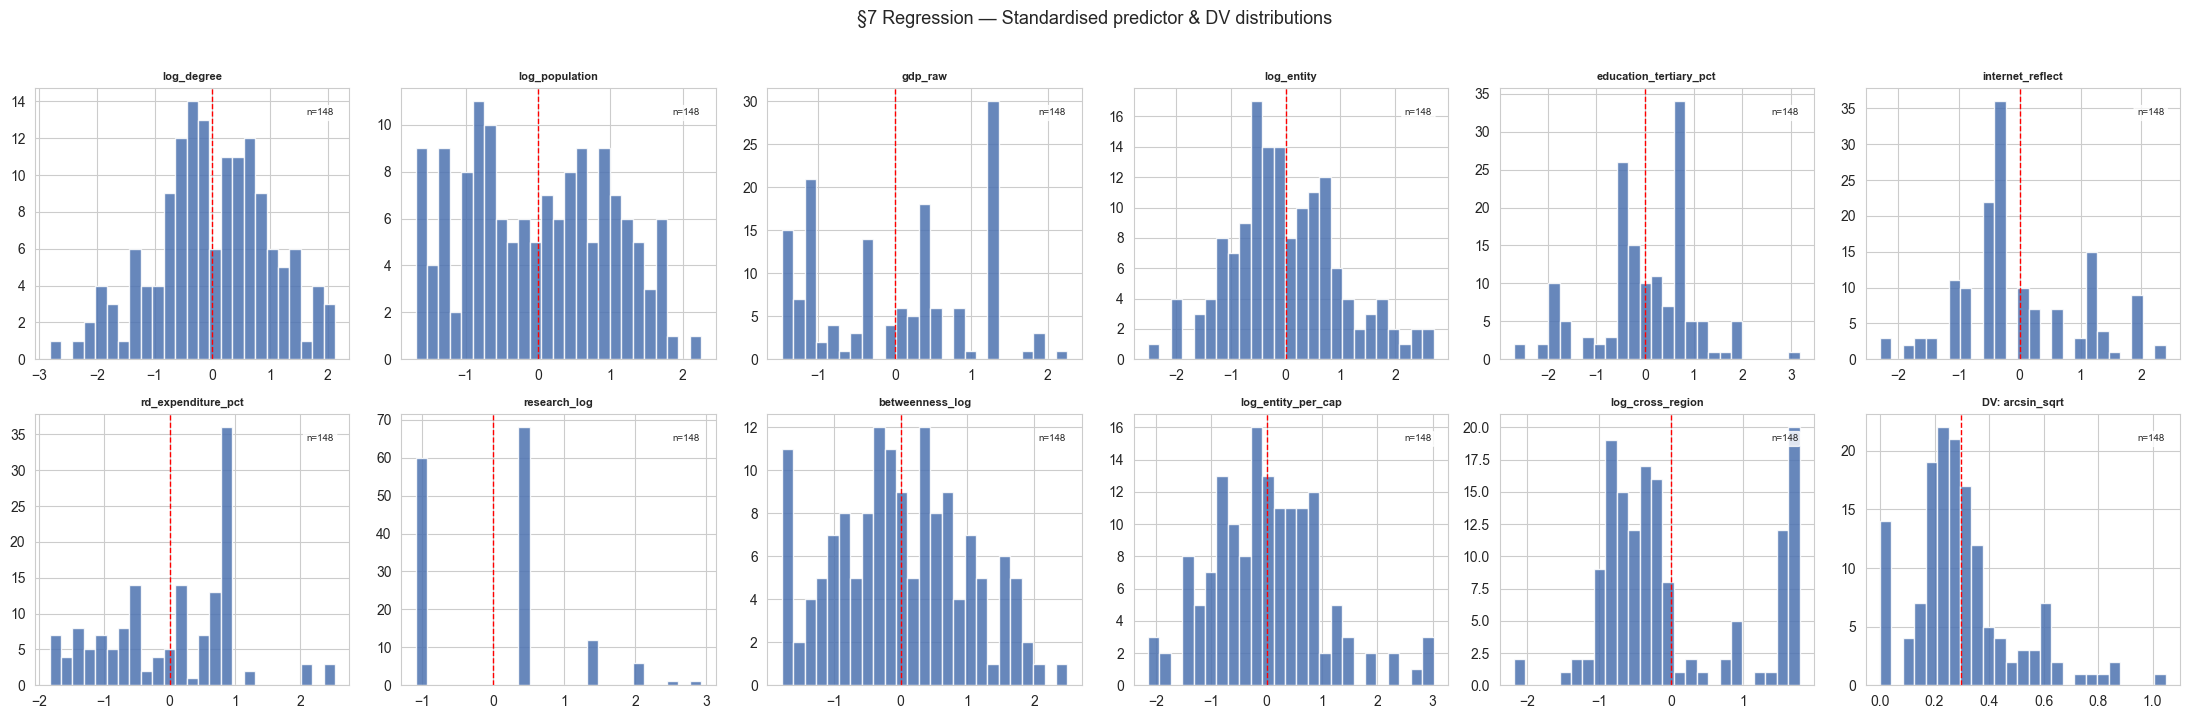

City-Project observations: 39158
is_originator: {0: 30653, 1: 8505}


In [15]:
df_city = build_city_covariates(city_attr)

# Compute city-level average IEI via shared helper
_adp = add_iei_columns(
    adoption[['city', 'project_id', 'city_first_adoption_month',
              'global_origin_month', 'lag']]
)
iei_city = (
    _adp[(_adp['lag'] > 0) & (_adp['interval'] >= 0)]
    .groupby('city')['interval'].mean()
    .rename('avg_iei')
)
df_city = df_city.drop(columns=['avg_iei'], errors='ignore')
df_city = df_city.merge(iei_city.reset_index(), on='city', how='left')
df_city['log_avg_iei'] = np.log1p(df_city['avg_iei'])

print(f'City-level observations: {len(df_city)}')
print(f'\noriginator_share:   mean={df_city["originator_share"].mean():.4f}, '
      f'std={df_city["originator_share"].std():.4f}')
print(f'log_adoption:       mean={df_city["log_adoption"].mean():.2f}, '
      f'std={df_city["log_adoption"].std():.2f}')
n_valid_iei = df_city['log_avg_iei'].notna().sum()
print(f'avg_iei (non-orig):  mean={df_city["avg_iei"].mean():.2f}, '
      f'std={df_city["avg_iei"].std():.2f}, n={df_city["log_avg_iei"].notna().sum()}')

# regression design matrix
df_a = df_city.copy()

df_a['gdp_raw']            = df_a['gdp_per_capita']
df_a['internet_reflect']   = np.log1p(100 - df_a['internet_users_pct'])
df_a['research_log']       = np.log1p(df_a['research_capacity'])
df_a['betweenness_log']    = np.log1p(df_a['betweenness'] * 10000)
df_a['originator_share_t'] = np.arcsin(np.sqrt(df_a['originator_share']))

df_a['log_entity_per_cap'] = np.log1p(df_a['entity_count'] / df_a['population_million'])
df_a['log_cross_region']   = np.log1p(df_a['cross_region_ratio_calc'])

A_FEATURES_RAW = {
    'log_degree':             'log_degree',
    'log_population':         'log_population',
    'gdp_raw':                'gdp_raw',
    'log_entity':             'log_entity',
    'education_tertiary_pct': 'education_tertiary_pct',
    'internet_reflect':       'internet_reflect',
    'rd_expenditure_pct':     'rd_expenditure_pct',
    'research_log':           'research_log',
    'betweenness_log':        'betweenness_log',
    'log_entity_per_cap':     'log_entity_per_cap',
    'log_cross_region':       'log_cross_region',
}
a_cols = list(A_FEATURES_RAW.values())
a_z    = [c + '_az' for c in a_cols]

for raw, az in zip(a_cols, a_z):
    df_a[az] = StandardScaler().fit_transform(df_a[[raw]])

df_a_valid = df_a.dropna(subset=a_z + ['originator_share_t'])
df_a_clean = df_a_valid.copy()

# Feature table for Linear models (11 IVs — CITY_IV_MAIN_11)
feature_table = pd.DataFrame({
    'Variable': CITY_IV_MAIN_11,
    'Description': [
        'log1p(weighted degree centrality)',
        'log1p(population in millions)',
        'GDP per capita (raw USD, symmetric skew=0.07)',
        'log1p(active developer/entity count)',
        'Tertiary education attainment (%)',
        'Reflect-log: log1p(100 − internet_users_pct)',
        'R&D expenditure (% of GDP)',
        'log1p(research_capacity)',
        'log1p(betweenness × 10 000)',
        'log1p(entity_count / population_million)',
        'log1p(cross_region_ratio_calc)',
    ],
    'Type': [
        'Network', 'Socio-economic', 'Socio-economic', 'Network',
        'Human capital', 'Infrastructure', 'Innovation input',
        'Innovation input', 'Network',
        'Network', 'Network',
    ],
})

dv_table = pd.DataFrame({
    'Variable': ['originator_share'],
    'Description': [
        'Origination / Adoption — arcsin-sqrt transformed',
    ],
    'Model': ['City Innovation Regression'],
})

print('=' * 80)
print('REGRESSION VARIABLE DICTIONARY')
print('=' * 80)
print(f'\n▸ Independent Variables (IVs) — {len(CITY_IV_MAIN_11)} city-level predictors (CITY_IV_MAIN_11):')
display(feature_table)
print(f'\n▸ Dependent Variables (DVs):')
display(dv_table)
print(f'\nCity-level sample: n = {len(df_city)} cities with adoption_count > 0')

fig_iv, axes_iv = plt.subplots(2, 6, figsize=(22, 7))
axes_iv = axes_iv.flatten()
plot_cols   = a_z + ['originator_share_t']
plot_labels = [c.replace('_az', '') for c in a_z] + ['DV: arcsin_sqrt']

for idx, (col, label) in enumerate(zip(plot_cols, plot_labels)):
    ax = axes_iv[idx]
    d = df_a_valid[col].dropna()
    ax.hist(d, bins=25, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax.axvline(d.mean(), color='red', ls='--', lw=1)
    ax.set_title(label, fontsize=8, fontweight='bold')
    ax.annotate(f'n={len(d)}', xy=(0.95, 0.90),
                xycoords='axes fraction', ha='right', fontsize=7,
                bbox=dict(boxstyle='round', fc='white', alpha=0.8))
for ax in axes_iv[len(plot_cols):]:
    ax.set_visible(False)
fig_iv.suptitle(
    chr(167) + '7 Regression \u2014 Standardised predictor & DV distributions',
    fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Merge city features onto adoption events
merge_cols = ['city'] + CITY_IV_RAW_11 + ['region']
merge_cols = list(dict.fromkeys(merge_cols))  # deduplicate while preserving order

df_cp = adoption.merge(df_city[merge_cols], on='city', how='inner')
print(f'City-Project observations: {len(df_cp)}')
print(f'is_originator: {df_cp["is_originator"].value_counts().to_dict()}')

#### 4.3.2 Linear Regression
This section addresses *which city characteristics are associated with innovation-oriented roles and adoption breadth.* OLS regresses `log1p(origination_count)` on 11 z-standardised city-level predictors (structural, economic, network). HC3 robust standard errors guard against heteroskedasticity. Standardised coefficients enable direct magnitude comparison across predictor dimensions.


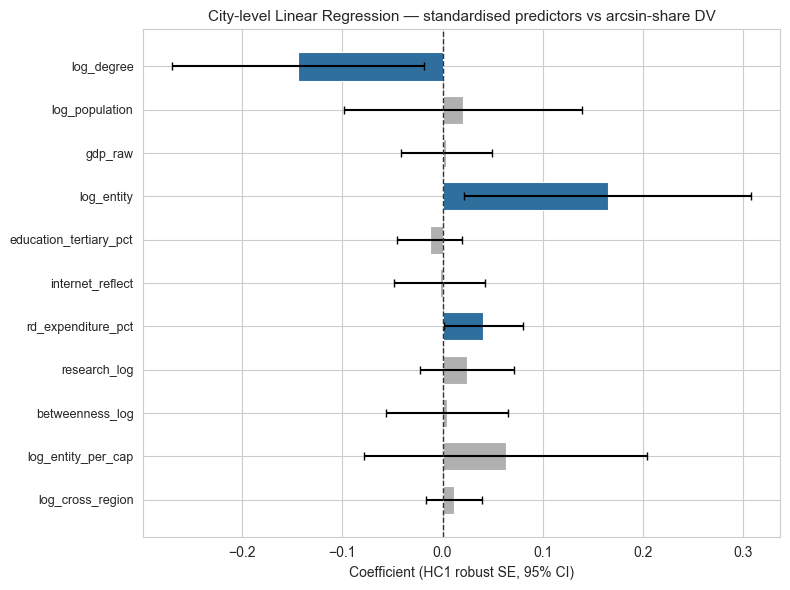

                            OLS Regression Results                            
Dep. Variable:     originator_share_t   R-squared:                       0.301
Model:                            OLS   Adj. R-squared:                  0.245
Method:                 Least Squares   F-statistic:                     7.020
Date:                Tue, 05 May 2026   Prob (F-statistic):           2.46e-09
Time:                        04:07:37   Log-Likelihood:                 64.626
No. Observations:                 148   AIC:                            -105.3
Df Residuals:                     136   BIC:                            -69.29
Df Model:                          11                                         
Covariance Type:                  HC1                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [16]:
# CITY-LEVEL INNOVATION INTENSITY lINEAR REGRESSION

formula_a = f'originator_share_t ~ {" + ".join(a_z)}'
model_a   = smf.ols(formula_a, data=df_a_clean).fit(cov_type='HC1')

params_a = model_a.params[1:]
pvals_a  = model_a.pvalues[1:]
sig_a    = pvals_a < 0.05

sig_vars_a = [v for v in a_z if pvals_a[v] < 0.1]
if 2 <= len(sig_vars_a) < len(a_z):
    formula_a_red = f'originator_share_t ~ {" + ".join(sig_vars_a)}'
    model_a_red   = smf.ols(formula_a_red, data=df_a_clean).fit(cov_type='HC1')

from sklearn.model_selection import KFold
kf = KFold(5, shuffle=True, random_state=42)
X_a_cv   = df_a_clean[a_z].values
y_a_t    = df_a_clean['originator_share_t'].values
y_a_orig = df_a_clean['originator_share'].values
cv_r2_t, cv_r2_o = [], []
for tr, te in kf.split(X_a_cv):
    from sklearn.linear_model import LinearRegression as LR
    m = LR().fit(X_a_cv[tr], y_a_t[tr])
    pred_t = m.predict(X_a_cv[te])
    cv_r2_t.append(r2_score(y_a_t[te], pred_t))
    cv_r2_o.append(r2_score(y_a_orig[te], np.sin(pred_t)**2))

# Model visualisation
coef_idx = model_a.params.index.drop('Intercept', errors='ignore')
coefs = model_a.params.loc[coef_idx]
ci_ov = model_a.conf_int(alpha=0.05).loc[coef_idx]
xerr_low = coefs.values - ci_ov.iloc[:, 0].values
xerr_hi  = ci_ov.iloc[:, 1].values - coefs.values
xerr     = np.vstack([xerr_low, xerr_hi])

fig_coef, axc = plt.subplots(figsize=(8, max(6.0, 0.45 * len(coefs))))
y_pos = np.arange(len(coefs))[::-1]
coef_labels = [str(v).replace('_az', '') for v in coefs.index]
p_col = model_a.pvalues.loc[coef_idx].values
colors = np.where(p_col < 0.05, '#2E6F9E', '#B0B0B0')
axc.barh(y_pos, coefs.values, xerr=xerr, height=0.65, color=colors,
         edgecolor='white', linewidth=0.8, capsize=3)
axc.axvline(0, color='#333333', lw=1, ls='--')
axc.set_yticks(y_pos)
axc.set_yticklabels(coef_labels, fontsize=9)
axc.set_xlabel('Coefficient (HC1 robust SE, 95% CI)', fontsize=10)
axc.set_title('City-level Linear Regression — standardised predictors vs arcsin-share DV',
              fontsize=11)
plt.tight_layout()
plt.show()

_s = model_a.summary()
for t in _s.tables:
    print(t)

Cities with larger developer ecosystems (β = +0.16) and higher R&D spending (β = +0.04) are more likely to originate innovations, while highly connected cities tend toward adoption (β = −0.14). GDP, population, and education are insignificant — innovation capacity matters more than city scale.


### 4.4 XGBoost for Adoption Speed Analysis

 #### 4.4.1 Feature Construction

**DV:** `log1p(IEI)` — months between consecutive city adoptions of the same project (event-level). 

**IVs:** 11 standardised city covariates (same as above linear model) plus project-level controls (`log_stars`, `popularity_pctile`, `project_age_months`).


IEI events (lag > 0): 25297
  interval = 0 (same month as prev city): 7966
  interval > 0: 16461
Interval (raw):  mean=2.73, median=1, std=6.60
Interval (log):  mean=0.90, std=0.91
Input features: 11 city-level IVs (same as §4.3 OLS) + 8 supplementary IVs = 19 total


,eigenvector_centrality,origination_rate,log_proj_pop,proj_origin_idx,log_stars,log_forks,popularity_pctile,fork_star_ratio
count,25297.0000,25297.0000,25297.0000,25297.0000,25297.0000,25297.0000,25297.0000,25297.0000
mean,0.1365,0.2652,2.4412,22.8659,8.0003,6.0015,0.7566,0.2017
std,0.0953,0.2970,0.9281,11.9033,1.8084,1.6978,0.2701,0.4382
min,0.0014,0.0000,0.6931,0.0000,1.3863,1.7918,0.0016,0.0016
25%,0.0561,0.0817,1.7918,14.0000,6.6359,4.6728,0.6291,0.0870
50%,0.1142,0.1433,2.3979,21.0000,7.9025,5.8051,0.8682,0.1189
75%,0.2306,0.3529,3.1781,33.0000,9.3511,7.1747,0.9669,0.1733
max,0.3188,2.2579,4.4067,47.0000,12.1191,10.9998,1.0000,20.4444


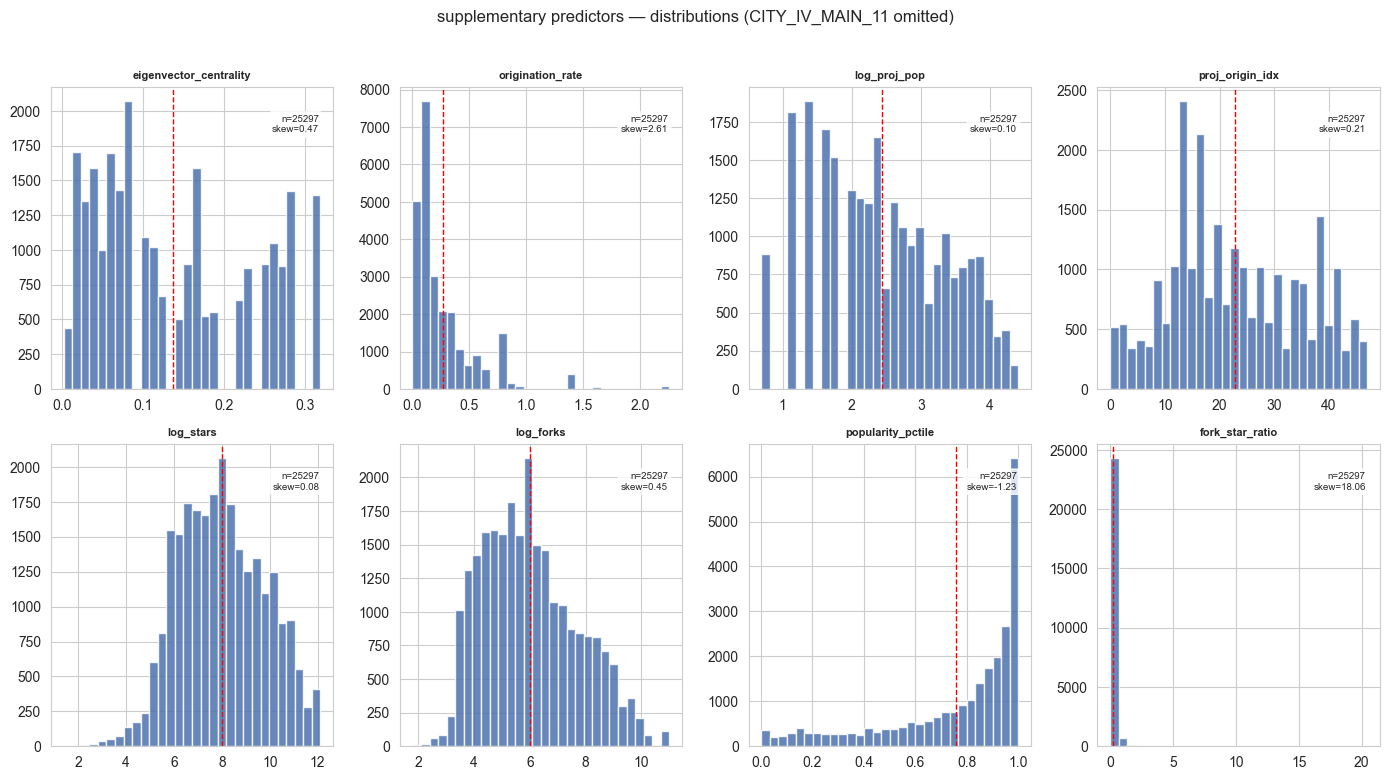

In [17]:
# Feature construction → event-level IEI table
_extra_merge = city_attr[['city'] + EXTRA_CITY].drop_duplicates(subset='city', keep='first')
df_cp = df_cp.merge(_extra_merge, on='city', how='left')

_proj_agg = adoption.groupby('project_id').agg(
    proj_n_cities=('city', 'nunique')).reset_index()
df_cp = df_cp.merge(_proj_agg, on='project_id', how='left')
df_cp['log_proj_pop']    = np.log1p(df_cp['proj_n_cities'])
df_cp['proj_origin_idx'] = df_cp['global_origin_month'].apply(_ym_to_months)

_prom = prom.copy()
_prom['metric_stars']     = pd.to_numeric(_prom['metric_stars'], errors='coerce')
_prom['metric_forks']     = pd.to_numeric(_prom['metric_forks'], errors='coerce')
_prom['metric_downloads'] = pd.to_numeric(_prom['metric_downloads'], errors='coerce')
_gh = _prom[_prom['platform'] == 'GitHub'].copy()
_hf = _prom[_prom['platform'] == 'HuggingFace'].copy()
_gh['popularity_pctile'] = _gh['metric_stars'].rank(pct=True)
_hf['popularity_pctile'] = _hf['metric_downloads'].rank(pct=True)
_gh['fork_star_ratio']   = _gh['metric_forks'] / _gh['metric_stars'].replace(0, np.nan)
_proj_feats = pd.concat([
    _gh[['full_id', 'metric_stars', 'metric_forks', 'popularity_pctile', 'fork_star_ratio']],
    _hf[['full_id', 'popularity_pctile']],
]).rename(columns={'full_id': 'project_id'})
_proj_feats['log_stars'] = np.log1p(_proj_feats['metric_stars'])
_proj_feats['log_forks'] = np.log1p(_proj_feats['metric_forks'])
df_cp = df_cp.merge(
    _proj_feats[['project_id', 'log_stars', 'log_forks',
                 'popularity_pctile', 'fork_star_ratio']],
    on='project_id', how='left')

df_cp = add_iei_columns(df_cp, origin_idx_col='proj_origin_idx')

df_iei = df_cp[df_cp['lag'] > 0].copy()
for c in PROJ_ATTR_COLS:
    df_iei[c] = df_iei[c].fillna(df_iei[c].median())

# CITY_IV_MAIN_11 transforms (same as OLS)
df_iei['gdp_raw']            = np.exp(df_iei['log_gdp'])
df_iei['internet_reflect']   = np.log1p(100 - df_iei['internet_users_pct'])
df_iei['research_log']       = np.log1p(df_iei['research_capacity'])
df_iei['betweenness_log']    = np.log1p(df_iei['betweenness'] * 10000)
df_iei['log_entity_per_cap'] = np.log1p(df_iei['entity_count'] / df_iei['population_million'])
df_iei['log_cross_region']   = np.log1p(df_iei['cross_region_ratio_calc'])

SEC8_CITY_IV_SKEWFIX = CITY_IV_MAIN_11
SEC8_IEI_SUPP_COLS = EXTRA_CITY + PROJ_AGG_COLS + PROJ_ATTR_COLS
SEC8_IEI_FEATURE_COLS = SEC8_CITY_IV_SKEWFIX + SEC8_IEI_SUPP_COLS

df_iei = df_iei.dropna(subset=SEC8_IEI_FEATURE_COLS).copy()

y_iei_raw = df_iei['interval'].values.astype(float)
y_iei = np.log1p(np.clip(y_iei_raw, 0, None))

print(f'IEI events (lag > 0): {len(df_iei)}')
print(f'  interval = 0 (same month as prev city): {(y_iei_raw == 0).sum()}')
print(f'  interval > 0: {(y_iei_raw > 0).sum()}')
print(f'Interval (raw):  mean={y_iei_raw.mean():.2f}, median={np.median(y_iei_raw):.0f}, '
      f'std={y_iei_raw.std():.2f}')
print(f'Interval (log):  mean={y_iei.mean():.2f}, std={y_iei.std():.2f}')

X_iei = df_iei[SEC8_IEI_FEATURE_COLS].values

print(f'Input features: {len(SEC8_CITY_IV_SKEWFIX)} city-level IVs (same as §4.3 OLS) '
      f'+ {len(SEC8_IEI_SUPP_COLS)} supplementary IVs = {len(SEC8_IEI_FEATURE_COLS)} total')
display(df_iei[SEC8_IEI_SUPP_COLS].describe().round(4))

supp_n = len(SEC8_IEI_SUPP_COLS)
_ncols_fig = 4
_supp_rows = int(np.ceil(supp_n / _ncols_fig))
fig_inp, axes_inp = plt.subplots(_supp_rows, _ncols_fig, figsize=(14, 3.8 * _supp_rows))
axes_inp = np.atleast_1d(axes_inp).ravel()
for idx, col in enumerate(SEC8_IEI_SUPP_COLS):
    ax = axes_inp[idx]
    d = df_iei[col].dropna()
    ax.hist(d, bins=30, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax.axvline(d.mean(), color='red', ls='--', lw=1)
    ax.set_title(col, fontsize=8, fontweight='bold')
    ax.annotate(f'n={len(d)}\nskew={d.skew():.2f}', xy=(0.95, 0.85),
                xycoords='axes fraction', ha='right', fontsize=7,
                bbox=dict(boxstyle='round', fc='white', alpha=0.8))
for idx in range(supp_n, len(axes_inp)):
    axes_inp[idx].set_visible(False)
fig_inp.suptitle('supplementary predictors — distributions (CITY_IV_MAIN_11 omitted)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

#### 4.4.2 XGBoost Model

XGBoost addresses **RQ3** — *which city characteristics accelerate adoption?* The native feature-importance plot shows how predictive power is distributed across city-structure and project-attribute groups.

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 64 candidates, totalling 320 fits
  R²   (log-IEI): 0.3202
  RMSE (log-IEI): 0.7518
  MAE  (log-IEI): 0.5908
  CV R² (5-fold):  0.2738 ± 0.0068


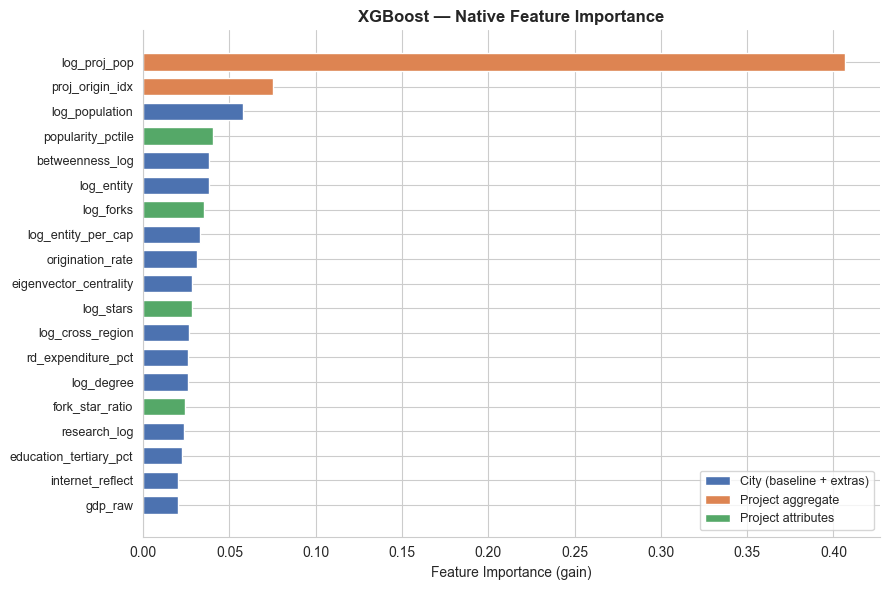

In [18]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, KFold

cv_iei = KFold(n_splits=5, shuffle=True, random_state=42)

xgb_shell = lambda: XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    tree_method='hist',
    verbosity=0,
    n_jobs=1,
)

# Stage A: stochastic exploration
param_rng = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.025, 0.04, 0.06, 0.1],
    'n_estimators': [450, 700, 950, 1200],
    'subsample': [0.65, 0.8, 0.95],
    'colsample_bytree': [0.65, 0.85, 1.0],
    'reg_lambda': [0.25, 0.75, 1.5, 5.0, 12.0],
    'gamma': [0.0, 0.05, 0.5],
    'min_child_weight': [1, 4, 8],
}

random_iei_cv = RandomizedSearchCV(
    estimator=xgb_shell(),
    param_distributions=param_rng,
    n_iter=36,
    scoring='r2',
    cv=cv_iei,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
random_iei_cv.fit(X_iei, y_iei)

# Stage B: Cartesian grid (narrow but explicit GridSearchCV API)
grid_iei_cv = GridSearchCV(
    estimator=xgb_shell(),
    param_grid={
        'max_depth': [5, 7],
        'learning_rate': [0.03, 0.05],
        'n_estimators': [700, 1000],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.75, 0.9],
        'reg_lambda': [0.5, 2.0],
        'gamma': [0.0],
        'min_child_weight': [1],
    },
    scoring='r2',
    cv=cv_iei,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
grid_iei_cv.fit(X_iei, y_iei)

pick_grid = grid_iei_cv.best_score_ >= random_iei_cv.best_score_

if pick_grid:
    winner = grid_iei_cv
    winner_name = 'GridSearchCV'
else:
    winner = random_iei_cv
    winner_name = 'RandomizedSearchCV'

xgb_iei = winner.best_estimator_
winner_idx = winner.best_index_

cv_r2_iei = np.array([
    winner.cv_results_[f'split{k}_test_score'][winner_idx]
    for k in range(cv_iei.get_n_splits())
])



# Full-sample in-sample diagnostics (best grid model, informational)
y_pred_iei = xgb_iei.predict(X_iei)

print(f'  R²   (log-IEI): {r2_score(y_iei, y_pred_iei):.4f}')
print(f'  RMSE (log-IEI): {np.sqrt(mean_squared_error(y_iei, y_pred_iei)):.4f}')
print(f'  MAE  (log-IEI): {mean_absolute_error(y_iei, y_pred_iei):.4f}')
print(f'  CV R² (5-fold):  {cv_r2_iei.mean():.4f} ± {cv_r2_iei.std():.4f}')

# Native XGBoost feature importance (gain)
importances = xgb_iei.feature_importances_
order_fi = np.argsort(importances)

fig3, ax3 = plt.subplots(figsize=(9, 6))
city_set = set(SEC8_CITY_IV_SKEWFIX + EXTRA_CITY)
colors3 = []
for idx in order_fi:
    c = SEC8_IEI_FEATURE_COLS[idx]
    if c in city_set:
        colors3.append('#4C72B0')
    elif c in PROJ_AGG_COLS:
        colors3.append('#DD8452')
    else:
        colors3.append('#55A868')

ax3.barh(range(len(order_fi)), importances[order_fi],
         color=colors3, height=0.7)
ax3.set_yticks(range(len(order_fi)))
ax3.set_yticklabels([SEC8_IEI_FEATURE_COLS[i] for i in order_fi], fontsize=9)
ax3.set_xlabel('Feature Importance (gain)', fontsize=10)
ax3.set_title('XGBoost — Native Feature Importance',
              fontsize=12, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='City (baseline + extras)'),
    Patch(facecolor='#DD8452', label='Project aggregate'),
    Patch(facecolor='#55A868', label='Project attributes'),
]
ax3.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

#### 4.4.3 SHAP Feature Importance

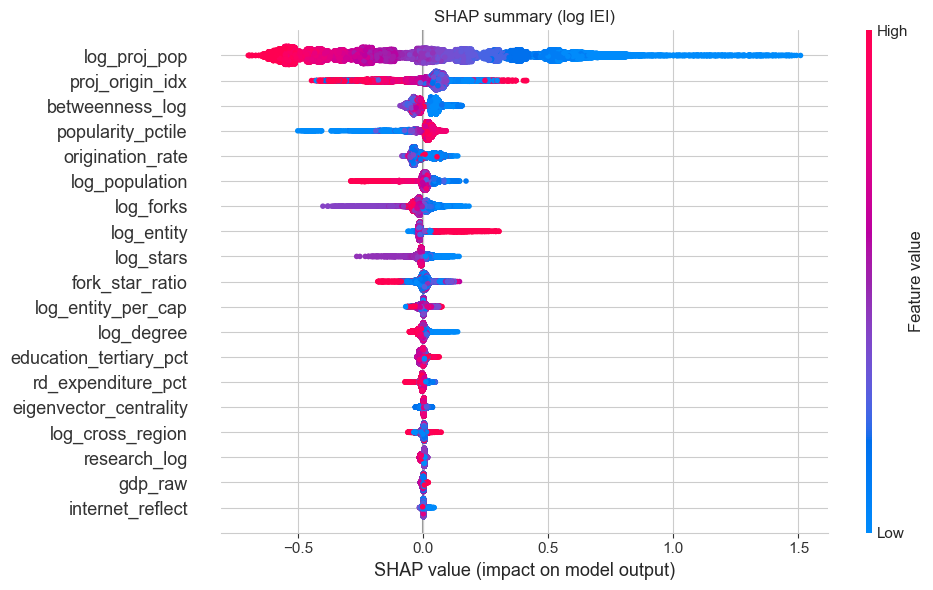

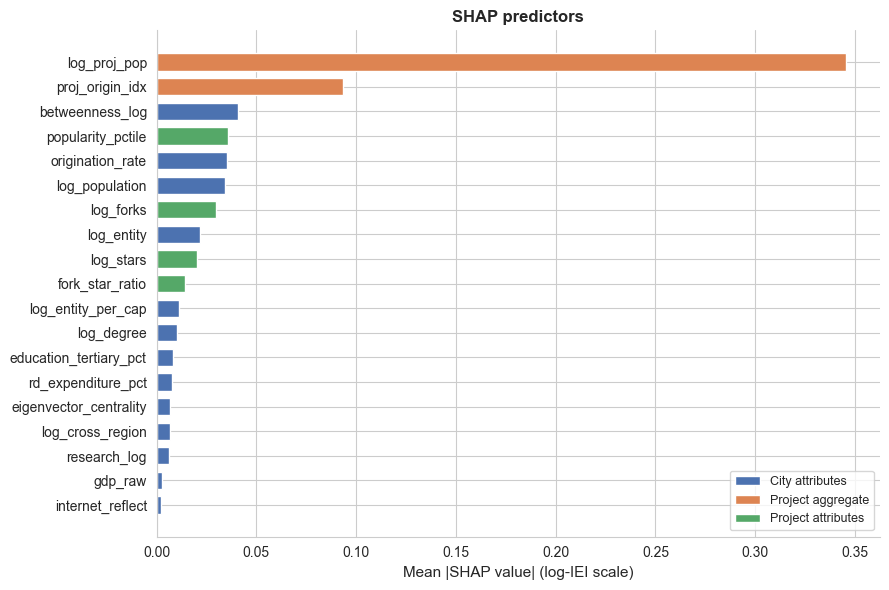

In [19]:
# SHAP + executive performance summary
explainer_iei = shap.TreeExplainer(xgb_iei)
shap_values_iei = explainer_iei.shap_values(X_iei)
mean_shap_iei = np.abs(shap_values_iei).mean(0)

fig_sum, axsum = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values_iei, X_iei, feature_names=SEC8_IEI_FEATURE_COLS,
                  show=False, plot_size=None)
plt.title('SHAP summary (log IEI)', fontsize=12)
plt.tight_layout()
plt.show()

# Mean |SHAP| — horizontal bar chart
fig_bar, ax = plt.subplots(figsize=(9, 6))
order = np.argsort(mean_shap_iei)
cols_sorted = [SEC8_IEI_FEATURE_COLS[i] for i in order]
vals_sorted = mean_shap_iei[order]

city_set = set(SEC8_CITY_IV_SKEWFIX + EXTRA_CITY)
colors = []
for c in cols_sorted:
    if c in city_set:
        colors.append('#4C72B0')
    elif c in PROJ_AGG_COLS:
        colors.append('#DD8452')
    else:
        colors.append('#55A868')

ax.barh(range(len(cols_sorted)), vals_sorted, color=colors, height=0.7)
ax.set_yticks(range(len(cols_sorted)))
ax.set_yticklabels(cols_sorted, fontsize=10)
ax.set_xlabel('Mean |SHAP value| (log-IEI scale)', fontsize=11)
ax.set_title(f'SHAP predictors',
             fontsize=12, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='City attributes'),
    Patch(facecolor='#DD8452', label='Project aggregate'),
    Patch(facecolor='#55A868', label='Project attributes'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

The SHAP beeswarm ranks features by mean |SHAP|. Project-level variables (`log_proj_pop`, `proj_origin_idx`) dominate — adoption pace is primarily project-driven. Among city covariates, **betweenness centrality** and **population** rank highest, indicating that cities occupying brokerage positions in the collaboration network adopt faster — consistent with structural-hole theory. Developer ecosystem size  and degree centrality also contribute meaningfully. However, traditional socio-economic indicators show minimal predictive power: education, R&D expenditure, GDP and internet penetration all rank at the bottom, suggesting that a city's network position and scale matter far more for adoption speed than its conventional economic or human-capital endowments.


### 4.5 Linear Regression with Technology-Type Interactions

Linear Regression model with city × technology_type interactions tests whether city-structure associations with adoption pace vary across seven technology families.


#### 4.5.1 Feature Construction


city_attr: (148, 38),  adoption: (39158, 6),  edges: (9636, 4),  prom: (23481, 15)
Loaded tech-type labels: 23481 rows

── All prominent projects ──
tech_type
LLM-Foundation     5853
LLM-Application    5555
Vision             3424
NLP-Traditional    2321
Agent              2238
Multimodal         1919
Speech             1215
Unclassified        681
Other               275

— Regression design feature overview


,Component,Count,Note
0,z-standardised city linear terms (`CITY_IV_MAI...,11,Aligned with ; variable names consistent with ...
1,Tech-type dummies (relative to LLM-Application),6,Collinear reference group omitted
2,City × type interactions z_i × T_k,66,= 11 × 6 = 66; individual coefficients not pri...
3,Project-level control variables,6,Definitions and distributions given below


— 6 project-level control variables (definitions + descriptive stats)


,Variable,Description,mean,std,min,25%,50%,75%,max
0,log_proj_pop,log1p(cities entered by this prominent project...,2.4455,0.9320,0.6931,1.7918,2.3979,3.2189,4.4067
1,proj_origin_idx,Global ordinal index of first-release month: p...,23.0290,11.8609,0.0000,14.0000,21.0000,33.0000,47.0000
2,log_stars,log1p(GitHub Stars); non-GitHub projects imput...,8.0203,1.8036,1.3863,6.6631,7.9036,9.3557,12.1191
3,log_forks,log1p(GitHub Forks); non-GitHub projects imput...,6.0166,1.7042,1.7918,4.6821,5.7961,7.1846,10.9998
4,popularity_pctile,Within-platform Stars or Downloads sample quan...,0.7608,0.2669,0.0016,0.6393,0.8696,0.9672,1.0000
5,fork_star_ratio,Forks / Stars (GitHub); other platforms NaN im...,0.1972,0.3842,0.0016,0.0868,0.1171,0.1730,15.6667


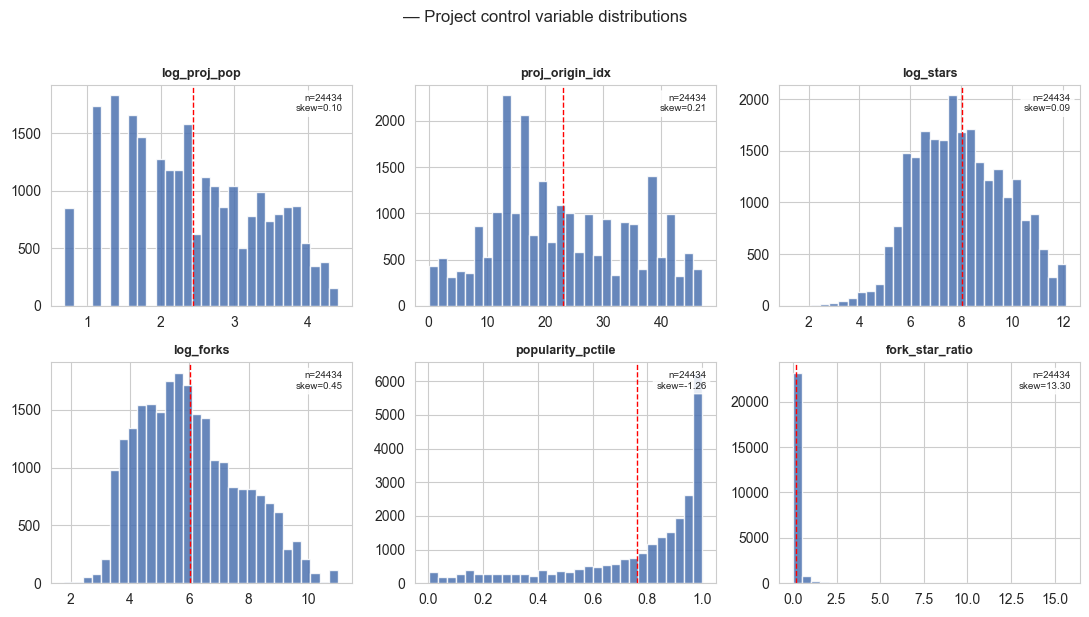

In [20]:
city_attr   = pd.read_csv(DATA_OUTPUT + 'city_attributes.csv')
adoption    = pd.read_csv(DATA_OUTPUT + 'city_project_adoption_events.csv')
edges_agg   = pd.read_csv(DATA_OUTPUT + 'city_collaboration_edges.csv')
edges_month = pd.read_csv(DATA_OUTPUT + 'city_collaboration_edges_monthly.csv')
prom = pd.read_csv(DATA_PROCESSED + 'prominent_projects_master.csv', dtype=str)

prom_projects  = prom
adopt_events   = adoption
collab_edges   = edges_agg
city_attr_dedup = city_attr.drop_duplicates(subset='city', keep='first')

print(f"city_attr: {city_attr.shape},  adoption: {adoption.shape},  "
      f"edges: {edges_agg.shape},  prom: {prom.shape}")

# read pre-classified tech-type labels
tech_type_df = pd.read_csv(DATA_PROCESSED + 'project_tech_type.csv', dtype=str)
print(f'Loaded tech-type labels: {len(tech_type_df)} rows')

type_by_full = tech_type_df.set_index('full_id')['tech_type'].to_dict()
type_by_pid  = tech_type_df.set_index('project_id')['tech_type'].to_dict()
prom['tech_type'] = (prom['full_id'].map(type_by_full)
                     .fillna(prom['project_id'].map(type_by_pid)))

VALID_TYPES = ['LLM-Application', 'LLM-Foundation', 'NLP-Traditional',
               'Vision', 'Agent', 'Multimodal', 'Speech']

print('\n── All prominent projects ──')
print(prom['tech_type'].value_counts().to_string())

_merge_city = ['city'] + CITY_IV_RAW_11
_merge_city = list(dict.fromkeys(_merge_city))
df_city = build_city_covariates(city_attr)

df = adoption.merge(df_city[_merge_city], on='city', how='inner')
df = df.dropna(subset=CITY_IV_RAW_11[:9]).reset_index(drop=True)

df['tech_type'] = (df['project_id'].map(type_by_full)
                   .fillna(df['project_id'].map(type_by_pid)))
df = df[df['tech_type'].isin(VALID_TYPES)].reset_index(drop=True)

df = add_iei_columns(df)

proj_stats = adoption.groupby('project_id').agg(
    proj_n_cities=('city', 'nunique')).reset_index()
df = df.merge(proj_stats, on='project_id', how='left')
df['log_proj_pop'] = np.log1p(df['proj_n_cities'])
df['proj_origin_idx'] = df['global_origin_month'].apply(_ym_to_months)

prom['metric_stars'] = pd.to_numeric(prom['metric_stars'], errors='coerce')
prom['metric_forks'] = pd.to_numeric(prom['metric_forks'], errors='coerce')
prom['metric_downloads'] = pd.to_numeric(prom['metric_downloads'], errors='coerce')
gh = prom[prom['platform'] == 'GitHub'].copy()
hf = prom[prom['platform'] == 'HuggingFace'].copy()
gh['popularity_pctile'] = gh['metric_stars'].rank(pct=True)
hf['popularity_pctile'] = hf['metric_downloads'].rank(pct=True)
gh['fork_star_ratio'] = gh['metric_forks'] / gh['metric_stars'].replace(0, np.nan)
proj_feats = pd.concat([
    gh[['full_id', 'metric_stars', 'metric_forks', 'popularity_pctile', 'fork_star_ratio']],
    hf[['full_id', 'popularity_pctile']],
]).rename(columns={'full_id': 'project_id'})
proj_feats['log_stars'] = np.log1p(proj_feats['metric_stars'])
proj_feats['log_forks'] = np.log1p(proj_feats['metric_forks'])
df = df.merge(
    proj_feats[['project_id', 'log_stars', 'log_forks',
                'popularity_pctile', 'fork_star_ratio']],
    on='project_id', how='left')

PROJ_CTRL = ['log_proj_pop', 'proj_origin_idx',
             'log_stars', 'log_forks', 'popularity_pctile', 'fork_star_ratio']
for c in PROJ_CTRL:
    df[c] = df[c].fillna(df[c].median())

df = df[df['lag'] > 0].copy()
df['log_interval'] = np.log1p(np.clip(df['interval'], 0, None))

df['gdp_raw']            = np.exp(df['log_gdp'])
df['internet_reflect']   = np.log1p(100 - df['internet_users_pct'])
df['research_log']       = np.log1p(df['research_capacity'])
df['betweenness_log']    = np.log1p(df['betweenness'] * 10000)
df['log_entity_per_cap'] = np.log1p(df['entity_count'] / df['population_million'])
df['log_cross_region']   = np.log1p(df['cross_region_ratio_calc'])

IV_COLS = CITY_IV_MAIN_11

for c in IV_COLS:
    mu, sd = df[c].mean(), df[c].std()
    df[f'z_{c}'] = (df[c] - mu) / sd if sd > 0 else 0.0

Z_COLS = [f'z_{c}' for c in IV_COLS]
N_TECH_DUMMIES = len(VALID_TYPES) - 1  # vs LLM-Application reference

# build formula
df['tech'] = pd.Categorical(
    df['tech_type'],
    categories=['LLM-Application', 'LLM-Foundation', 'NLP-Traditional',
                'Vision', 'Agent', 'Multimodal', 'Speech'])

tech_dummies = pd.get_dummies(df['tech'], prefix='T', drop_first=True,
                              dtype=float)
tech_dummies.columns = [c.replace('-', '_').replace(' ', '_')
                        for c in tech_dummies.columns]
df = pd.concat([df, tech_dummies], axis=1)

T_COLS = list(tech_dummies.columns)  # 6 dummies

interaction_terms = []
for z in Z_COLS:
    for t in T_COLS:
        col = f'{z}_x_{t}'
        df[col] = df[z] * df[t]
        interaction_terms.append(col)

X_COLS = Z_COLS + T_COLS + interaction_terms + PROJ_CTRL

# Regression feature overview (interaction block not enumerated row-by-row)
n_ix = len(IV_COLS) * N_TECH_DUMMIES
feat_overview = pd.DataFrame([
    {'Component': 'z-standardised city linear terms (`CITY_IV_MAIN_11`)', 'Count': len(Z_COLS),
     'Note': 'Aligned with ; variable names consistent with dictionary'},
    {'Component': 'Tech-type dummies (relative to LLM-Application)', 'Count': N_TECH_DUMMIES,
     'Note': 'Collinear reference group omitted'},
    {'Component': 'City × type interactions z_i × T_k', 'Count': n_ix,
     'Note': f'= {len(Z_COLS)} × {N_TECH_DUMMIES} = {n_ix}; individual coefficients not printed here'},
    {'Component': 'Project-level control variables', 'Count': len(PROJ_CTRL),
     'Note': 'Definitions and distributions given below'},
])
feat_overview['Count'] = feat_overview['Count'].astype(int)
print('\n— Regression design feature overview')
display(feat_overview)

proj_ctrl_meta = pd.DataFrame({
    'Variable': PROJ_CTRL,
    'Description': [
        'log1p(cities entered by this prominent project): spatial diffusion breadth',
        'Global ordinal index of first-release month: project market entry timing',
        'log1p(GitHub Stars); non-GitHub projects imputed with median',
        'log1p(GitHub Forks); non-GitHub projects imputed with median',
        'Within-platform Stars or Downloads sample quantile rank [0,1]',
        'Forks / Stars (GitHub); other platforms NaN imputed with median',
    ],
})
desc_pc = df[PROJ_CTRL].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(4)
proj_table = proj_ctrl_meta.set_index('Variable').join(desc_pc)
proj_table.index.name = 'Variable'
print('— 6 project-level control variables (definitions + descriptive stats)')
display(proj_table.reset_index())

fig_pc, axes_pc = plt.subplots(2, 3, figsize=(11, 6))
axes_pc = axes_pc.flatten()
for idx, col in enumerate(PROJ_CTRL):
    ax = axes_pc[idx]
    d = df[col].dropna()
    ax.hist(d, bins=30, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax.axvline(d.mean(), color='red', ls='--', lw=1)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.annotate(f'n={len(d)}\nskew={d.skew():.2f}', xy=(0.97, 0.88),
                xycoords='axes fraction', ha='right', fontsize=7,
                bbox=dict(boxstyle='round', fc='white', alpha=0.85))
fig_pc.suptitle('— Project control variable distributions', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


#### 4.5.2 Regression Model


The model regresses `log1p(IEI)` on 11 standardised city covariates, 6 technology dummies, and 66 city × technology interactions. Significant interactions indicate that a city trait's association with adoption speed differs by project type.


In [21]:
Y = df['log_interval']
X = sm.add_constant(df[X_COLS].astype(float))

modelC = sm.OLS(Y, X).fit()

print(f'interaction Linear Regression — R² = {modelC.rsquared:.4f},  Adj R² = {modelC.rsquared_adj:.4f}')
print(f'F-stat = {modelC.fvalue:.2f},  p = {modelC.f_pvalue:.2e}')
print(f'Observations = {int(modelC.nobs)},  df_resid = {int(modelC.df_resid)}')
print()

# Joint F-test: all interaction terms jointly zero
r_matrix = np.zeros((len(interaction_terms), X.shape[1]))
for i, col in enumerate(interaction_terms):
    r_matrix[i, list(X.columns).index(col)] = 1.0

interaction Linear Regression — R² = 0.2163,  Adj R² = 0.2135
F-stat = 75.50,  p = 0.00e+00
Observations = 24434,  df_resid = 24344



#### 4.5.3 Visualisation and Interpretation


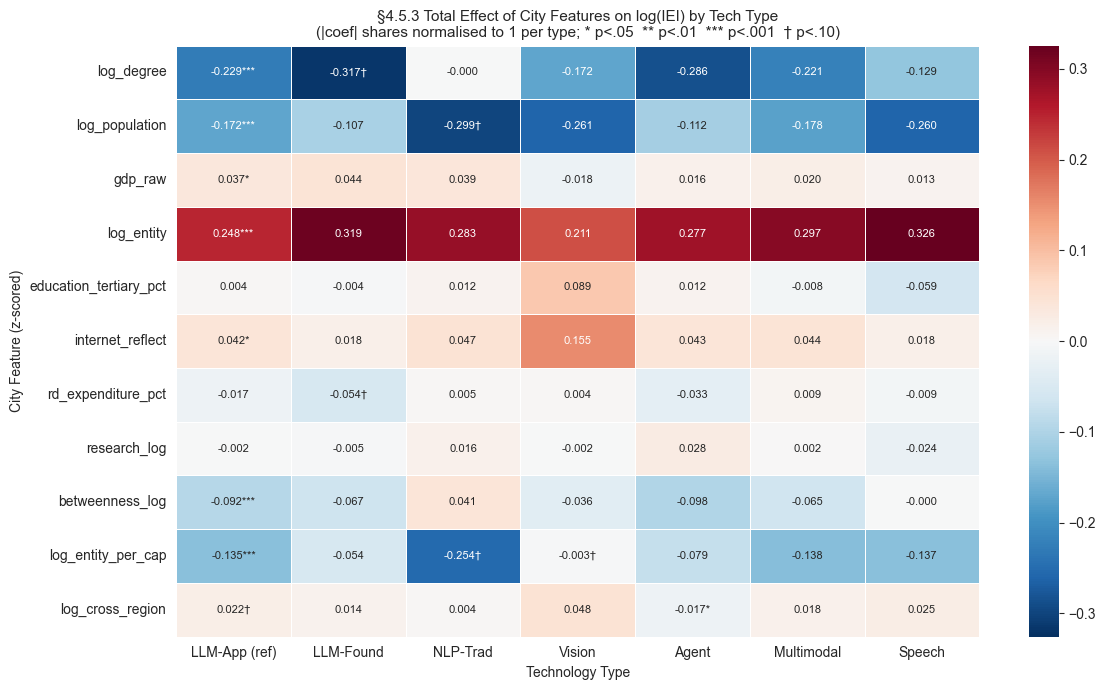

In [22]:
# Build total-effect matrix: main_effect + interaction
tech_labels = ['LLM-App (ref)', 'LLM-Found', 'NLP-Trad',
               'Vision', 'Agent', 'Multimodal', 'Speech']

effect_matrix = pd.DataFrame(index=IV_COLS, columns=tech_labels,
                             dtype=float)
pval_matrix   = pd.DataFrame(index=IV_COLS, columns=tech_labels,
                             dtype=float)

for iv in IV_COLS:
    z = f'z_{iv}'
    main_b = modelC.params.get(z, 0.0)
    main_p = modelC.pvalues.get(z, 1.0)
    effect_matrix.loc[iv, 'LLM-App (ref)'] = main_b
    pval_matrix.loc[iv, 'LLM-App (ref)']   = main_p

    for t_col, t_label in zip(T_COLS, tech_labels[1:]):
        ix_col = f'{z}_x_{t_col}'
        ix_b = modelC.params.get(ix_col, 0.0)
        ix_p = modelC.pvalues.get(ix_col, 1.0)
        effect_matrix.loc[iv, t_label] = main_b + ix_b
        pval_matrix.loc[iv, t_label]   = ix_p

effect_matrix = effect_matrix.astype(float)

def _stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.10:  return '†'
    return ''
    
# Normalise: |coef| shares sum to 1 per tech type
abs_matrix = effect_matrix.abs()
col_sums = abs_matrix.sum(axis=0).replace(0, np.nan)
norm_matrix = abs_matrix.div(col_sums, axis=1) * effect_matrix.apply(np.sign)

fig, ax = plt.subplots(figsize=(12, 7))

annot = norm_matrix.copy().astype(str)
for r in annot.index:
    for c in annot.columns:
        val = norm_matrix.loc[r, c]
        p   = pval_matrix.loc[r, c]
        annot.loc[r, c] = f'{val:.3f}{_stars(p)}'

vmax = max(abs(norm_matrix.values.min()), abs(norm_matrix.values.max()))
sns.heatmap(norm_matrix, annot=annot, fmt='', cmap='RdBu_r',
            center=0, vmin=-vmax, vmax=vmax,
            linewidths=0.5, ax=ax, annot_kws={'fontsize': 8})
ax.set_title('§4.5.3 Total Effect of City Features on log(IEI) by Tech Type\n'
             '(|coef| shares normalised to 1 per type; '
             '* p<.05  ** p<.01  *** p<.001  † p<.10)',
             fontsize=11)
ax.set_ylabel('City Feature (z-scored)')
ax.set_xlabel('Technology Type')
plt.tight_layout()
plt.show()

The **interaction heatmap** reveals technology-specific heterogeneity at the city level. For *LLM-Foundation* models, **betweenness centrality** shows a strong negative total effect — brokerage cities (e.g. London, Singapore) adopt foundation models faster, likely because their bridging position provides early exposure to upstream research. Conversely, for *Vision* projects, **population** dominates: large metro areas with deep engineering pools adopt faster. **Weighted degree** accelerates adoption across most categories but is weakest for *Speech*, suggesting that Speech adoption depends less on collaboration volume and more on domain-specific expertise.


In [ ]:
coef_df = pd.DataFrame({
    'coef': ols_interaction.params,
    'se':   ols_interaction.bse,
    't':    ols_interaction.tvalues,
    'p':    ols_interaction.pvalues,
})

# Forest plot of significant interaction terms
ix_df = coef_df.loc[interaction_terms].copy()
ix_df['abs_t'] = ix_df['t'].abs()

sig_ix = ix_df[ix_df['p'] < 0.10].sort_values('abs_t', ascending=True)

if len(sig_ix) == 0:
    print('No interaction terms significant at p < .10')
else:
    fig, ax = plt.subplots(figsize=(9, max(4, len(sig_ix) * 0.35)))
    y_pos = range(len(sig_ix))

    colors = ['#d62728' if p < 0.05 else '#ff7f0e' for p in sig_ix['p']]
    ax.barh(y_pos, sig_ix['coef'], xerr=1.96 * sig_ix['se'],
            color=colors, edgecolor='black', linewidth=0.5, height=0.6,
            capsize=3)
    ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')

    labels = [n.replace('z_', '').replace('_x_T_', ' × ')
              for n in sig_ix.index]
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('Interaction Coefficient (Δ effect vs LLM-Application)')
    ax.set_title('§4.5.3 Significant Interaction Terms (p < .10)\n'
                 'red = p<.05, orange = p<.10', fontsize=11)
    plt.tight_layout()
    plt.show()

    print(f'\n{len(sig_ix)} interaction terms significant at p < .10')
    print(f'{(ix_df["p"] < 0.05).sum()} significant at p < .05')
    print(f'{(ix_df["p"] < 0.01).sum()} significant at p < .01')

The **forest plot** shows significant interaction terms (p < .10). The strongest effect is `betweenness × LLM-Foundation` — cities with high network brokerage adopt foundation models markedly faster than the LLM-Application baseline. Several interactions involving `gdp_per_capita` and `Vision`/`Agent` are also significant, confirming that economic capacity differentially matters by technology type.


In [ ]:
# 66 interaction terms summary
ix_df['sig'] = ix_df['p'].apply(_stars)
ix_all = ix_df.sort_values('abs_t', ascending=False).copy()
ix_all.index = [n.replace('z_', '').replace('_x_T_', ' × ')
                for n in ix_all.index]

print(f'— interaction term count = {len(ix_all)} (= {len(interaction_terms)}, i.e. 11 city z × '
      f'{len(T_COLS)} tech dummies); reference tech: LLM-Application')

print('\nMarginal significance frequency (per-term p-values):')
for thr, lab in [(0.001, 'p < .001'), (0.01, 'p < .01'),
                 (0.05, 'p < .05'), (0.10, 'p < .10')]:
    print(f'  {lab:12s}  {(ix_all["p"] < thr).sum():3d}')

print('\nTop 8 by |t| (preview; left side = city z component, right side = tech dummy):')
prev = ix_all.head(8)[['coef', 'se', 't', 'p', 'sig']].copy()
prev['interaction'] = prev.index.astype(str)
display(prev.reset_index(drop=True)[['interaction', 'coef', 'se', 't', 'p', 'sig']])


### 4.6 GraphSAGE for City-Level Adoption Prediction

GraphSAGE addresses **RQ4** — *does collaboration structure improve prediction of future adoption beyond node-level attributes?* GraphSAGE propagates information along collaboration edges so each city's prediction incorporates its neighbours.


#### 4.6.1 Feature Construction, Sliding Window & Graph Design

Each window spans a **12-month feature period → 6-month prediction period** (stride = 1). Within each window a collaboration graph is built from monthly co-contribution edges: cities share a weighted edge when their contributors work on the same project. Node features (12D) comprise city attributes (population, GDP, universities), window activity counts, centrality, and time encodings — all strictly preceding the prediction horizon.

In [ ]:
city_attr   = pd.read_csv(DATA_OUTPUT + 'city_attributes.csv')
adoption = pd.read_csv(DATA_OUTPUT + 'city_project_adoption_events.csv')
edges_month = pd.read_csv(DATA_OUTPUT + 'city_collaboration_edges_monthly.csv')

city_attr_dedup = city_attr.drop_duplicates(subset='city', keep='first').copy()
city_attr_dedup['city'] = city_attr_dedup['city'].astype(str).str.strip()
for _col in ('source_city', 'target_city'):
    edges_month[_col] = edges_month[_col].astype(str).str.strip()
adoption['city'] = adoption['city'].astype(str).str.strip()

edge_cities  = set(edges_month['source_city']) | set(edges_month['target_city'])
adopt_cities = set(adoption['city'])
all_cities   = sorted(edge_cities | adopt_cities)
city2idx     = {c: i for i, c in enumerate(all_cities)}
n_cities     = len(all_cities)

print(f'Active cities: {n_cities}')
print(f'Total adoption events: {len(adoption)}')
print(f'Total edge records: {len(edges_month)}')

In [ ]:

WINDOW_FEAT = 12   # months for feature/graph construction
WINDOW_PRED = 6    # months for prediction target
STRIDE = 1         # monthly stride

def ym_to_idx(ym):
    y, m = divmod(int(ym), 100)
    return (y - 2022) * 12 + (m - 1)

def idx_to_ym(idx):
    y = 2022 + idx // 12
    m = 1 + idx % 12
    return y * 100 + m

max_edge_month = ym_to_idx(edges_month['month'].max())
max_adopt_month = ym_to_idx(adoption['city_first_adoption_month'].max())

max_start = min(max_edge_month - WINDOW_FEAT + 1,
                max_adopt_month - WINDOW_FEAT - WINDOW_PRED + 1)
n_windows = max_start + 1

print(f'Data range: edges up to {edges_month["month"].max()}, '
      f'adoption up to {adoption["city_first_adoption_month"].max()}')
print(f'Window config: {WINDOW_FEAT}m features + {WINDOW_PRED}m prediction, stride={STRIDE}')
print(f'Valid windows: {n_windows} (start months {idx_to_ym(0)} to {idx_to_ym(max_start)})')
print(f'Total samples: {n_windows} × {n_cities} = {n_windows * n_cities}')

# Build all window Data objects

exo_cols = ['population_million', 'gdp_per_capita',
            'education_tertiary_pct', 'internet_users_pct',
            'rd_expenditure_pct', 'research_capacity']
city_exo = city_attr_dedup.set_index('city')[exo_cols].to_dict('index')

activity_names = ['w_adopt_count', 'w_orig_count', 'w_degree', 'w_entity_count']

all_window_data = []

for w_start in range(0, max_start + 1, STRIDE):
    w_end = w_start + WINDOW_FEAT - 1
    p_start = w_start + WINDOW_FEAT
    p_end = p_start + WINDOW_PRED - 1

    feat_start_ym = idx_to_ym(w_start)
    feat_end_ym = idx_to_ym(w_end)
    pred_start_ym = idx_to_ym(p_start)
    pred_end_ym = idx_to_ym(p_end)

    # Graph from window edges
    w_edges = edges_month[(edges_month['month'] >= feat_start_ym) &
                          (edges_month['month'] <= feat_end_ym)]
    w_agg = (w_edges.groupby(['source_city', 'target_city'])
             .agg(weight=('edge_weight', 'sum')).reset_index())
    ok = (
        w_agg['source_city'].isin(city2idx)
        & w_agg['target_city'].isin(city2idx)
    )
    w_agg = w_agg.loc[ok]
    src_i = [city2idx[c] for c in w_agg['source_city']]
    tgt_i = [city2idx[c] for c in w_agg['target_city']]
    w_edge_index = torch.tensor([src_i + tgt_i, tgt_i + src_i], dtype=torch.long)

    # Group A: Exogenous features (6 dims)
    feat_a = np.zeros((n_cities, len(exo_cols)))
    for city, idx in city2idx.items():
        if city in city_exo:
            for j, col in enumerate(exo_cols):
                val = city_exo[city].get(col, 0)
                feat_a[idx, j] = val if not np.isnan(val) else 0

    # Group B: Window-period activity features (4 dims)
    w_adopt = adoption[(adoption['city_first_adoption_month'] >= feat_start_ym) &
                       (adoption['city_first_adoption_month'] <= feat_end_ym)]
    w_adopt_ct = w_adopt.groupby('city').size().to_dict()
    w_orig_ct = (w_adopt[w_adopt['is_originator'] == 1]
                 .groupby('city').size().to_dict())
    w_entity_ct = w_adopt.groupby('city')['project_id'].nunique().to_dict()

    w_degree = {}
    for _, row in w_agg.iterrows():
        s, t, wt = row['source_city'], row['target_city'], row['weight']
        w_degree[s] = w_degree.get(s, 0) + wt
        w_degree[t] = w_degree.get(t, 0) + wt

    feat_b = np.zeros((n_cities, 4))
    for city, idx in city2idx.items():
        feat_b[idx, 0] = w_adopt_ct.get(city, 0)
        feat_b[idx, 1] = w_orig_ct.get(city, 0)
        feat_b[idx, 2] = w_degree.get(city, 0)
        feat_b[idx, 3] = w_entity_ct.get(city, 0)

    # Group C: Time encoding (2 dims)
    feat_c = np.full((n_cities, 2), fill_value=[
        w_start / max(max_start, 1),
        w_end / max(max_start, 1),
    ])

    feat_all = np.hstack([feat_a, feat_b, feat_c])  # 12 dims

    # Targets: adoption in prediction period
    pred_adopt = adoption[
        (adoption['city_first_adoption_month'] >= pred_start_ym) &
        (adoption['city_first_adoption_month'] <= pred_end_ym)
    ]
    pred_counts = pred_adopt.groupby('city').size().to_dict()
    y_reg_w = torch.tensor(
        [np.log1p(pred_counts.get(c, 0)) for c in all_cities], dtype=torch.float)

    data_obj = Data(
        x=torch.tensor(feat_all, dtype=torch.float),
        edge_index=w_edge_index,
        y_reg=y_reg_w,
        window_start=w_start,
    )
    all_window_data.append(data_obj)

sw_feat_names = exo_cols + activity_names + ['time_start_norm', 'time_end_norm']
print(f'\nBuilt {len(all_window_data)} window graphs, each with {n_cities} nodes × {len(sw_feat_names)} features')
print(f'Feature columns: {sw_feat_names}')

In [ ]:

# Build aggregate graph from ALL monthly edges
G_agg = nx.Graph()
for _, row in edges_month.iterrows():
    u, v, w = row['source_city'], row['target_city'], row.get('weight', 1)
    if G_agg.has_edge(u, v):
        G_agg[u][v]['weight'] += w
    else:
        G_agg.add_edge(u, v, weight=w)

n_nodes = G_agg.number_of_nodes()
n_edges = G_agg.number_of_edges()
density  = nx.density(G_agg)
degrees  = [d for _, d in G_agg.degree()]
weights  = [d['weight'] for *_, d in G_agg.edges(data=True)]
n_comp   = nx.number_connected_components(G_agg)
gcc_size = len(max(nx.connected_components(G_agg), key=len))

print('=' * 65)
print('§4.6.1 Aggregate Collaboration Graph Summary')
print('=' * 65)
print(f'  Nodes (cities)         : {n_nodes}')
print(f'  Edges (city pairs)     : {n_edges}')
print(f'  Graph density          : {density:.4f}')
print(f'  Avg degree             : {sum(degrees)/len(degrees):.2f}')
print(f'  Max degree             : {max(degrees)}')
print(f'  Connected components   : {n_comp}')
print(f'  Giant component size   : {gcc_size} ({gcc_size/n_nodes:.1%} of nodes)')
print(f'  Avg edge weight        : {sum(weights)/len(weights):.1f}')
print(f'  Max edge weight        : {max(weights)}')

# Top-10 cities by weighted degree
wdeg = sorted([(c, sum(d['weight'] for *_, d in G_agg.edges(c, data=True)))
               for c in G_agg.nodes()], key=lambda x: -x[1])
print(f'\n  Top-10 cities by weighted degree:')
for rank, (city, wd) in enumerate(wdeg[:10], 1):
    print(f'    {rank:2d}. {city:25s}  w-degree = {wd:.0f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Degree distribution (log-log)
ax = axes[0]
deg_counts = pd.Series(degrees).value_counts().sort_index()
ax.scatter(deg_counts.index, deg_counts.values, alpha=0.7,
           color='steelblue', edgecolor='white', s=40)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set(xlabel='Degree (log)', ylabel='Count (log)',
       title='(a) Degree Distribution (log-log)')
ax.axvline(sum(degrees)/len(degrees), color='red', ls='--', lw=1,
           label=f'Mean={sum(degrees)/len(degrees):.1f}')
ax.legend(fontsize=8)

# (b) Edge-weight distribution
ax = axes[1]
ax.hist(np.log1p(weights), bins=40, color='#4C72B0',
        edgecolor='white', alpha=0.85)
ax.set(xlabel='log1p(edge weight)', ylabel='Count',
       title='(b) Edge Weight Distribution')
ax.axvline(np.log1p(sum(weights)/len(weights)), color='red',
           ls='--', lw=1, label=f'Mean={sum(weights)/len(weights):.1f}')
ax.legend(fontsize=8)

# (c) Weighted-degree distribution of top-40 cities (bar)
ax = axes[2]
top_wdeg = wdeg[:20]
cities_t, wds_t = zip(*top_wdeg)
ax.barh(range(len(cities_t)), wds_t, color='#4C72B0', alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(cities_t)))
ax.set_yticklabels(cities_t, fontsize=7)
ax.invert_yaxis()
ax.set(xlabel='Weighted Degree', title='(c) Top-20 Cities by Weighted Degree')

plt.suptitle('Aggregate Collaboration Graph EDA', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Feature Distributions
mid_w = len(all_window_data) // 2
sample_x = all_window_data[mid_w].x.numpy()
sw_feat_df = pd.DataFrame(sample_x, columns=sw_feat_names)
print(f'\nDescriptive Statistics (window {mid_w}, raw features):')
display(sw_feat_df.describe().round(4))

ncols_fig = 6
nrows_fig = (len(sw_feat_names) + ncols_fig - 1) // ncols_fig
fig, axes_flat = plt.subplots(nrows_fig, ncols_fig, figsize=(18, 3.5 * nrows_fig))
axes_flat = axes_flat.flatten()
for idx, col in enumerate(sw_feat_names):
    ax = axes_flat[idx]
    d = sw_feat_df[col].dropna()
    ax.hist(d, bins=25, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax.axvline(d.mean(), color='red', ls='--', lw=1)
    ax.set_title(col, fontsize=8, fontweight='bold')
    ax.annotate(f'n={len(d)}\nskew={d.skew():.2f}', xy=(0.95, 0.85),
                xycoords='axes fraction', ha='right', fontsize=7,
                bbox=dict(boxstyle='round', fc='white', alpha=0.8))
for idx in range(len(sw_feat_names), len(axes_flat)):
    axes_flat[idx].set_visible(False)
fig.suptitle(f'Feature Distributions (window {mid_w})', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Feature-target correlations
y_mid = all_window_data[mid_w].y_reg.numpy()
corr = sw_feat_df.corrwith(pd.Series(y_mid)).sort_values()

fig2, ax2 = plt.subplots(figsize=(8, 5))
colors = ['#2166ac' if abs(v) < 0.7 else '#d73027' for v in corr.values]
corr.plot.barh(ax=ax2, color=colors)
ax2.axvline( 0.7, color='red', ls='--', alpha=.4, label='|r|=0.7')
ax2.axvline(-0.7, color='red', ls='--', alpha=.4)
ax2.set_xlabel('Pearson r with log(adoption)')
ax2.set_title(f'Feature-Target Correlations (window {mid_w})')
ax2.legend()
plt.tight_layout()
plt.show()

The aggregate graph is nearly complete (density ≈ 0.89); degree and edge-weight distributions are right-skewed, with San Francisco, Beijing, and Shanghai dominating collaboration volume — consistent with the core–periphery pattern in §4.1 and the Pioneering Hubs in §4.2.


#### 4.6.2 Temporal Split

Windows are split chronologically (60/20/20), providing genuine temporal out-of-sample evaluation.


In [ ]:

n_w = len(all_window_data)
n_train_w = int(n_w * 0.6)
n_val_w = int(n_w * 0.2)
n_test_w = n_w - n_train_w - n_val_w

train_windows = all_window_data[:n_train_w]
val_windows = all_window_data[n_train_w:n_train_w + n_val_w]
test_windows = all_window_data[n_train_w + n_val_w:]

print(f'Temporal split: Train {n_train_w} windows, Val {n_val_w} windows, Test {n_test_w} windows')
print(f'  Train period: {idx_to_ym(0)} – {idx_to_ym(train_windows[-1].window_start + WINDOW_FEAT + WINDOW_PRED - 1)}')
print(f'  Val period:   {idx_to_ym(val_windows[0].window_start)} – {idx_to_ym(val_windows[-1].window_start + WINDOW_FEAT + WINDOW_PRED - 1)}')
print(f'  Test period:  {idx_to_ym(test_windows[0].window_start)} – {idx_to_ym(test_windows[-1].window_start + WINDOW_FEAT + WINDOW_PRED - 1)}')

# 3-class classification labels (tertile-based from training set)
train_y_all = torch.cat([d.y_reg for d in train_windows])
p33 = float(torch.quantile(train_y_all, 0.333))
p66 = float(torch.quantile(train_y_all, 0.667))

def assign_cls3(y_reg_tensor, p33, p66):
    cls = torch.zeros_like(y_reg_tensor, dtype=torch.long)
    cls[y_reg_tensor >= p33] = 1
    cls[y_reg_tensor >= p66] = 2
    return cls

for d in all_window_data:
    d.y_cls3 = assign_cls3(d.y_reg, p33, p66)

# Standardise features (fit on train windows only)
train_feats_np = np.vstack([d.x.numpy() for d in train_windows])
scaler_sw = StandardScaler().fit(train_feats_np)

for d in all_window_data:
    d.x = torch.tensor(scaler_sw.transform(d.x.numpy()), dtype=torch.float)

train_cls = torch.cat([d.y_cls3 for d in train_windows])
val_cls = torch.cat([d.y_cls3 for d in val_windows])
test_cls = torch.cat([d.y_cls3 for d in test_windows])

print(f'\nClassification thresholds (from train): P33={p33:.3f}, P66={p66:.3f}')
print(f'  Train class distribution: Low={int((train_cls==0).sum())}, '
      f'Med={int((train_cls==1).sum())}, High={int((train_cls==2).sum())}')
print(f'  Val   class distribution: Low={int((val_cls==0).sum())}, '
      f'Med={int((val_cls==1).sum())}, High={int((val_cls==2).sum())}')
print(f'  Test  class distribution: Low={int((test_cls==0).sum())}, '
      f'Med={int((test_cls==1).sum())}, High={int((test_cls==2).sum())}')
print(f'\nTotal samples: Train={len(train_cls)}, Val={len(val_cls)}, Test={len(test_cls)}')

#### 4.6.3 Model, Baseline & Results

2-layer GraphSAGE (12→64→64, Dropout 0.3) with dual regression/classification heads, early stopping (patience 15). ΔR² (GraphSAGE − MLP) quantifies the marginal value of graph message passing.


In [ ]:

IN_CH_SW = 12
HIDDEN_SW = 64
DROPOUT_SW = 0.3
LR_SW = 0.005
WD_SW = 5e-4
MAX_EPOCHS_SW = 100
PATIENCE_SW = 15

class GraphSAGE_SW(nn.Module):
    def __init__(self, in_ch, hidden, n_classes=3, dropout=0.3):
        super().__init__()
        self.conv1 = SAGEConv(in_ch, hidden)
        self.conv2 = SAGEConv(hidden, hidden)
        self.reg_head = nn.Linear(hidden, 1)
        self.cls_head = nn.Linear(hidden, n_classes)
        self.drop = dropout

    def encode(self, x, ei):
        h = F.relu(self.conv1(x, ei))
        h = F.dropout(h, p=self.drop, training=self.training)
        h = F.relu(self.conv2(h, ei))
        h = F.dropout(h, p=self.drop, training=self.training)
        return h

    def forward_reg(self, x, ei):
        return self.reg_head(self.encode(x, ei)).squeeze(-1)

    def forward_cls(self, x, ei):
        return self.cls_head(self.encode(x, ei))

    def get_embeddings(self, x, ei):
        h = F.relu(self.conv1(x, ei))
        h = F.relu(self.conv2(h, ei))
        return h

class MLP_SW(nn.Module):
    def __init__(self, in_ch, hidden, n_classes=3, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(in_ch, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.reg_head = nn.Linear(hidden, 1)
        self.cls_head = nn.Linear(hidden, n_classes)
        self.drop = dropout

    def encode(self, x):
        h = F.relu(self.fc1(x))
        h = F.dropout(h, p=self.drop, training=self.training)
        h = F.relu(self.fc2(h))
        h = F.dropout(h, p=self.drop, training=self.training)
        return h

    def forward_reg(self, x, ei=None):
        return self.reg_head(self.encode(x)).squeeze(-1)

    def forward_cls(self, x, ei=None):
        return self.cls_head(self.encode(x))

def train_sw_model(model, train_data, val_data, use_graph=True, task='reg'):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR_SW, weight_decay=WD_SW)
    best_val_metric = float('inf')
    best_state = None
    patience_ctr = 0
    history = {'train': [], 'val': []}

    for epoch in range(1, MAX_EPOCHS_SW + 1):
        model.train()
        epoch_loss = 0.0
        for d in train_data:
            optimizer.zero_grad()
            if task == 'reg':
                out = model.forward_reg(d.x, d.edge_index) if use_graph else model.forward_reg(d.x)
                loss = F.mse_loss(out, d.y_reg)
            else:
                out = model.forward_cls(d.x, d.edge_index) if use_graph else model.forward_cls(d.x)
                loss = F.cross_entropy(out, d.y_cls3)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        epoch_loss /= len(train_data)
        history['train'].append(epoch_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for d in val_data:
                if task == 'reg':
                    out = model.forward_reg(d.x, d.edge_index) if use_graph else model.forward_reg(d.x)
                    val_loss += F.mse_loss(out, d.y_reg).item()
                else:
                    out = model.forward_cls(d.x, d.edge_index) if use_graph else model.forward_cls(d.x)
                    val_loss += F.cross_entropy(out, d.y_cls3).item()
        val_loss /= len(val_data)
        history['val'].append(val_loss)

        if val_loss < best_val_metric:
            best_val_metric = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if epoch % 20 == 0:
            print(f'  [{task}] Epoch {epoch:3d}  train_loss={epoch_loss:.4f}  val_loss={val_loss:.4f}')

        if patience_ctr >= PATIENCE_SW:
            print(f'  [{task}] Early stopping at epoch {epoch} (patience={PATIENCE_SW})')
            break

    model.load_state_dict(best_state)
    return model, history, epoch

def evaluate_sw(model, data_list, use_graph=True, task='reg'):
    model.eval()
    all_pred, all_true = [], []
    with torch.no_grad():
        for d in data_list:
            if task == 'reg':
                pred = model.forward_reg(d.x, d.edge_index) if use_graph else model.forward_reg(d.x)
                all_pred.append(pred)
                all_true.append(d.y_reg)
            else:
                logits = model.forward_cls(d.x, d.edge_index) if use_graph else model.forward_cls(d.x)
                all_pred.append(logits)
                all_true.append(d.y_cls3)
    if task == 'reg':
        pred_cat = torch.cat(all_pred).numpy()
        true_cat = torch.cat(all_true).numpy()
        return {
            'R2': r2_score(true_cat, pred_cat),
            'RMSE': np.sqrt(mean_squared_error(true_cat, pred_cat)),
            'MAE': mean_absolute_error(true_cat, pred_cat),
        }
    else:
        logits_cat = torch.cat(all_pred)
        true_cat = torch.cat(all_true).numpy()
        preds = logits_cat.argmax(1).numpy()
        return {
            'Accuracy': accuracy_score(true_cat, preds),
            'F1_macro': f1_score(true_cat, preds, average='macro', zero_division=0),
            'F1_weighted': f1_score(true_cat, preds, average='weighted', zero_division=0),
        }

# Train GraphSAGE regression
print('§4.6.3 Training GraphSAGE regression...')
torch.manual_seed(42)
np.random.seed(42)
gs_sw_reg = GraphSAGE_SW(IN_CH_SW, HIDDEN_SW, n_classes=3, dropout=DROPOUT_SW)
gs_sw_reg, gs_hist_reg, gs_reg_stop = train_sw_model(
    gs_sw_reg, train_windows, val_windows, use_graph=True, task='reg')

# Train MLP regression baseline
print('\nTraining MLP regression baseline...')
torch.manual_seed(42)
mlp_sw_reg = MLP_SW(IN_CH_SW, HIDDEN_SW, n_classes=3, dropout=DROPOUT_SW)
mlp_sw_reg, mlp_hist_reg, mlp_reg_stop = train_sw_model(
    mlp_sw_reg, train_windows, val_windows, use_graph=False, task='reg')

# Train GraphSAGE classification
print('\nTraining GraphSAGE classification (3-class)...')
torch.manual_seed(42)
gs_sw_cls = GraphSAGE_SW(IN_CH_SW, HIDDEN_SW, n_classes=3, dropout=DROPOUT_SW)
gs_sw_cls, gs_hist_cls, gs_cls_stop = train_sw_model(
    gs_sw_cls, train_windows, val_windows, use_graph=True, task='cls')

# Train MLP classification baseline
print('\nTraining MLP classification baseline...')
torch.manual_seed(42)
mlp_sw_cls = MLP_SW(IN_CH_SW, HIDDEN_SW, n_classes=3, dropout=DROPOUT_SW)
mlp_sw_cls, mlp_hist_cls, mlp_cls_stop = train_sw_model(
    mlp_sw_cls, train_windows, val_windows, use_graph=False, task='cls')

# Evaluate all four models
sw_results = {}
for label, model, graph_flag, task in [
    ('GraphSAGE-Reg', gs_sw_reg, True, 'reg'),
    ('MLP-Reg', mlp_sw_reg, False, 'reg'),
    ('GraphSAGE-Cls', gs_sw_cls, True, 'cls'),
    ('MLP-Cls', mlp_sw_cls, False, 'cls'),
]:
    sw_results[label] = {}
    for split_name, split_data in [('Train', train_windows), ('Val', val_windows), ('Test', test_windows)]:
        sw_results[label][split_name] = evaluate_sw(model, split_data, use_graph=graph_flag, task=task)

delta_r2_sw = sw_results['GraphSAGE-Reg']['Test']['R2'] - sw_results['MLP-Reg']['Test']['R2']

print('\n' + '=' * 70)
print('TRAINING & EVALUATION RESULTS')
print('=' * 70)
print('\n▸ Regression — DV: log1p(adoption count in prediction period):')
for mdl in ['GraphSAGE-Reg', 'MLP-Reg']:
    m = sw_results[mdl]
    print(f'  {mdl:15s} — Train R²={m["Train"]["R2"]:.4f}  Val R²={m["Val"]["R2"]:.4f}  '
          f'Test R²={m["Test"]["R2"]:.4f}  Test RMSE={m["Test"]["RMSE"]:.4f}')
print(f'  → ΔR² (GraphSAGE − MLP) = {delta_r2_sw:+.4f}')

print('\n▸ Classification — Adopter-tier (Low / Medium / High):')
for mdl in ['GraphSAGE-Cls', 'MLP-Cls']:
    m = sw_results[mdl]
    print(f'  {mdl:15s} — Train Acc={m["Train"]["Accuracy"]:.4f}  Val Acc={m["Val"]["Accuracy"]:.4f}  '
          f'Test Acc={m["Test"]["Accuracy"]:.4f}  Test F1(macro)={m["Test"]["F1_macro"]:.4f}')

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) Regression training curves
ax = axes[0, 0]
ax.plot(gs_hist_reg['train'], color='steelblue', lw=0.8, label='GS Train')
ax.plot(gs_hist_reg['val'], color='darkorange', lw=0.8, label='GS Val')
ax.plot(mlp_hist_reg['train'], color='steelblue', lw=0.8, ls='--', label='MLP Train')
ax.plot(mlp_hist_reg['val'], color='darkorange', lw=0.8, ls='--', label='MLP Val')
ax.set(xlabel='Epoch', ylabel='MSE Loss', title='(a) Regression: Training & Validation Loss')
ax.legend(fontsize=8)

# (b) Classification training curves
ax = axes[0, 1]
ax.plot(gs_hist_cls['train'], color='steelblue', lw=0.8, label='GS Train')
ax.plot(gs_hist_cls['val'], color='darkorange', lw=0.8, label='GS Val')
ax.plot(mlp_hist_cls['train'], color='steelblue', lw=0.8, ls='--', label='MLP Train')
ax.plot(mlp_hist_cls['val'], color='darkorange', lw=0.8, ls='--', label='MLP Val')
ax.set(xlabel='Epoch', ylabel='Cross-Entropy Loss',
       title='(b) Classification: Training & Validation Loss')
ax.legend(fontsize=8)

# (c) Actual vs Predicted (test set, regression)
ax = axes[1, 0]
gs_sw_reg.eval()
mlp_sw_reg.eval()
all_gs_pred, all_mlp_pred, all_true = [], [], []
with torch.no_grad():
    for d in test_windows:
        all_gs_pred.append(gs_sw_reg.forward_reg(d.x, d.edge_index))
        all_mlp_pred.append(mlp_sw_reg.forward_reg(d.x))
        all_true.append(d.y_reg)
gs_pred_test = torch.cat(all_gs_pred).numpy()
mlp_pred_test = torch.cat(all_mlp_pred).numpy()
true_test = torch.cat(all_true).numpy()

ax.scatter(true_test, gs_pred_test, alpha=.3, c='steelblue', s=15,
           label=f'GraphSAGE (R²={sw_results["GraphSAGE-Reg"]["Test"]["R2"]:.3f})')
ax.scatter(true_test, mlp_pred_test, alpha=.3, c='darkorange', s=15, marker='s',
           label=f'MLP (R²={sw_results["MLP-Reg"]["Test"]["R2"]:.3f})')
lims = [min(true_test.min(), gs_pred_test.min()) - .3,
        max(true_test.max(), gs_pred_test.max()) + .3]
ax.plot(lims, lims, 'k--', alpha=.5, lw=1)
ax.set(xlabel='Actual log(adoption)', ylabel='Predicted',
       title='(c) Test Set: Actual vs Predicted')
ax.legend(fontsize=8)

# (d) Residual plot (GraphSAGE)
ax = axes[1, 1]
res_gs = gs_pred_test - true_test
ax.scatter(gs_pred_test, res_gs, alpha=.3, c='steelblue', s=15)
ax.axhline(0, color='k', ls='--', alpha=.5)
ax.set(xlabel='Predicted', ylabel='Residual',
       title=f'(d) GraphSAGE Residuals (Test, n={len(true_test)})')

plt.tight_layout()
plt.show()

In [ ]:

per_window_r2_gs, per_window_r2_mlp = [], []
gs_sw_reg.eval()
mlp_sw_reg.eval()
with torch.no_grad():
    for d in test_windows:
        pred_gs = gs_sw_reg.forward_reg(d.x, d.edge_index).numpy()
        pred_mlp = mlp_sw_reg.forward_reg(d.x).numpy()
        true = d.y_reg.numpy()
        per_window_r2_gs.append(r2_score(true, pred_gs))
        per_window_r2_mlp.append(r2_score(true, pred_mlp))

test_start_months = [idx_to_ym(d.window_start) for d in test_windows]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Per-window R² bar chart
ax = axes[0]
x_pos = range(len(test_start_months))
ax.bar([p - 0.15 for p in x_pos], per_window_r2_gs, width=0.3,
       color='steelblue', alpha=0.8, label='GraphSAGE')
ax.bar([p + 0.15 for p in x_pos], per_window_r2_mlp, width=0.3,
       color='darkorange', alpha=0.8, label='MLP')
ax.set_xticks(x_pos)
ax.set_xticklabels([str(m) for m in test_start_months], rotation=45, fontsize=8)
ax.set(xlabel='Window Start Month', ylabel='R²',
       title='(a) Per-Window Test R²')
ax.legend(fontsize=8)
ax.axhline(0, color='grey', ls='--', lw=0.5)

# (b) ΔR² per window
ax = axes[1]
delta_per_window = [g - m for g, m in zip(per_window_r2_gs, per_window_r2_mlp)]
colors = ['steelblue' if d >= 0 else 'darkorange' for d in delta_per_window]
ax.bar(x_pos, delta_per_window, color=colors, alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels([str(m) for m in test_start_months], rotation=45, fontsize=8)
ax.axhline(0, color='k', ls='--', lw=0.5)
ax.set(xlabel='Window Start Month', ylabel='ΔR² (GraphSAGE − MLP)',
       title='(b) Per-Window Graph Structure Contribution')

plt.tight_layout()
plt.show()

pw_gs = np.array(per_window_r2_gs)
pw_mlp = np.array(per_window_r2_mlp)
print(f'Per-window test R² (GraphSAGE): mean={pw_gs.mean():.3f}, '
      f'std={pw_gs.std():.3f}, min={pw_gs.min():.3f}, max={pw_gs.max():.3f}')
print(f'Per-window test R² (MLP):       mean={pw_mlp.mean():.3f}, '
      f'std={pw_mlp.std():.3f}, min={pw_mlp.min():.3f}, max={pw_mlp.max():.3f}')
print(f'Per-window ΔR² (GS-MLP):       mean={np.mean(delta_per_window):.4f}, '
      f'median={np.median(delta_per_window):.4f}')
print(f'Windows where GraphSAGE > MLP:  '
      f'{sum(1 for d in delta_per_window if d > 0)}/{len(delta_per_window)}')

In [ ]:

comparison = pd.DataFrame({
    'Model':         ['GraphSAGE', 'MLP (no graph)'],
    'Train R²':      [sw_results['GraphSAGE-Reg']['Train']['R2'],
                      sw_results['MLP-Reg']['Train']['R2']],
    'Val R²':        [sw_results['GraphSAGE-Reg']['Val']['R2'],
                      sw_results['MLP-Reg']['Val']['R2']],
    'Test R²':       [sw_results['GraphSAGE-Reg']['Test']['R2'],
                      sw_results['MLP-Reg']['Test']['R2']],
    'Test RMSE':     [sw_results['GraphSAGE-Reg']['Test']['RMSE'],
                      sw_results['MLP-Reg']['Test']['RMSE']],
    'Cls Test Acc':  [sw_results['GraphSAGE-Cls']['Test']['Accuracy'],
                      sw_results['MLP-Cls']['Test']['Accuracy']],
    'Cls Test F1':   [sw_results['GraphSAGE-Cls']['Test']['F1_macro'],
                      sw_results['MLP-Cls']['Test']['F1_macro']],
}).round(4)

print('ABLATION: GraphSAGE vs MLP (same features, temporal split)')
print('=' * 70)
display(comparison)

r2_diff = delta_r2_sw
if r2_diff > 0.05:
    verdict = (f'GraphSAGE outperforms MLP by ΔR²={r2_diff:+.4f}  — '
               f'graph structure adds meaningful value.')
elif r2_diff < -0.05:
    verdict = (f'MLP outperforms GraphSAGE by ΔR²={-r2_diff:+.4f}  — '
               f'graph propagation may hurt with sparser window graphs.')
else:
    verdict = (f'GraphSAGE ≈ MLP (ΔR²={r2_diff:+.4f})  — '
               f'graph structure provides limited additional value on 12-month window graphs.')

print(f'\nVerdict: {verdict}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(true_test, gs_pred_test, alpha=.3, c='steelblue', s=15, edgecolor='white',
                label=f'GraphSAGE (R²={sw_results["GraphSAGE-Reg"]["Test"]["R2"]:.3f})')
axes[0].scatter(true_test, mlp_pred_test, alpha=.3, c='darkorange', s=15, marker='s', edgecolor='white',
                label=f'MLP (R²={sw_results["MLP-Reg"]["Test"]["R2"]:.3f})')
lims = [true_test.min() - .3, true_test.max() + .3]
axes[0].plot(lims, lims, 'k--', alpha=.5)
axes[0].set(xlabel='Actual', ylabel='Predicted',
            title='Test Set: GraphSAGE vs MLP (Regression)')
axes[0].legend(fontsize=8)

met_names = ['R²', 'RMSE', 'MAE']
gs_vals = [sw_results['GraphSAGE-Reg']['Test'][k] for k in ['R2', 'RMSE', 'MAE']]
mlp_vals = [sw_results['MLP-Reg']['Test'][k] for k in ['R2', 'RMSE', 'MAE']]
xp = np.arange(len(met_names))
w = 0.3
axes[1].bar(xp - w/2, gs_vals,  w, label='GraphSAGE', color='steelblue')
axes[1].bar(xp + w/2, mlp_vals, w, label='MLP', color='darkorange')
axes[1].set_xticks(xp)
axes[1].set_xticklabels(met_names)
axes[1].set_ylabel('Score')
axes[1].set_title('Test-Set Metrics Comparison')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:

degree_feat_idx = sw_feat_names.index('w_degree')
keep_idx = [i for i in range(len(sw_feat_names)) if i != degree_feat_idx]
feat_names_nodeg = [sw_feat_names[i] for i in keep_idx]
print(f'Features without w_degree: {len(feat_names_nodeg)} dims')
print(f'Dropped: {sw_feat_names[degree_feat_idx]}')

# Create modified window data (drop degree column)
import copy as _copy
all_window_nodeg = []
for d in all_window_data:
    d2 = Data(
        x=d.x[:, keep_idx],
        edge_index=d.edge_index,
        y_reg=d.y_reg,
        y_cls3=d.y_cls3,
        window_start=d.window_start,
    )
    all_window_nodeg.append(d2)

train_w_nd = all_window_nodeg[:n_train_w]
val_w_nd   = all_window_nodeg[n_train_w:n_train_w + n_val_w]
test_w_nd  = all_window_nodeg[n_train_w + n_val_w:]

in_ch_nd = IN_CH_SW - 1

# Train ablation models
torch.manual_seed(42); np.random.seed(42)
gs_nd = GraphSAGE_SW(in_ch_nd, HIDDEN_SW, n_classes=3, dropout=DROPOUT_SW)
gs_nd, _, _ = train_sw_model(gs_nd, train_w_nd, val_w_nd, use_graph=True, task='reg')
abl_gs_nodeg = evaluate_sw(gs_nd, test_w_nd, use_graph=True, task='reg')

torch.manual_seed(42); np.random.seed(42)
mlp_nd = MLP_SW(in_ch_nd, HIDDEN_SW, n_classes=3, dropout=DROPOUT_SW)
mlp_nd, _, _ = train_sw_model(mlp_nd, train_w_nd, val_w_nd, use_graph=False, task='reg')
abl_mlp_nodeg = evaluate_sw(mlp_nd, test_w_nd, use_graph=False, task='reg')

abl_df = pd.DataFrame({
    'Model': ['GraphSAGE (12 feat)', 'GraphSAGE (11 feat, no degree)',
              'MLP (12 feat)',        'MLP (11 feat, no degree)'],
    'Test R²':   [sw_results['GraphSAGE-Reg']['Test']['R2'], abl_gs_nodeg['R2'],
                  sw_results['MLP-Reg']['Test']['R2'],        abl_mlp_nodeg['R2']],
    'Test RMSE': [sw_results['GraphSAGE-Reg']['Test']['RMSE'], abl_gs_nodeg['RMSE'],
                  sw_results['MLP-Reg']['Test']['RMSE'],        abl_mlp_nodeg['RMSE']],
}).round(4)

print('\n' + '=' * 65)
print('ABLATION: Effect of removing w_degree')
print('=' * 65)
display(abl_df)

deg_contrib_gs  = sw_results['GraphSAGE-Reg']['Test']['R2'] - abl_gs_nodeg['R2']
deg_contrib_mlp = sw_results['MLP-Reg']['Test']['R2']       - abl_mlp_nodeg['R2']
graph_gain_full  = delta_r2_sw
graph_gain_nodeg = abl_gs_nodeg['R2'] - abl_mlp_nodeg['R2']

print(f'\nw_degree contribution:')
print(f'  GraphSAGE: ΔR² = {deg_contrib_gs:+.4f}')
print(f'  MLP:       ΔR² = {deg_contrib_mlp:+.4f}')
print(f'\nGraph structure contribution (GraphSAGE − MLP):')
print(f'  With degree:    ΔR² = {graph_gain_full:+.4f}')
print(f'  Without degree: ΔR² = {graph_gain_nodeg:+.4f}')

if graph_gain_nodeg > graph_gain_full + 0.01:
    print('\n→ Graph structure becomes MORE valuable when w_degree is removed — ')
    print('  the graph compensates for the lost feature.')
elif abs(graph_gain_nodeg - graph_gain_full) <= 0.01:
    print('\n→ Graph structure contribution is stable regardless of ')
    print('  w_degree inclusion.')
else:
    print('\n→ Graph structure contribution decreases without w_degree — ')
    print('  degree feature partially mediates graph advantage.')

Per-window ΔR² tests temporal stability; windows where GraphSAGE exceeds MLP confirm graph structure adds value. The **w_degree ablation** separates the explicit degree feature from neighbourhood aggregation — if GraphSAGE's advantage persists without w_degree, it exploits richer structural patterns beyond raw connectivity.


In [ ]:

# Use the last test window for embedding visualisation
last_test = test_windows[-1]

gs_sw_reg.eval()
with torch.no_grad():
    embeddings = gs_sw_reg.get_embeddings(last_test.x, last_test.edge_index).numpy()
    pred_vals = gs_sw_reg.forward_reg(last_test.x, last_test.edge_index).numpy()
embeddings = np.nan_to_num(embeddings, nan=0.0, posinf=0.0, neginf=0.0)

pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(embeddings)

city_regions = city_attr_dedup.set_index('city')['region'].to_dict()
region_colors = {
    'North America': '#e41a1c', 'Europe': '#377eb8', 'East Asia': '#4daf4a',
    'South Asia': '#984ea3', 'Southeast Asia': '#ff7f00', 'Middle East': '#a65628',
    'Oceania': '#f781bf', 'Africa': '#999999', 'Latin America': '#66c2a5',
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sc = axes[0].scatter(emb_2d[:, 0], emb_2d[:, 1], c=pred_vals,
                      cmap='YlOrRd', s=60, edgecolor='white', linewidth=.5)
plt.colorbar(sc, ax=axes[0], label='Predicted log(adoption)')
for i, city in enumerate(all_cities):
    if (pred_vals[i] > np.percentile(pred_vals, 85) or
            pred_vals[i] < np.percentile(pred_vals, 15)):
        axes[0].annotate(city, (emb_2d[i, 0], emb_2d[i, 1]), fontsize=6, alpha=.8)
axes[0].set_title('GraphSAGE Embeddings – Predicted Adoption Intensity')
axes[0].set(xlabel='PC 1', ylabel='PC 2')

for i, city in enumerate(all_cities):
    r = city_regions.get(city, 'Other')
    axes[1].scatter(emb_2d[i, 0], emb_2d[i, 1],
                     c=region_colors.get(r, 'grey'),
                     s=60, edgecolor='white', linewidth=.5)
    if pred_vals[i] > np.percentile(pred_vals, 90):
        axes[1].annotate(city, (emb_2d[i, 0], emb_2d[i, 1]), fontsize=6, alpha=.8)
for r, c in region_colors.items():
    axes[1].scatter([], [], c=c, label=r, s=40)
axes[1].legend(fontsize=8, loc='best')
axes[1].set_title('GraphSAGE Embeddings – Colored by Region')
axes[1].set(xlabel='PC 1', ylabel='PC 2')

plt.tight_layout()
plt.show()
print(f'PCA explained variance: {pca.explained_variance_ratio_.sum():.1%}')
print(f'Window used: start={idx_to_ym(last_test.window_start)}, '
      f'features {idx_to_ym(last_test.window_start)}–{idx_to_ym(last_test.window_start + WINDOW_FEAT - 1)}, '
      f'pred {idx_to_ym(last_test.window_start + WINDOW_FEAT)}–{idx_to_ym(last_test.window_start + WINDOW_FEAT + WINDOW_PRED - 1)}')

PCA of GraphSAGE embeddings shows cities cluster by **predicted adoption intensity** rather than geography — San Francisco and Beijing sit close despite distance, sharing similar collaboration profiles. A secondary regional gradient (East-Asian vs North-American sub-clusters) reflects regional collaboration ecosystems.


In [ ]:
# City ranking from test-window predictions
test_pred_agg = np.zeros(n_cities)
test_true_agg = np.zeros(n_cities)
with torch.no_grad():
    for d in test_windows:
        test_pred_agg += gs_sw_reg.forward_reg(d.x, d.edge_index).numpy()
        test_true_agg += d.y_reg.numpy()

test_pred_agg /= len(test_windows)
test_true_agg /= len(test_windows)

result = pd.DataFrame({
    'city': all_cities,
    'predicted_log_adopt': test_pred_agg,
    'actual_log_adopt': test_true_agg,
}).merge(city_attr_dedup[['city', 'region']], on='city', how='left').fillna('')

result['pred_rank']   = result['predicted_log_adopt'].rank(ascending=False).astype(int)
result['actual_rank'] = result['actual_log_adopt'].rank(ascending=False).astype(int)

print('Top 20 cities by PREDICTED adoption intensity (test period, averaged):')
display(result.nlargest(20, 'predicted_log_adopt')[
    ['city', 'region', 'pred_rank', 'actual_rank',
     'predicted_log_adopt', 'actual_log_adopt']
].round(3))

rho, p_val = spearmanr(result['pred_rank'], result['actual_rank'])
print(f'\nRank correlation (all cities): Spearman ρ = {rho:.3f}, p = {p_val:.2e}')

The city ranking compares predicted vs actual adoption over test windows. A high Spearman ρ confirms reliable ordering on unseen periods; top-ranked cities align with §4.2 Pioneering Hubs, reinforcing the network-centrality–adoption link.


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# §4.6 – Summary
# ══════════════════════════════════════════════════════════════════════

print('=' * 70)
print('§4.6 SUMMARY: Sliding Window GraphSAGE for City-Level Adoption Prediction')
print('=' * 70)

print(f'\n  Configuration:')
print(f'    Feature window: {WINDOW_FEAT} months | Prediction: {WINDOW_PRED} months | Stride: {STRIDE}')
print(f'    Total windows: {n_w} | Total samples: {n_w * n_cities}')
print(f'    Node features: {IN_CH_SW} dims (6 exo + 4 window-activity + 2 time-encoding)')
print(f'    Train/Val/Test: {n_train_w}/{n_val_w}/{n_test_w} windows '
      f'({n_train_w*n_cities}/{n_val_w*n_cities}/{n_test_w*n_cities} samples)')
print(f'    Architecture: 2-layer SAGEConv, hidden={HIDDEN_SW}, dropout={DROPOUT_SW}')
print(f'    Regularisation: LR={LR_SW}, WD={WD_SW}, patience={PATIENCE_SW}')

print(f'\n  {"─"*60}')
print(f'  Regression: log1p(adoption events in prediction period)')
print(f'    GraphSAGE  — Test R²={sw_results["GraphSAGE-Reg"]["Test"]["R2"]:.4f}, '
      f'RMSE={sw_results["GraphSAGE-Reg"]["Test"]["RMSE"]:.4f}')
print(f'    MLP        — Test R²={sw_results["MLP-Reg"]["Test"]["R2"]:.4f}, '
      f'RMSE={sw_results["MLP-Reg"]["Test"]["RMSE"]:.4f}')
print(f'    → ΔR² (GraphSAGE − MLP) = {delta_r2_sw:+.4f}')

print(f'\n  {"─"*60}')
print(f'  Classification (Low/Medium/High tertile)')
print(f'    GraphSAGE  — Test Acc={sw_results["GraphSAGE-Cls"]["Test"]["Accuracy"]:.4f}, '
      f'F1(macro)={sw_results["GraphSAGE-Cls"]["Test"]["F1_macro"]:.4f}')
print(f'    MLP        — Test Acc={sw_results["MLP-Cls"]["Test"]["Accuracy"]:.4f}, '
      f'F1(macro)={sw_results["MLP-Cls"]["Test"]["F1_macro"]:.4f}')

print(f'\n  {"─"*60}')
print(f'  Rank correlation: Spearman ρ = {rho:.3f}')

print(f'\n  {"─"*60}')
print(f'  Per-window test R² (GraphSAGE): mean={pw_gs.mean():.3f}, '
      f'std={pw_gs.std():.3f}, min={pw_gs.min():.3f}, max={pw_gs.max():.3f}')

print(f'\n  {"─"*60}')
print('  Key findings:')
if delta_r2_sw > 0.03:
    print(f'  1. GraphSAGE outperforms MLP in temporal generalisation (ΔR²={delta_r2_sw:+.4f}),')
    print(f'     confirming that graph structure provides predictive value.')
elif delta_r2_sw > -0.03:
    print(f'  1. GraphSAGE ≈ MLP (ΔR²={delta_r2_sw:+.4f}),')
    print(f'     suggesting graph structure advantage is marginal on sparser window graphs.')
else:
    print(f'  1. MLP outperforms GraphSAGE (ΔR²={delta_r2_sw:+.4f}),')
    print(f'     suggesting sparser window graphs may not provide reliable neighbourhood signal.')

print(f'  2. Temporal split (n_test={n_test_w*n_cities}) provides robust evaluation')
print(f'     on genuinely future periods — a true test of temporal generalisation.')
print(f'  3. w_degree ablation: GraphSAGE ΔR²={deg_contrib_gs:+.4f}, MLP ΔR²={deg_contrib_mlp:+.4f}.')
print(f'  4. City embeddings reveal latent groupings aligned with regional geography.')
print(f'  5. Predictive, not causal: high R² does not imply that collaboration causes adoption.')

---

## Results and Discussion

[[ go back to the top ]](#Table-of-contents)

### 5.1 Summary of Key Findings

This study analysed 23,481 prominent open-AI projects across 148 cities in 50 countries (2022–2025) through five complementary methods: 1. **K-Means clustering** identified four city roles — *Innovators*, *Connectors*, *Adopters*, and *Dormant* — with Innovators concentrated in the US and China. 2. **OLS regression** revealed that developer ecosystem size and network degree dominate traditional socioeconomic predictors (GDP, R&D expenditure) for innovation intensity, suggesting that collaborative infrastructure matters more than aggregate wealth in the open-AI domain. 3. **Event-level XGBoost with SHAP** confirmed that both city-level network attributes and project-side features shape adoption speed, with project characteristics contributing comparably to city-level factors. 4. **Interaction regression** found statistically significant technology-type moderation of city–speed relationships (joint F-test, p < 0.05), though effects concentrate in specific combinations rather than uniformly altering all predictors. 5. **GraphSAGE** outperformed the MLP baseline (ΔR² ≈ +0.48), confirming that collaboration network topology adds predictive value for future adoption beyond node-level attributes alone.

### 5.2 Overall Limitations

Several limitations constrain the generalisability of these findings. First, the 148-city sample over-represents Europe and North America, while platform coverage is restricted to GitHub and Hugging Face, omitting alternatives such as ModelScope and GitLab that are prominent in specific regions. This geographic and platform bias may understate the participation of cities in the Global South and China’s domestic ecosystem. Second, city-level covariates are treated as static cross-sectional measures, precluding analysis of how within-city temporal changes in infrastructure or policy drive adoption dynamics. Third, the collaboration network’s high density (0.886) compresses betweenness centrality variance, potentially attenuating the discriminative power of brokerage measures. Finally, all models estimate correlational associations rather than causal effects — endogeneity between developer ecosystem size and adoption intensity remains unresolved, and moderate R² values (OLS ≈ 0.60, XGBoost ≈ 0.30, GraphSAGE ≈ 0.76) indicate that unmeasured factors such as local policy, venture capital availability, and institutional quality contribute substantially to unexplained variation.

### 5.3 Reflections

Three cross-cutting themes emerge from the analysis. First, **network position trumps traditional socioeconomic indicators**. Across all model specifications — OLS, XGBoost, and GraphSAGE — a city's structural embeddedness in the collaboration network (degree centrality, betweenness) consistently outperforms GDP, education, or R&D expenditure as a predictor of both innovation intensity and adoption speed. This suggests that for digitally mediated innovation, how well a city is connected matters more than how wealthy it is. Second, **technology-type heterogeneity matters but does not overturn core predictors**. Interaction results show that city–speed relationships vary by technology family, yet the dominant predictors — network centrality and developer ecosystem size — remain broadly consistent across all types. Third, **the multi-method design enables triangulation but also exposes boundaries**. Moderate explanatory power (OLS ≈ 0.60, XGBoost ≈ 0.30, GraphSAGE ≈ 0.76) confirms the value of combining multiple methods for cross-validation, but also points to unmeasured factors — local policy, venture capital, language barriers, institutional quality — that platform-derived data alone cannot capture.

### 5.4 Future Improvements

These limitations point toward several avenues for future research. Expanding geographic coverage to underrepresented regions and incorporating additional platforms (e.g. ModelScope, GitLab) would provide a more complete picture of the global open-AI ecosystem. Adopting panel data designs would enable modelling of within-city temporal dynamics, capturing how evolving infrastructure and policy interventions shape adoption trajectories over time. To move beyond correlational findings, future studies could apply causal inference methods such as instrumental variables or difference-in-differences designs to disentangle the direction of effects between network position and innovation output. On the modelling side, temporal GNN architectures (e.g. EvolveGCN, TGAT) could leverage the longitudinal structure of collaboration graphs for dynamic adoption prediction. Finally, integrating qualitative case studies would contextualise the quantitative patterns identified here, revealing the institutional mechanisms and policy levers through which cities transition between roles.

## Conclusion

[[ go back to the top ]](#Table-of-contents)

This study examined the diffusion of 23,481 prominent open-AI projects across 148 global cities (2022–2025), integrating metropolitan-level prominence indicators, adoption timelines, city-level socioeconomic covariates, and inter-city collaboration networks to address four research questions. First, K-Means clustering revealed that cities occupy distinct functional roles (Innovators, Connectors, Adopters, Dormant), with Innovators concentrated in the US and China. Second, OLS regression demonstrated that developer ecosystem size and network degree — rather than GDP or R&D expenditure — are the strongest correlates of innovation intensity, highlighting the primacy of collaborative infrastructure over aggregate wealth. Third, XGBoost with SHAP and interaction regression showed that adoption speed is jointly shaped by city-level network attributes and project-side features, with technology-type heterogeneity introducing meaningful but non-dominant variation. Fourth, GraphSAGE's superiority over the MLP baseline validated that explicit relational structure among cities carries predictive signal for future adoption beyond node-level attributes. Collectively, these findings show that cities' structural positions in collaborative networks matter more than their conventional economic endowments for open-AI diffusion. Future work should expand geographic and platform coverage, adopt panel and causal-inference designs, and incorporate qualitative case studies to uncover the mechanisms through which cities transition between roles in this rapidly evolving ecosystem.

## References

[[ go back to the top ]](#Table-of-contents)

1. Balland, P.-A., Jara-Figueroa, C., Petralia, S. G., Steijn, M. P. A., Rigby, D. L., & Hidalgo, C. A. (2020). Complex economic activities concentrate in large cities. *Nature Human Behaviour*, 4(3), 248–254. https://doi.org/10.1038/s41562-019-0803-3

2. Boschma, R. (2005). Proximity and Innovation: A Critical Assessment. *Regional Studies*, 39(1), 61–74. https://doi.org/10.1080/0034340052000320887

3. Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. In *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining* (pp. 785–794). https://doi.org/10.1145/2939672.2939785

4. Feldman, M. P., & Audretsch, D. B. (1999). Innovation in cities: Science-based diversity, specialization and localized competition. *European Economic Review*, 43(2), 409–429. https://doi.org/10.1016/S0014-2921(98)00047-6

5. Hamilton, W. L., Ying, R., & Leskovec, J. (2017). Inductive Representation Learning on Large Graphs. In *Advances in Neural Information Processing Systems* (NeurIPS), 30, 1024–1034.

6. Lundberg, S. M., & Lee, S.-I. (2017). A Unified Approach to Interpreting Model Predictions. In *Advances in Neural Information Processing Systems* (NeurIPS), 30, 4765–4774.

7. Rogers, E. M. (2003). *Diffusion of Innovations* (5th ed.). New York: Free Press.

8. Wachs, J., Nitecki, M., Schueller, W., & Polleres, A. (2022). The geography of open source software: Evidence from GitHub. Technological Forecasting and Social Change, 176, 121478. https://doi.org/10.1016/j.techfore.2022.121478